# Módulo 1 — Diagnóstico operacional (Rappi)

Dataset: `data/rappi_delivery_case_data.xlsx` en la raíz del proyecto — 30 días × 24 h × 14 zonas. La primera celda localiza automáticamente esa ruta (sirve en VS Code con workspace en `caso_tecnico` o al abrir solo la carpeta `notebooks/`).

---

### Si no tienes formación en estadística, lee esto primero

Este notebook cuenta una **historia con datos**: pedidos, repartidores conectados, lluvia y tarifas en Monterrey. Las **gráficas** muestran patrones visuales; las **tablas numéricas** intentan aislar “qué pasa con el ratio cuando llueve más”, separando el efecto de la **hora** y del **día de la semana**.

| Palabra que verás | Qué significa aquí (sin jerga) |
|-------------------|--------------------------------|
| **Correlación** | Dos cosas tienden a moverse juntas; **no** prueba sola que la lluvia *cause* el estrés operativo. |
| **Regresión (MCO)** | Fórmula estimada con el Excel: “cuánto cambia el ratio si cambia un poco la lluvia”, dejando fijas hora y día. Es una **foto del panel histórico**, no un experimento controlado en la calle. |
| **Mediana / caja (boxplot)** | Valor “de en medio” y rango típico; menos arrastrado por un día extremo que la media. |
| **Probabilidad (logit)** | Número entre 0 y 1: qué tan plausible es estar **saturado** (demanda alta vs repartidores), según el modelo, dadas lluvia, tarifa y hora. |
| **Intervalo de confianza (p. ej. 95 %)** | Rango razonable de incertidumbre por el **tamaño de la muestra**; no es un margen de error de toda la ciudad. |

**Cómo navegar:** en cada sección (P1, P2…) el mensaje principal está en el **título y el primer párrafo**. Los detalles de fórmulas y tests son **opcionales** para entender la conclusión.

---

**Métrica:** $\text{ratio} = \text{ORDERS}/\text{CONNECTED_RT}$ → *pedidos por cada repartidor conectado en esa hora y zona*.  
**Saturación:** ratio > 1.8 · **Sobre-oferta:** ratio < 0.5 · **Saludable (doc):** 0.9–1.2.

### Qué pregunta cada bloque

Al final hay un **Resumen — análisis nuevos y soluciones implementadas** (tabla con figuras y rutas de archivos).

- **Exploración (`describe` + boxplot)** — Cómo se distribuye el ratio y cómo se compara **entre zonas**; *en simple:* panorama antes de profundizar.
- **P1** — **Dónde y cuándo** hay demasiada demanda frente a oferta (hora, zona, una gráfica por zona).
- **P2** — Si **más lluvia** va junto con **más ratio** y en qué magnitud; *en simple:* lluvia y estrés operativo en el mismo modelo que fija hora y día.
    - **Análisis 1 — Lluvia × hora** — La lluvia puede importar más en ciertas horas; *en simple:* no una sola regla para las 24 h.
    - **Análisis 2 — Earnings → oferta** — Cómo responde el número de repartidores a la tarifa; *en simple:* ¿subir pesos trae más gente en la calle?
    - **Análisis 3 — Predicción de saturación (logit)** — Probabilidad de saturación con escenarios de lluvia; *en simple:* reglas tipo “alerta” para el Módulo 2.
    - **Análisis 4 — Contrafactuales P4** — Comparar **la misma hora** con tarifa alta vs baja; *en simple:* menos confusión que mezclar días enteros.
    - **Análisis 5 — Priorización** — Ranking de zonas “más expuestas”; *en simple:* dónde mirar primero.
- **Sistema operacional (motor de alertas)** — Cómo se conecta esto con alertas, umbrales y simulación; bloque **Key insight (EN)** para stakeholders.
- **P3** — Si la **lluvia afecta distinto** según la **zona**.
- **P4** — **Estrés diario** vs tarifas y días raros.
- **P5** — **Earnings, ratio y lluvia** a la vez.
- **Sensibilidad (1.2 → 1.8)** — Cuánta **lluvia extra** se asocia a pasar de “tramo saludable” a “zona de saturación”, por zona.
- **P6 — Optimización de incentivos** — Cómo **repartir** incentivos para mover capacidad hacia el peor momento sin generar sobre-oferta.
- **Calendario** — Si el día de la semana o **festivos** cambian el ratio.
- **Calendario + clima** — Modelo que mezcla día, festivo, lluvia y a veces temperatura/humedad.
- **Factores exógenos (archivo Open-Meteo)** — Precipitación vs ratio, señales adicionales y MCO anidado sobre `ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE)`.



**Comentarios línea a línea (Python, español):** en la **siguiente celda de código** (imports, tema visual y carga del Excel) y en la celda **P2** (precipitación, MCO, inferencia cluster y gráficos de diagnóstico) casi **cada línea** lleva un comentario corto al final explicando qué hace. El notebook es muy largo; las demás celdas siguen con comentarios por **bloques**.


In [62]:
# gráficos incrustados en el notebook (no ventana externa)
%matplotlib inline

# Celda base M1: imports, PROJECT_ROOT, tema visual, COLORS, polish_axes/save_fig, FIG, carga Excel.
# Ejecutar antes que el resto del diagnóstico.

from pathlib import Path  # Rutas multiplataforma (Windows/Linux/macOS).
import numpy as np  # Arrays, funciones matemáticas, constante NaN.
import pandas as pd  # DataFrame/Series: tabla del Excel en memoria.
import matplotlib.pyplot as plt  # Crear y guardar gráficos (API principal).
import matplotlib.colors as mcolors  # Utilidades de color (mapas, normalización).
import seaborn as sns  # Estilos y gráficos estadísticos encima de matplotlib.
import statsmodels.formula.api as smf  # Modelos con sintaxis tipo R: ols("y ~ x", data=df).
from scipy.stats import spearmanr  # Correlación de Spearman (rangos, más robusta a outliers).

# Jupyter puede arrancar con cwd = raíz del repo o = notebooks/; subimos carpetas hasta encontrar el Excel.
def _project_root() -> Path:
    here = Path.cwd().resolve()  # Directorio de trabajo actual, ruta absoluta.
    for p in (here, here.parent, here.parent.parent):  # Probar: cwd, padre, abuelo.
        data = p / "data" / "rappi_delivery_case_data.xlsx"  # Ubicación esperada del fichero del caso.
        if data.is_file():  # ¿Existe el archivo en esta ruta?
            return p  # Devolver la raíz del proyecto (carpeta que contiene data/).
    raise FileNotFoundError(  # Si no aparece en ningún nivel, fallar con mensaje claro.
        "No se encuentra data/rappi_delivery_case_data.xlsx. "
        "Abre la carpeta caso_tecnico como workspace o ejecuta el notebook desde modulo1_diagnostico/notebooks/."
    )

PROJECT_ROOT = _project_root()  # Path a la raíz del repositorio (donde está la carpeta data/).

# Tema visual por defecto de seaborn + parámetros globales de matplotlib (figura, ejes, rejilla, exportación).
sns.set_theme(style="whitegrid", context="talk", font_scale=0.88, rc={"axes.grid": True})  # Rejilla suave en ejes.
plt.rcParams.update({
    # Colores de figura y ejes; tipografía de títulos y etiquetas
    "figure.facecolor": "#f4f6fb",  # Fondo de la ventana de la figura (gris muy claro azulado).
    "axes.facecolor": "#f4f6fb",  # Fondo del área de dibujo del gráfico.
    "axes.edgecolor": "#d4d9e6",  # Color del borde del rectángulo de los ejes.
    "axes.labelcolor": "#1e2130",  # Color del texto de etiquetas X e Y.
    "axes.titleweight": "600",  # Grosor de fuente del título del eje (semi-negrita).
    "axes.titlesize": 14,  # Tamaño de fuente del título del eje en puntos.
    "axes.labelsize": 11,  # Tamaño de fuente de las etiquetas de los ejes.
    "xtick.labelsize": 10,  # Tamaño de los números/texto del eje X.
    "ytick.labelsize": 10,  # Tamaño de los números/texto del eje Y.
    # Ocultar marco superior/derecho; suavizar rejilla
    "axes.spines.top": False,  # Quitar la línea superior del marco del gráfico.
    "axes.spines.right": False,  # Quitar la línea derecha del marco.
    "grid.alpha": 0.35,  # Transparencia de las líneas de la rejilla (0= invisible, 1= opaco).
    "grid.linewidth": 0.85,  # Grosor en puntos de las líneas de rejilla.
    "grid.linestyle": "-",  # Estilo de línea continua para la rejilla.
    "grid.color": "#dfe4ef",  # Color gris claro de las líneas de rejilla.
    # Líneas de series y patches
    "lines.linewidth": 2.1,  # Grosor por defecto de líneas en plot (series temporales, etc.).
    "lines.antialiased": True,  # Suavizado visual de las líneas al rasterizar.
    "patch.linewidth": 0.85,  # Borde de rectángulos/barras (patches).
    "font.family": "sans-serif",  # Familia tipográfica genérica sin serifa.
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Helvetica Neue", "Liberation Sans", "Arial", "sans-serif"],  # Orden de fuentes a probar.
    # Guardado de figura: fondo, sin borde, bbox ajustado, DPI
    "savefig.facecolor": "#f4f6fb",  # Fondo al exportar PNG/PDF (coherente con pantalla).
    "savefig.edgecolor": "none",  # Sin borde exterior al guardar.
    "savefig.bbox": "tight",  # Recortar márgenes blancos alrededor del contenido.
    "savefig.dpi": 200,  # Resolución en puntos por pulgada para archivos exportados.
    "legend.frameon": False,  # Leyenda sin caja alrededor.
    "legend.fontsize": 10,  # Tamaño del texto de la leyenda.
})

# Diccionario de colores y mapas reutilizados en P1, P3, GAP, etc. (un solo lugar para el “look” del informe).
COLORS = {
    "p1_hours": plt.cm.magma(np.linspace(0.2, 0.92, 24)),  # 24 colores distintos (una barra/hora del día).
    "p1_zones_cmap": "YlOrRd",  # Nombre del mapa de color amarillo–naranja–rojo para mapas de zonas.
    "p3_bar": "#2563eb",  # Azul para barras o puntos de dispersión principales.
    "p4_face": "#0d9488",  # Verde azulado para rellenos (p. ej. earnings).
    "p4_edge": "#0f766e",  # Borde más oscuro que p4_face.
    "sens_bar": "#1e3a5f",  # Azul oscuro para gráficos de sensibilidad.
    "bar": "#e07a5f",  # Naranja/salmón para barras genéricas.
    "bar_alt": "#3d5a80",  # Azul grisáceo alternativo.
    "ref_ok": "#3d7a96",  # Color de líneas de referencia “zona saludable”.
    "ref_soft": "#5b6b9a",  # Referencia secundaria / menos enfática.
    "ref_sat": "#c94c4c",  # Rojo para umbral de saturación (ratio > 1.8 en el caso).
    "axvspan_ok": "#0d9488",  # Banda vertical sombreada para rango “ok” en ejes.
    "heatmap_cmap": "RdBu_r",  # Mapa divergente rojo–azul invertido para matrices tipo heatmap.
}


def polish_axes(ax, title_pad=14):
    """Estética común: título alineado a la izquierda, sin marco arriba/derecha."""
    title = ax.get_title()  # Leer el título que dejó seaborn/matplotlib.
    ax.set_title("")  # Borrar el título en la posición por defecto (centrada arriba).
    ax.set_title(
        title,  # Volver a poner el mismo texto de título.
        loc="left",  # Alinear el título a la izquierda (estilo informe).
        pad=title_pad,  # Espacio entre título y borde superior del área de trazado.
        fontsize=14,  # Tamaño del título personalizado.
        fontweight="600",  # Semi-negrita.
        color="#171923",  # Casi negro para buen contraste.
    )
    ax.spines["top"].set_visible(False)  # Ocultar arista superior del cuadro de ejes.
    ax.spines["right"].set_visible(False)  # Ocultar arista derecha.
    for side in ("left", "bottom"):  # Solo refinamos los bordes inferior e izquierdo visibles.
        ax.spines[side].set_linewidth(1.05)  # Línea un poco más gruesa para legibilidad.
        ax.spines[side].set_color("#b8c0d4")  # Gris azulado suave.
    ax.tick_params(axis="both", which="major", length=4.5, width=0.85, colors="#3d4454")  # Ticks más finos y legibles.


def save_fig(fig, path, dpi=200):
    """Guarda la figura con el mismo fondo que en pantalla y sin borde blanco extra."""
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")  # Exportar PNG (u otro) con bbox ajustado.


def _m1_figures_dir(project_root: Path) -> Path:
    """Única carpeta de salida para todos los PNG del diagnóstico M1."""
    out = project_root / "modulo1_diagnostico" / "figures"  # Subcarpeta estándar de figuras del módulo 1.
    out.mkdir(parents=True, exist_ok=True)  # Crear directorios intermedios si no existen.
    return out  # Devolver Path listo para unir nombres de archivo.


FIG = _m1_figures_dir(PROJECT_ROOT)  # Path absoluto/relativo a la carpeta figures del diagnóstico.
print(f"Figuras PNG → {FIG.resolve()}")  # Mostrar en consola dónde se guardarán los gráficos.

DATA = PROJECT_ROOT / "data" / "rappi_delivery_case_data.xlsx"  # Fichero Excel principal del caso Rappi.
# read_excel lee toda la hoja; sheet_name elige la pestaña por nombre.
raw = pd.read_excel(DATA, sheet_name="RAW_DATA")  # Panel hora×zona×día: pedidos, ratio, lluvia, etc.
zone_info = pd.read_excel(DATA, sheet_name="ZONE_INFO")  # Metadatos por zona (centroides, descripciones).
raw["dow"] = pd.to_datetime(raw["DATE"], errors="coerce").dt.dayofweek  # Día de la semana 0=lun … 6=dom (control en modelos P2/GAP).
raw.head()  # Mostrar las primeras filas como salida de la celda (vista rápida del panel).


Figuras PNG → /home/sigmadg/Documentos/caso_tecnico/modulo1_diagnostico/figures


,COUNTRY,DATE,HOUR,CITY,ZONE,CONNECTED_RT,ORDERS,EARNINGS,PRECIPITATION_MM,dow
0,Mexico,2024-03-01,0,Monterrey,Centro,6,2,54.4,0.0,4
1,Mexico,2024-03-01,0,Monterrey,Mitras Centro,5,1,52.4,0.0,4
2,Mexico,2024-03-01,0,Monterrey,Apodaca Centro,4,1,59.1,0.0,4
3,Mexico,2024-03-01,0,Monterrey,Escobedo,3,1,53.3,0.0,4
4,Mexico,2024-03-01,0,Monterrey,Carretera Nacional,2,0,55.0,0.0,4


### Lectura rápida (sin estadística)

> **Lectura sencilla:**
> La tabla de **Marco teórico** es la versión ‘de apuntes’: cada fila dice qué herramienta estadística usamos y **para qué pregunta de negocio** sirve en este Excel. Si te abruma el nombre técnico, lee solo la segunda columna como ‘qué problema resuelve’.

La tabla siguiente es para quien quiera enlazar con apuntes formales (`Teoria/`). **Si solo quieres la idea:** cada fila dice “herramienta estadística → para qué la usamos en este Excel”. Los avisos de “no es causalidad pura” significan: **los datos muestran asociación en marzo 2024**, no que hayamos hecho un experimento aleatorio en la ciudad.

---

### Cruce `RAW_DATA` ↔ `ZONE_INFO` ↔ `ZONE_POLYGONS`

> **Lectura sencilla:**
> Aquí se comprueba que los nombres de zona del Excel coinciden entre hojas y que los mapas (polígonos) se pueden leer o no. Si un polígono viene cortado por Excel, **no se tiran datos**: se usa el punto central oficial de la zona para el clima, igual que en el Módulo 2.

*(Concreta el uso de **ZONE_POLYGONS**; la sección **Uso de datos en este notebook** resume las tres hojas.)*

El diagnóstico sobre el panel (`RAW_DATA`) debe referirse a las **mismas zonas operativas** que figuran en **centroides** (`ZONE_INFO`) y en **polígonos** (`ZONE_POLYGONS`). La celda siguiente ejecuta la misma validación que el Módulo 2: `zones.validate_excel_zone_consistency` (nombres alineados entre hojas + recuento de polígonos con WKT parseable). También se muestra `zone_info` con descripción por zona.

#### Validación de polígonos y datos imperfectos en Excel

- **Qué detecta el notebook:** si `n_polygons_valid < n_zones`, hay zonas cuyo campo `GEOMETRY_WKT` **no** entra en `load_zone_polygons` (WKT incompleto, truncado por límites de celda en Excel, u otro error de parseo). En el dataset de referencia aparece el aviso explícito para **Carretera Nacional** y **Santiago**.
- **Por qué el respaldo con centroides es una decisión técnica adecuada:** (1) **No se descartan filas** del panel operativo: todas las observaciones de `RAW_DATA` siguen siendo válidas para ratio, modelos y reglas. (2) Sin geometría cerrada no se puede hacer **point-in-polygon** fiable; inventar o “repar” un WKT a mano sería arbitrario. (3) **`ZONE_INFO` es la fuente operativa explícita** de **referencia espacial por zona** (`LATITUDE_CENTER`, `LONGITUDE_CENTER`): usarla como punto de consulta cuando falta polígono mantiene **coherencia nombre-zona ↔ coordenadas** y alinea el M1 con el **mismo criterio** que el M2 en `lat_lon_for_forecast_query` (fuente `centroid_fallback` en el código). (4) Para zonas **con** WKT válido, el M2 prefiere un punto **dentro** del polígono (`representative_point`); el respaldo por centroide solo cubre el caso **sin** geometría usable.
- **Lectura del mensaje ⚠:** no es un fallo del análisis estadístico del notebook; documenta **limitación de datos fuente** y la **política de degradación elegante** hacia centroides oficiales de `ZONE_INFO`.

In [63]:
# =============================================================================
# Validación cruzada M1 ↔ M2: misma lógica que modulo2_motor_alertas/src/zones.py
# Comprueba nombres RAW_DATA vs ZONE_INFO y parseo de GEOMETRY_WKT; si WKT falla,
# el motor M2 usa LATITUDE_CENTER / LONGITUDE_CENTER (respaldo explícito).
# =============================================================================
import sys  # Añadir dinámicamente la carpeta src del M2 al path de importación.

_SRC = PROJECT_ROOT / "modulo2_motor_alertas" / "src"  # Aquí vive zones.py.
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))  # Prioridad: resolver `import zones` desde M2.
from zones import validate_excel_zone_consistency  # Comparación Excel ↔ consistencia espacial.

_zone_warn, _zone_sum = validate_excel_zone_consistency(DATA)
# _zone_warn: lista de avisos (p. ej. WKT inválido); _zone_sum: conteos agregados.
print("Resumen zonas:", _zone_sum)
if _zone_warn:
    for _m in _zone_warn:
        print("⚠", _m)
    print(
        "\n[Nota técnica] Zonas listadas arriba sin WKT válido: el M2 y el pronóstico por zona "
        "usan el centroide oficial en ZONE_INFO (ver markdown «Validación de polígonos»)."
    )
else:
    print(
        "OK: nombres alineados; polígonos WKT válidos",
        _zone_sum["n_polygons_valid"],
        "/",
        _zone_sum["n_zones"],
    )
# Salida final: vista compacta de centroides y descripciones (útil para Open-Meteo / mapas).
zone_info[["ZONE", "LATITUDE_CENTER", "LONGITUDE_CENTER", "DESCRIPTION"]]


Resumen zonas: {'n_rows_raw': 10080, 'n_zones': 14, 'n_polygons_valid': 12, 'zone_names': ['Apodaca Centro', 'Carretera Nacional', 'Centro', 'Cumbres Poniente', 'Escobedo', 'Independencia', 'La Fe', 'MTY_Apodaca_Huinalá', 'MTY_Guadalupe', 'Mitras Centro', 'San Nicolás', 'San Pedro', 'Santa Catarina', 'Santiago']}
⚠ Zonas sin WKT válido en Excel (truncado u otro error) — M2 usa centroides ZONE_INFO: Carretera Nacional, Santiago

[Nota técnica] Zonas listadas arriba sin WKT válido: el M2 y el pronóstico por zona usan el centroide oficial en ZONE_INFO (ver markdown «Validación de polígonos»).


,ZONE,LATITUDE_CENTER,LONGITUDE_CENTER,DESCRIPTION
0,Centro,25.6823,-100.3185,Downtown Monterrey – high-density commercial/r...
1,Mitras Centro,25.7240,-100.3618,Traditional residential/commercial neighbourhood
2,Apodaca Centro,25.7879,-100.2054,"Suburban municipality, industrial mix"
3,Escobedo,25.8076,-100.3086,Northern residential suburb
4,Carretera Nacional,25.5487,-100.2320,"Highway corridor south – open roads, fast-food..."
5,MTY_Apodaca_Huinalá,25.7166,-100.1367,Industrial/logistics northern zone
6,San Nicolás,25.7411,-100.2848,Large residential municipality
7,Santa Catarina,25.6884,-100.4615,"Western suburb, hilly terrain (~150m above val..."
8,San Pedro,25.6461,-100.3729,"Affluent municipality, high average ticket (~1..."
9,Cumbres Poniente,25.7800,-100.4261,"Residential west, newer developments (~80m abo..."



### Nota sobre la tabla `describe(include="all")` (exploración antes de P1)

La celda siguiente calcula `ratio` y `clasificacion` y luego muestra un **resumen estadístico mezclado**. En columnas **categóricas** (`ZONE`, `clasificacion`) pandas muestra `count`, `unique`, `top` (valor más frecuente) y `freq` (veces que aparece). En columnas **numéricas** (`HOUR`, `ratio`, `PRECIPITATION_MM`, `EARNINGS`) muestra media, desviación típica, mínimo, cuartiles y máximo. Donde una fila no aplica a ese tipo de columna verás `NaN`.

El dataset tiene **30 días × 24 h × 14 zonas = 10 080** filas; por eso `count` es 10 080 y la media de **HOUR** (~11.5) indica **horas repartidas de forma uniforme** en el panel. **ratio** resume pedidos frente a repartidores conectados; **clasificacion** aplica los umbrales del encabezado del notebook (saturación >1.8, sobre-oferta <0.5, saludable 0.9–1.2, resto *intermedio*).

En la sección **Exploración — Ratio por zona** (celda siguiente al `describe`) verás un **boxplot** del `ratio` por zona, con umbrales 0.9 / 1.2 / 1.8 y orden por mediana.

In [64]:
# =============================================================================
# PARTE A — Ratio ORDERS/CONNECTED_RT y clasificación en bandas
# =============================================================================
# Esta sección materializa los umbrales del caso en columnas `ratio` y `clasificacion`.
# ratio mide carga: cuántos pedidos hay por cada repartidor conectado en esa fila.
# Umbrales (1.8 saturación, 0.9–1.2 saludable) alinean con el notebook y el motor M2.
raw["ratio"] = raw["ORDERS"] / raw["CONNECTED_RT"].replace(0, np.nan)
# .replace(0, np.nan): si CONNECTED_RT es 0, no dividimos (evitamos inf); el ratio queda NaN.

def clasificar(r):
    # Convierte un número de ratio en etiqueta de negocio (o NaN si no hay dato).
    if pd.isna(r):
        return np.nan  # sin ratio → sin clasificación
    if r > 1.8:
        return "saturacion"  # mucha demanda vs oferta (cola / estrés)
    if r < 0.5:
        return "sobre_oferta"  # poca carga relativa
    if 0.9 <= r <= 1.2:
        return "saludable"  # banda objetivo aproximada
    return "intermedio"  # entre bandas pero sin cruzar 1.8

# .apply ejecuta clasificar fila a fila sobre la Serie ratio.
raw["clasificacion"] = raw["ratio"].apply(clasificar)

# =============================================================================
# PARTE B — Tablas de resumen (más claras que describe(include="all"))
# =============================================================================
# describe("all") mezcla estadísticos numéricos con unique/top en columnas categóricas.
_cols = ["ZONE", "HOUR", "ratio", "clasificacion", "PRECIPITATION_MM", "EARNINGS"]
_view = raw[_cols]  # vista acotada: solo columnas de interés para el resumen

try:
    from IPython.display import Markdown, display  # render bonito en Jupyter
except ImportError:
    Markdown = display = None  # fuera de notebook: caemos a print


def _hdr(texto: str) -> None:
    # Título en Markdown (negritas) o texto plano si no hay IPython.
    if display is not None:
        display(Markdown(texto))
    else:
        print("\n" + texto.replace("**", "") + "\n")


_hdr("**Resumen numérico** — `ratio`, `HOUR`, `PRECIPITATION_MM`, `EARNINGS`")
_num = _view.select_dtypes(include=[np.number]).describe().round(4)
# select_dtypes(np.number): excluye ZONE y clasificacion; describe() da count/mean/std/min/cuartiles/max.
display(_num) if display else print(_num.to_string())

_hdr("**Cobertura del panel**")
_meta = pd.DataFrame(
    {
        "métrica": [
            "filas_totales",
            "zonas_distintas",
            "horas_distintas",
            "sin_clasificación (ratio NaN)",
        ],
        "valor": [
            len(_view),  # número de filas en la vista
            _view["ZONE"].nunique(),  # cuántas zonas aparecen al menos una vez
            _view["HOUR"].nunique(),  # normalmente 24 si hay todas las horas
            int(_view["clasificacion"].isna().sum()),  # filas donde ratio era NaN → sin etiqueta
        ],
    }
)
display(_meta) if display else print(_meta.to_string(index=False))

_hdr("**Clasificación operativa** — conteo y % sobre filas con etiqueta")
_vc = _view["clasificacion"].value_counts(dropna=True)  # conteos por categoría; ignora NaN
_pct = (_vc / _vc.sum() * 100).round(2)  # porcentaje dentro de las filas clasificadas
_cls = pd.DataFrame({"n_filas": _vc, "pct": _pct})
display(_cls) if display else print(_cls.to_string())


**Resumen numérico** — `ratio`, `HOUR`, `PRECIPITATION_MM`, `EARNINGS`

,HOUR,ratio,PRECIPITATION_MM,EARNINGS
count,10080.0000,10080.0000,10080.0000,10080.0000
mean,11.5000,0.8179,0.2467,57.6961
std,6.9225,0.5509,1.2650,8.2928
min,0.0000,0.0000,0.0000,49.0000
25%,5.7500,0.5000,0.0000,52.4000
50%,11.5000,0.8000,0.0000,55.6000
75%,17.2500,1.0968,0.0000,58.7000
max,23.0000,5.6667,10.3000,97.0000


**Cobertura del panel**

,métrica,valor
0,filas_totales,10080
1,zonas_distintas,14
2,horas_distintas,24
3,sin_clasificación (ratio NaN),0


**Clasificación operativa** — conteo y % sobre filas con etiqueta

,n_filas,pct
clasificacion,,
intermedio,4807,47.69
saludable,2503,24.83
sobre_oferta,2257,22.39
saturacion,513,5.09


### Exploración — Ratio por zona

> **Lectura sencilla:**
> Esta gráfica compara **zonas**: cuántos pedidos por repartidor hay en situación “normal” y cuánto se acercan a la zona roja de saturación. Sirve para ver de un vistazo qué barrios llevan más carga relativa en el mes observado.

**Nota:** Tras el `describe`, esta gráfica resume la **distribución** de `ratio` (pedidos / repartidores conectados) en cada **zona**. El **boxplot** codifica cuartiles y bigotes (resumen **robusto** frente a valores extremos; véase la distinción entre métodos paramétricos y descriptores de posición). Las líneas verticales marcan **0.9**, **1.2** y **1.8** (tramo saludable y umbral de saturación). Las filas van ordenadas por **mediana** de ratio creciente (abajo menor carga relativa en el panel; arriba, mayor).

/tmp/ipykernel_11530/1948965760.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


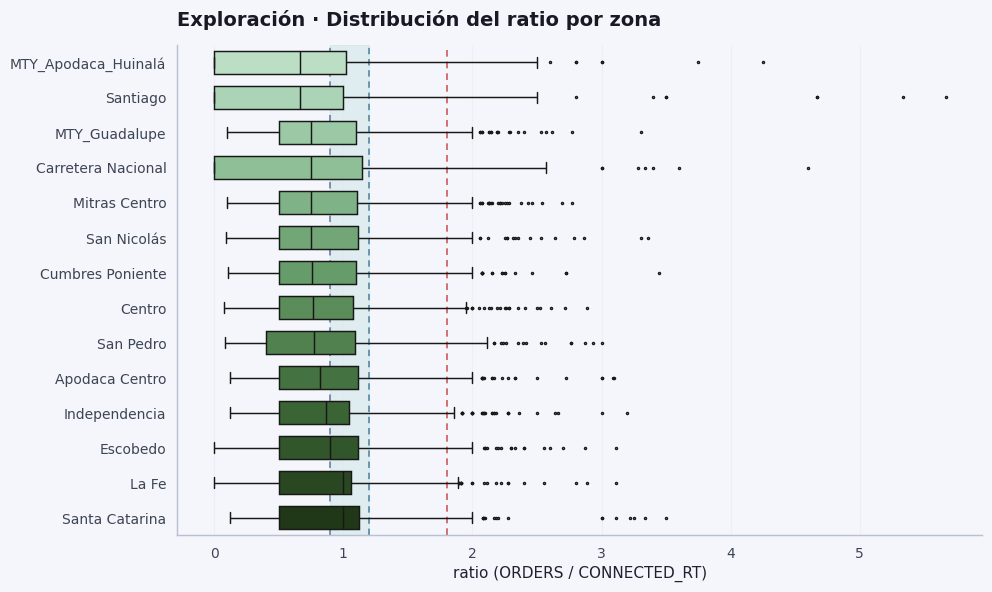

Mediana de ratio por zona (orden creciente):
ZONE
MTY_Apodaca_Huinalá    0.6667
Santiago               0.6667
MTY_Guadalupe          0.7500
Carretera Nacional     0.7500
Mitras Centro          0.7500
San Nicolás            0.7500
Cumbres Poniente       0.7596
Centro                 0.7647
San Pedro              0.7735
Apodaca Centro         0.8182
Independencia          0.8696
Escobedo               0.9000
La Fe                  1.0000
Santa Catarina         1.0000


In [65]:
# Exploración — boxplot ratio por zona (ejecutable sola: define FIG/save_fig abajo si hace falta).
# Exploración — distribución del ratio por zona (boxplot horizontal)
# Orden por mediana de ratio (creciente): comparar dispersión y colas entre zonas.
# Líneas verticales: banda "saludable" 0.9–1.2 y umbral de saturación 1.8.

if "FIG" not in globals():
    from pathlib import Path as _PathFig

    if "PROJECT_ROOT" not in globals():
        _here = _PathFig.cwd().resolve()
        for _p in (_here, _here.parent, _here.parent.parent):
            if (_p / "data" / "rappi_delivery_case_data.xlsx").is_file():
                PROJECT_ROOT = _p
                break
        else:
            raise FileNotFoundError(
                "No se encuentra data/rappi_delivery_case_data.xlsx. Ejecuta la celda de imports base."
            )
    FIG = PROJECT_ROOT / "modulo1_diagnostico" / "figures"
    FIG.mkdir(parents=True, exist_ok=True)

if "save_fig" not in globals():
    def save_fig(fig, path, dpi=200):
        fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")

# Misma definición que la celda base: ORDERS/CONNECTED_RT; RT=0 → NaN (evita inf).
if "ratio" not in raw.columns:
    import numpy as _np_ratio

    raw["ratio"] = raw["ORDERS"] / raw["CONNECTED_RT"].replace(0, _np_ratio.nan)

raw_plot = raw.dropna(subset=["ratio"])
# Solo filas donde ratio existe (evita NaN del CONNECTED_RT=0).

_zone_order_ratio = (
    raw_plot.groupby("ZONE")["ratio"]
    .median()  # mediana de ratio dentro de cada zona
    .sort_values(ascending=True)  # zonas con mediana baja abajo del gráfico, altas arriba
    .index  # orden de etiquetas ZONE a pasar a boxplot(..., order=...)
)

_n_z = len(_zone_order_ratio)  # número de zonas con al menos un ratio
_pal = sns.cubehelix_palette(_n_z, start=1.75, rot=0.12, dark=0.18, light=0.82)
# Paleta continua: un color distinto por fila (zona) sin confundir con semántica de ratio.

fig, ax = plt.subplots(figsize=(10.2, 6.2), facecolor=plt.rcParams["figure.facecolor"])
sns.boxplot(
    data=raw_plot,
    y="ZONE",  # categorías en el eje vertical (una fila por zona)
    x="ratio",  # eje horizontal = ratio
    order=_zone_order_ratio,  # respeta el orden por mediana
    ax=ax,
    width=0.64,  # ancho de cada caja
    palette=_pal,  # color por zona (orden coincide con order)
    fliersize=1.5,  # tamaño de puntos outlier
    linewidth=1.05,
    saturation=0.92,
)
# Bandas y líneas de referencia (detrás de las cajas: zorder bajo)
ax.axvspan(0.9, 1.2, color=COLORS["axvspan_ok"], alpha=0.09, zorder=0)  # sombra suave banda "saludable"
ax.axvline(0.9, color=COLORS["ref_soft"], linestyle=(0, (4, 3)), linewidth=1.15, alpha=0.9, zorder=1)
ax.axvline(1.2, color=COLORS["ref_ok"], linestyle=(0, (4, 3)), linewidth=1.15, alpha=0.9, zorder=1)
ax.axvline(1.8, color=COLORS["ref_sat"], linestyle=(0, (4, 3)), linewidth=1.2, alpha=0.92, zorder=1)

ax.set_xlabel("ratio (ORDERS / CONNECTED_RT)")
ax.set_ylabel("")  # nombres de zona ya van en el eje y
ax.set_title("Exploración · Distribución del ratio por zona")
if "polish_axes" in globals():
    polish_axes(ax)  # estilo unificado si ya corrió la celda de imports
else:
    ax.spines["top"].set_visible(False)  # fallback mínimo si no hay polish_axes
    ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.35, zorder=0)  # rejilla vertical (lectura del ratio)
fig.tight_layout()  # ajusta márgenes
save_fig(fig, FIG / "exploracion_ratio_por_zona.png")  # guarda PNG en figures/
plt.show()

print("Mediana de ratio por zona (orden creciente):")
print(
    raw_plot.groupby("ZONE")["ratio"]
    .median()
    .sort_values()
    .round(4)
    .to_string()  # tabla texto en consola (complementa el gráfico)
)


**Antes de los detalles del boxplot:** cada fila es una zona. La **caja** muestra dónde está la mitad central de las horas (ni las más extremas); la **línea dentro** es la **mediana** (valor de en medio). Los **bigotes** alargan el rango “típico”. No hace falta calcular nada a mano: compara visualmente qué zonas viven más tiempo cerca del umbral rojo de saturación.



#### Lectura del gráfico — distribución del `ratio` por zona

**Qué muestra el gráfico**

Es un **boxplot horizontal** del ratio (\(\mathrm{ORDERS}/\mathrm{CONNECTED\_RT}\)) por zona. Cada fila es una zona; la caja resume el **50 % central** de las observaciones (horas/días en el panel), la línea vertical dentro de la caja es la **mediana**, los bigotes van hasta ~1.5×IQR (según seaborn) y los **puntos** son **valores atípicos** (muchas horas con ratio muy alto).

**Referencias del notebook**

- **Banda sombreada 0.9–1.2** (líneas azules discontinuas): zona operativa “saludable” (demanda y oferta alineadas en sentido heurístico).
- **Línea roja ~1.8**: umbral de **saturación** usado también en el logit / clasificación.

**Qué se observa**

*Mediana por zona*

En casi todas las zonas la mediana está **por debajo de 0.9–1.2** (más hacia **0.6–1.0**). Eso indica que, en la mayor parte del tiempo, el panel muestra **más capacidad conectada** que la que exige la demanda instantánea (ratio “bajo” en términos del caso), no un sistema **permanentemente colapsado** en la mediana.

*Dispersión (altura de las cajas)*

Zonas como **MTY_Apodaca_Huinalá**, **Santiago** o **Carretera Nacional** tienen **cajas más anchas**: el ratio oscila mucho incluso en el rango intercuartílico. Otras zonas (p. ej. hacia abajo del gráfico) muestran **cajas más compactas**: comportamiento más estable en el “estado típico”.

*Cola derecha y saturación*

Hay **muchos outliers por encima de 1.8** (y algunos muy altos, hasta ~5–6) en casi todas las zonas. Eso **no contradice** el punto anterior: el sistema puede estar tranquilo en la mediana y, en ciertas horas o eventos, pasar a **picos de estrés** (poca oferta relativa a pedidos). Es coherente con **heterogeneidad temporal** (picos) más que con un problema homogéneo 24/7.

*Orden del gráfico*

Las zonas están ordenadas por **mediana de ratio creciente** (abajo, mediana más alta dentro del gráfico). Sirve para ver **quién tiene, en promedio, más carga relativa** en el centro de la distribución, no solo picos.

*Lectura conjunta*

- **Mediana baja** → muchas horas “sobre-oferta” o intermedias.
- **Outliers altos** → episodios de saturación o tensión fuerte que el **promedio simple** no captaría bien.
- Para decisiones operativas (incentivos, alertas) tiene sentido combinar **percentiles / picos** (como en P6 o en el motor) con esta visión de **distribución completa**.

**Resumen en una frase**

El gráfico muestra que la “normalidad” del ratio suele ser **baja a moderada**, pero **todas las zonas** experimentan **eventos extremos** de ratio alto, alineados con **picos de estrés puntuales** más que con un colapso permanente en la mediana.

*Nota:* Puedes enlazar este resultado a **zonas concretas** y a los **umbrales** del notebook, o a la **tabla de medianas** que imprime la celda de código anterior.


### P1 — Horas y zonas con saturación crítica

> **Lectura sencilla:**
> P1 responde: **¿a qué horas** y **en qué zonas** aparece más a menudo el ratio por encima del umbral de saturación del caso? No es una predicción del futuro; es **conteo** en el historial del Excel.

**Nota:** Se filtran las filas con `clasificacion == "saturacion"` (equivalente a **ratio > 1.8**): es un **indicador binario** por fila; en el marco natural para \(P(Y=1\mid X)\) es la **regresión logística**, mientras aquí priorizamos **frecuencias empíricas** y el **ratio** continuo por coherencia con el M2. El **gráfico por hora** cuenta filas en saturación por hora del día; el **gráfico por zona** ordena totales; la **rejilla (una curva por zona)** muestra la **fracción** de días en saturación por (zona, hora) con panel balanceado (30 observaciones por celda). La salida numérica incluye un **IC95% Wilson** para la **proporción global** de saturación (inferencia sobre una proporción binomial, muestreo).

Sirve para priorizar **ventanas horarias** y **zonas** donde el desequilibrio pedidos/repartidores es más frecuente según el umbral elegido.

Horas en saturación: 513 / 10080 (5.09%)
Proporción global en saturación: 0.0509  IC95% Wilson: [0.0468, 0.0554]


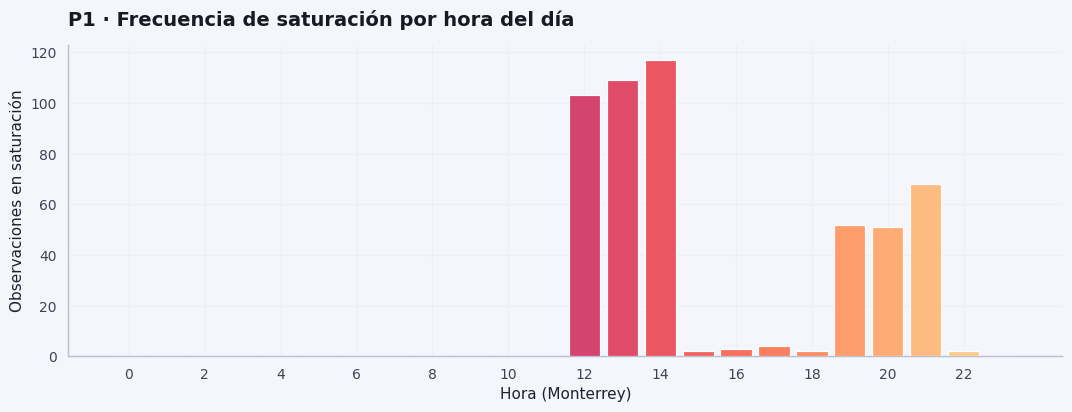

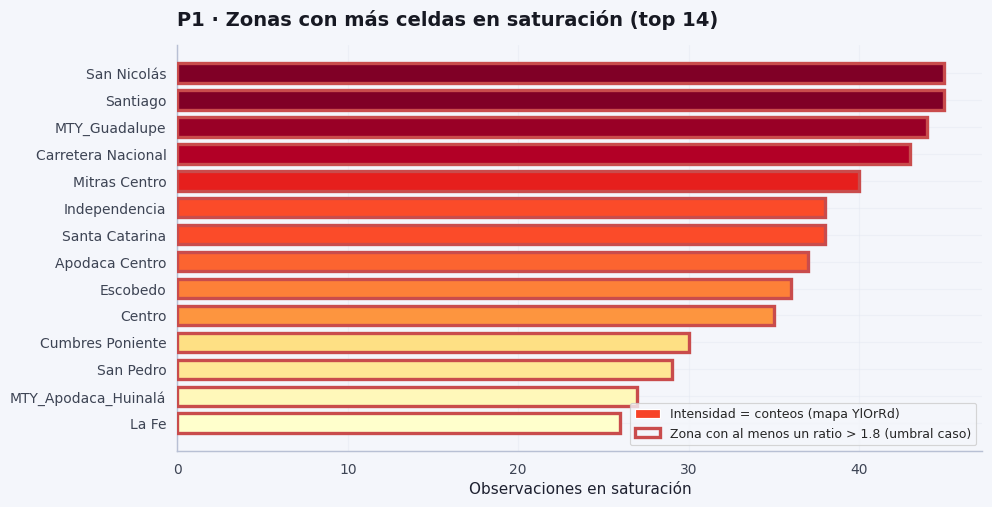

PNG por zona → /home/sigmadg/Documentos/caso_tecnico/modulo1_diagnostico/figures/p1_frecuencia_por_zona  (archivos: 14)
  p1_frecuencia_hora__Apodaca_Centro.png
  p1_frecuencia_hora__Carretera_Nacional.png
  p1_frecuencia_hora__Centro.png
  p1_frecuencia_hora__Cumbres_Poniente.png
  p1_frecuencia_hora__Escobedo.png
  p1_frecuencia_hora__Independencia.png
  p1_frecuencia_hora__La_Fe.png
  p1_frecuencia_hora__MTY_Apodaca_Huinalá.png
  p1_frecuencia_hora__MTY_Guadalupe.png
  p1_frecuencia_hora__Mitras_Centro.png
  p1_frecuencia_hora__San_Nicolás.png
  p1_frecuencia_hora__San_Pedro.png
  p1_frecuencia_hora__Santa_Catarina.png
  p1_frecuencia_hora__Santiago.png


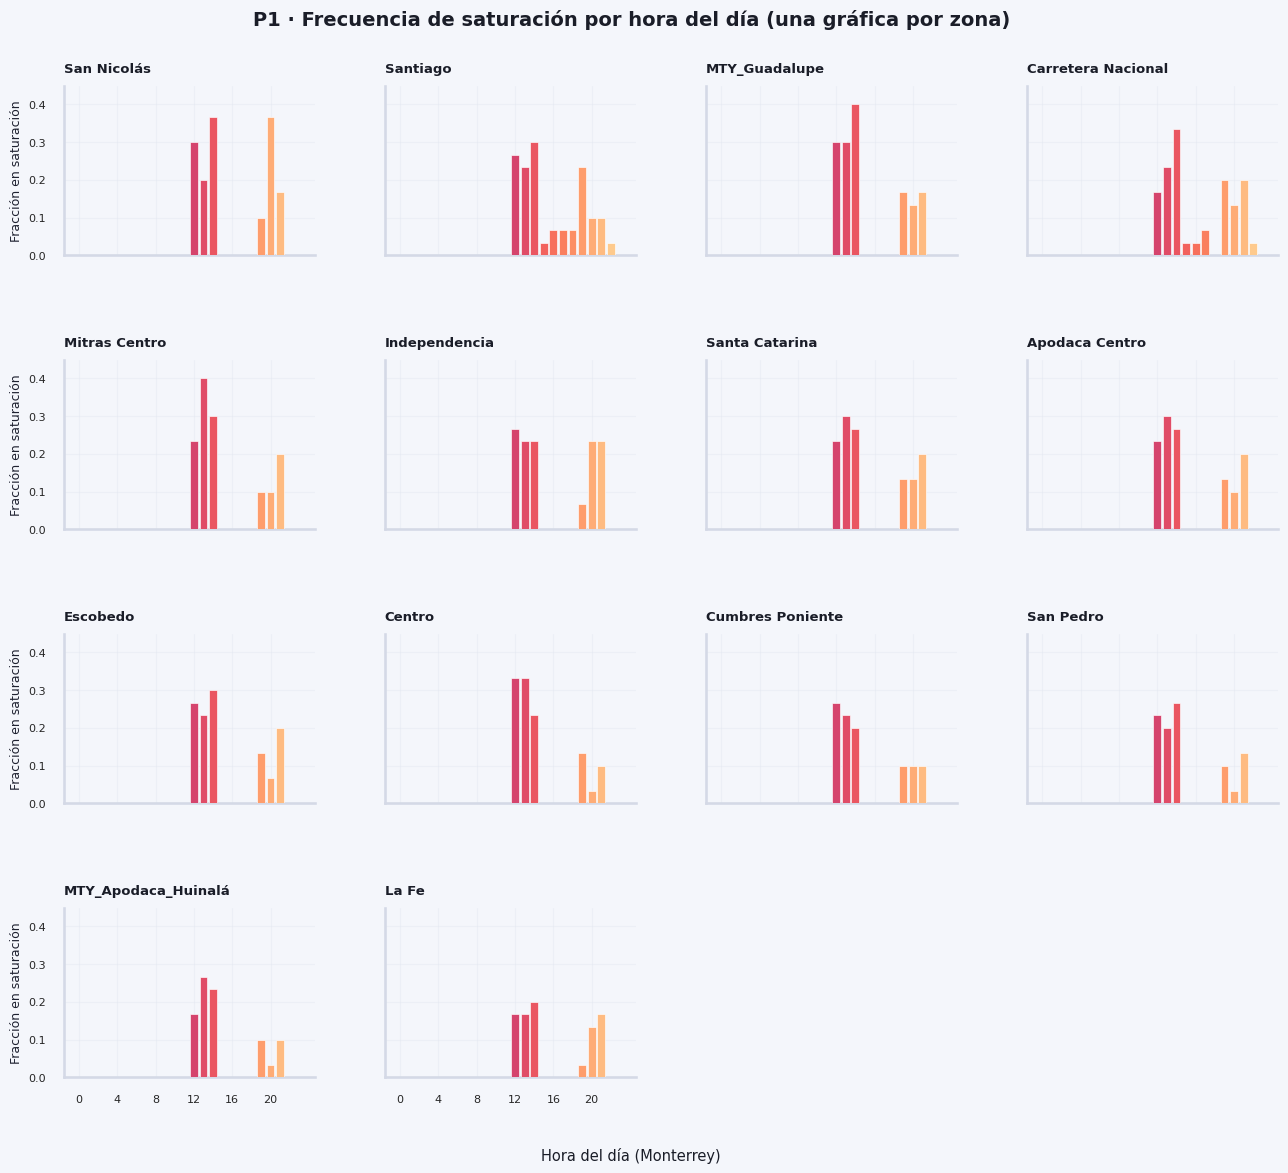

Hora con mayor frecuencia de saturación por zona:
ZONE
San Nicolás            14
Santiago               14
MTY_Guadalupe          14
Carretera Nacional     14
Mitras Centro          13
Independencia          12
Santa Catarina         13
Apodaca Centro         13
Escobedo               14
Centro                 12
Cumbres Poniente       12
San Pedro              14
MTY_Apodaca_Huinalá    13
La Fe                  14

Top horas (global): HOUR
14    117
13    109
12    103
21     68
19     52
Top zonas (global):
ZONE
San Nicolás           45
Santiago              45
MTY_Guadalupe         44
Carretera Nacional    43
Mitras Centro         40
Independencia         38
Santa Catarina        38
Apodaca Centro        37
dtype: int64


In [66]:
# P1 — Saturación: conteos por hora y zona, IC Wilson, heatmap frecuencia hora×zona, PNG por zona y facets.
# --- Estilo de figuras (por si no ejecutaste la celda de imports completa) ---
# P1 · frecuencias/heatmap de saturación por hora y por zona (requiere clasificacion y ratio).
if "COLORS" not in globals():
    import matplotlib.pyplot as plt
    import numpy as np
    COLORS = {
        "p1_hours": plt.cm.magma(np.linspace(0.22, 0.88, 24)),
        "p1_zones_cmap": "Reds",
        "p3_bar": "#3d6b8e",
        "p4_face": "#2a9d8f",
        "p4_edge": "#1b4332",
        "sens_bar": "#1d3557",
    }
if "save_fig" not in globals():
    def save_fig(fig, path, dpi=200):
        fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")

if "FIG" not in globals():
    from pathlib import Path as _PathFig

    if "PROJECT_ROOT" not in globals():
        _here = _PathFig.cwd().resolve()
        for _p in (_here, _here.parent, _here.parent.parent):
            if (_p / "data" / "rappi_delivery_case_data.xlsx").is_file():
                PROJECT_ROOT = _p
                break
        else:
            raise FileNotFoundError(
                "No se encuentra data/rappi_delivery_case_data.xlsx. Ejecuta la celda de imports base."
            )
    FIG = PROJECT_ROOT / "modulo1_diagnostico" / "figures"
    FIG.mkdir(parents=True, exist_ok=True)

if "polish_axes" not in globals():
    def polish_axes(ax, title_pad=14):
        title = ax.get_title()
        ax.set_title("")
        ax.set_title(title, loc="left", pad=title_pad, fontsize=14, fontweight="600", color="#171923")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_linewidth(1.05)
            ax.spines[side].set_color("#b8c0d4")
        ax.tick_params(axis="both", which="major", length=4.5, width=0.85, colors="#3d4454")

# Misma lógica que la celda base y `export_calibration_from_m1.py` (evita KeyError si se salta esa celda).
import numpy as np
import pandas as pd

if ("ratio" not in raw.columns) or ("clasificacion" not in raw.columns):
    raw = raw.copy()
if "ratio" not in raw.columns:
    raw["ratio"] = raw["ORDERS"] / raw["CONNECTED_RT"].replace(0, np.nan)
if "clasificacion" not in raw.columns:
    def _clasif_operativa(r):
        if pd.isna(r):
            return np.nan
        if r > 1.8:
            return "saturacion"
        if r < 0.5:
            return "sobre_oferta"
        if 0.9 <= r <= 1.2:
            return "saludable"
        return "intermedio"

    raw["clasificacion"] = raw["ratio"].map(_clasif_operativa)

sat = raw[raw["clasificacion"] == "saturacion"]
print(f"Horas en saturación: {len(sat)} / {len(raw)} ({100*len(sat)/len(raw):.2f}%)")
# Inferencia sobre la proporción global (Teoría: muestreo / inferencia — `Teoria/Machine Learning/tema1.pdf`)
from statsmodels.stats.proportion import proportion_confint

_sat_n = int(raw["clasificacion"].eq("saturacion").sum())
_n = len(raw)
_wl, _wu = proportion_confint(_sat_n, _n, method="wilson", alpha=0.05)
print(
    f"Proporción global en saturación: {_sat_n / _n:.4f}  "
    f"IC95% Wilson: [{_wl:.4f}, {_wu:.4f}]"
)

p1h = sat.groupby("HOUR").size().reindex(range(24), fill_value=0)
p1z = sat.groupby("ZONE").size().sort_values(ascending=False)

# P1a — barras por hora (gradiente por intensidad horaria)
fig, ax = plt.subplots(figsize=(11, 4.4), facecolor=plt.rcParams["figure.facecolor"])
ax.bar(
    p1h.index,
    p1h.values,
    color=COLORS["p1_hours"],
    edgecolor="white",
    linewidth=0.85,
    width=0.82,
    zorder=3,
)
ax.set_xlabel("Hora (Monterrey)")
ax.set_ylabel("Observaciones en saturación")
ax.set_title("P1 · Frecuencia de saturación por hora del día")
ax.set_xticks(range(0, 24, 2))
polish_axes(ax)
ax.grid(axis="y", zorder=0)
fig.tight_layout()
save_fig(fig, FIG / "p1_horas_saturacion.png")
plt.show()

# P1b — zonas (tonos por magnitud + borde Ops si la zona ha tenido ratio > 1.8 en algún instante)
fig, ax = plt.subplots(figsize=(10.2, 5.35), facecolor=plt.rcParams["figure.facecolor"])
topz = p1z.head(14)
norm = mcolors.Normalize(vmin=topz.min(), vmax=topz.max())
cmap = plt.get_cmap(COLORS["p1_zones_cmap"])
bar_colors = [cmap(norm(v)) for v in topz.values]
_hit_sat = raw.groupby("ZONE")["ratio"].max().reindex(topz.index)
_edge = [COLORS["ref_sat"] if (_hit_sat[z] > 1.8) else "white" for z in topz.index]
_lw = [2.4 if (_hit_sat[z] > 1.8) else 0.75 for z in topz.index]
y_pos = np.arange(len(topz))
ax.barh(
    y_pos,
    topz.values,
    color=bar_colors,
    edgecolor=_edge,
    linewidth=_lw,
    height=0.72,
    zorder=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(topz.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("Observaciones en saturación")
ax.set_title("P1 · Zonas con más celdas en saturación (top 14)")
polish_axes(ax)
ax.grid(axis="x", zorder=0)
from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(facecolor=cmap(0.65), edgecolor="white", label="Intensidad = conteos (mapa YlOrRd)"),
        Patch(facecolor="#f4f6fb", edgecolor=COLORS["ref_sat"], linewidth=2.4, label="Zona con al menos un ratio > 1.8 (umbral caso)"),
    ],
    loc="lower right",
    fontsize=9,
    frameon=True,
    facecolor="#f4f6fb",
)
fig.tight_layout()
save_fig(fig, FIG / "p1_zonas_saturacion.png")
plt.show()

# P1c — frecuencia de saturación por hora por zona
# · PNG individuales: FIG / "p1_frecuencia_por_zona" / p1_frecuencia_hora__<zona>.png (uno por cada ZONE)
# · Rejilla 4×4 (resumen): p1_frecuencia_hora_por_zona_facets.png (al final de este bloque)
# Cada barra (zona, hora): fracción = (# días en sat.) / 30 con panel balanceado
p1_freq = raw.pivot_table(
    index="ZONE",
    columns="HOUR",
    values="clasificacion",
    aggfunc=lambda s: (s == "saturacion").mean(),
)
p1_freq = p1_freq.reindex(columns=range(24))
zones_by_sat = (
    raw.assign(is_sat=raw["clasificacion"].eq("saturacion"))
    .groupby("ZONE")["is_sat"]
    .sum()
    .sort_values(ascending=False)
    .index
)
p1_freq = p1_freq.reindex(zones_by_sat)

zone_list = list(p1_freq.index)
n_z = len(zone_list)
ncols = 4
nrows = int(np.ceil(n_z / ncols))
ymax = float(np.nanmax(p1_freq.values)) * 1.12
ymax = max(ymax, 0.03)
hours = np.arange(24)

# --- P1c · un PNG por zona (misma escala Y que la rejilla; nombres de archivo seguros) ---
import re

_p1_zdir = FIG / "p1_frecuencia_por_zona"
_p1_zdir.mkdir(parents=True, exist_ok=True)


def _safe_zone_slug(name: str) -> str:
    slug = re.sub(r"[^\w\-]+", "_", str(name).strip(), flags=re.UNICODE)
    return (slug.strip("_") or "zona")[:100]


for zone in zone_list:
    _figz, _axz = plt.subplots(figsize=(7.4, 3.75), facecolor=plt.rcParams["figure.facecolor"])
    _y = p1_freq.loc[zone].values.astype(float)
    _axz.bar(
        hours,
        _y,
        color=COLORS["p1_hours"],
        edgecolor="white",
        linewidth=0.45,
        width=0.82,
        zorder=3,
    )
    _axz.set_ylim(0, ymax)
    _axz.set_title(
        f"P1 · {zone} · Fracción en saturación por hora",
        fontsize=11,
        fontweight="600",
        loc="left",
        color="#1a1d28",
        pad=12,
    )
    _axz.set_xlabel("Hora del día (Monterrey)", fontsize=10, color="#1a1d28")
    _axz.set_ylabel("Fracción en saturación", fontsize=10)
    _axz.set_xticks(range(0, 24, 4))
    _axz.tick_params(axis="both", labelsize=9)
    _axz.grid(axis="y", alpha=0.35, zorder=0)
    _axz.spines["top"].set_visible(False)
    _axz.spines["right"].set_visible(False)
    for _side in ("left", "bottom"):
        _axz.spines[_side].set_linewidth(1.05)
        _axz.spines[_side].set_color("#b8c0d4")
    _figz.tight_layout()
    save_fig(_figz, _p1_zdir / f"p1_frecuencia_hora__{_safe_zone_slug(zone)}.png")
    plt.close(_figz)

print(f"PNG por zona → {_p1_zdir}  (archivos: {len(zone_list)})")
for _fn in sorted(_p1_zdir.glob("p1_frecuencia_hora__*.png")):
    print(" ", _fn.name)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(13.2, 2.95 * nrows),
    sharex=True,
    sharey=True,
    facecolor=plt.rcParams["figure.facecolor"],
)
axes = np.atleast_1d(axes).ravel()

for i, zone in enumerate(zone_list):
    ax = axes[i]
    y = p1_freq.loc[zone].values.astype(float)
    ax.bar(
        hours,
        y,
        color=COLORS["p1_hours"],
        edgecolor="white",
        linewidth=0.45,
        width=0.82,
        zorder=3,
    )
    ax.set_ylim(0, ymax)
    # Título con margen para no chocar con la fila superior
    ax.set_title(zone, fontsize=9.5, fontweight="600", loc="left", color="#1a1d28", pad=10)
    ax.set_xticks(range(0, 24, 4))
    ax.tick_params(axis="both", labelsize=8)
    ax.grid(axis="y", alpha=0.35, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    # Eje Y solo en la primera columna (evita supylabel encimado con títulos)
    if i % ncols == 0:
        ax.set_ylabel("Fracción en saturación", fontsize=9)

for j in range(n_z, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "P1 · Frecuencia de saturación por hora del día (una gráfica por zona)",
    fontsize=14,
    fontweight="600",
    color="#1a1d28",
    y=0.995,
)
# Márgenes explícitos: más aire entre filas (hspace) que tight_layout por defecto
fig.subplots_adjust(
    left=0.07,
    right=0.99,
    top=0.93,
    bottom=0.09,
    hspace=0.62,
    wspace=0.28,
)
fig.text(0.5, 0.02, "Hora del día (Monterrey)", ha="center", fontsize=10.5, color="#1a1d28")
save_fig(fig, FIG / "p1_frecuencia_hora_por_zona_facets.png")
plt.show()

p1_peak_h = p1_freq.idxmax(axis=1)
print("Hora con mayor frecuencia de saturación por zona:")
print(p1_peak_h.to_string())
print()
print("Top horas (global):", p1h.nlargest(5).to_string())
print("Top zonas (global):")
print(p1z.head(8))


### Qué describe la gráfica

> **Lectura sencilla:**
> Cada mini-gráfica es una zona. La altura de las barras dice: “en esta hora, qué **fracción** de los momentos observados estuvo saturada”. Sirve para ventanas de comida/cena y para comparar barrios.

Cada **panel** es una **zona**. En el eje **X** está la **hora del día** (0–23, Monterrey). En el eje **Y**, **«Fracción en saturación»** es, para esa **hora × zona**, la **proporción de filas del panel** (instantes día×hora×zona) en los que se cumple `clasificacion == "saturacion"` (equivalente a **`ratio > 1.8`**). Es decir: *entre todas las observaciones con esa hora y esa zona en el Excel, qué fracción están saturadas*. Es **frecuencia histórica** en el dataset, **no** una predicción ni una probabilidad modelada.

Las **dos tonalidades** de barras solo **separan visualmente** bloques del día (p. ej. franja de **comida** vs **cena**). Para interpretar el mensaje operativo importan la **altura** de cada barra y la **hora** en el eje X, no el color en sí.


#### 1) «Hora con mayor frecuencia de saturación por zona»

Para **cada zona**, el número mostrado (12, 13 o **14** en tu salida) es la **hora en la que la barra es más alta** en ese panel: el **máximo del perfil horario** de saturación relativa en esa zona (una sola hora «ganadora» por zona si hay empate, según cómo lo calcule la celda).

- **Muchas zonas con pico en la 14** indica que, en el histórico, el **centro del estrés almuerzo** se alinea a menudo alrededor de las **14:00** (no que todas las saturaciones ocurran solo a esa hora, sino que **esa** es la hora con mayor fracción en esa zona).
- Zonas con pico en **13** (p. ej. **Mitras Centro**, **Santa Catarina**, **Apodaca Centro**, **MTY_Apodaca_Huinalá**) o en **12** (**Independencia**, **Centro**, **Cumbres Poniente**) muestran que el **máximo local** se desplaza **una o dos horas** dentro del mismo bloque de mediodía: sigue siendo el **mismo fenómeno** (pico de demanda vs oferta), con **forma distinta** del perfil.

En conjunto (con los datos que pegaste): **7 zonas** con argmax en **14**, **4** en **13**, **3** en **12** (14 zonas en total). Eso refuerza que el problema **no** es una hora única universal, sino una **franja de mediodía** donde el sistema suele estar más tensionado.

#### 2) Top horas (global): 14 → 117, 13 → 109, 12 → 103, 21 → 68, 19 → 52

Aquí cada número es el **conteo de filas saturadas** en esa **hora**, **sumando todas las zonas y todos los días** del panel (cada fila del Excel es un instante; si está saturada, cuenta una vez).

- **117 + 109 + 103** en **14, 13 y 12** confirma que la **mayor masa** de saturaciones del caso ocurre en el **bloque de mediodía** (la **14:00** es la hora con más filas saturadas en todo el dataset).
- **68** y **52** en **21** y **19** apoyan el **segundo pico** (cena): menos filas que al mediodía, pero **claramente por encima** de la mayoría de horas fuera de esas ventanas.
- La suma de estos conteos **no** es el total de saturaciones del panel (las horas se solapan en el sentido de que cada fila tiene una sola hora; pero **una misma zona-día** puede tener varias horas saturadas — aquí cada fila cuenta una vez por su hora). Sirve para **ordenar** qué horas del reloj explican más «eventos» observados.

#### 3) Top zonas (global): p. ej. San Nicolás 45, Santiago 45, … Apodaca Centro 37

Cada valor es el **número total de filas** del panel en esa **zona** donde hubo saturación (**sumando las 24 horas y los 30 días**). Ordena **dónde** se acumulan más **instantes saturados** en el histórico.

- **San Nicolás** y **Santiago** (45) encabezan: más **registros** en saturación que el resto en este Excel.
- La **diferencia** entre el tope (45) y zonas más abajo (p. ej. **37** en **Apodaca Centro**) se interpreta como **más carga acumulada** de eventos en el periodo, no como «peor ratio en un solo instante» (eso lo da el facet por hora).
- Uso práctico: **priorización** (alertas, refuerzo, incentivos) **si** el negocio alinea «más filas saturadas» con «más atención»; siempre **cruzar** con el gráfico por hora para ver **cuándo** actuar en cada zona.

La saturación es **muy horaria** y **bimodal** (picos de mediodía y de noche); en el panel global la **14:00** concentra el mayor número de filas saturadas; la tabla **por zona** matiza **en qué hora** es máximo el perfil local; el **ranking de zonas** indica **dónde** se acumulan más eventos en el periodo observado.

*Siguiente paso opcional:* una **frase por zona** que una «hora pico local» (12 / 13 / 14) con el mapa operativo o con **P6** (priorización de incentivos).


**Idea general (lluvia y ratio):** nos preguntamos si, cuando llueve más, también sube el “pedidos por repartidor”. El modelo intenta **separar** ese efecto del efecto de la hora y del día — es decir, no confundir “llovió a las 8” con “los lunes siempre hay más pedidos”.

---

### P2 — Variable externa (precipitación)

**Nota:** Primero se mira la **matriz de correlación de Pearson** entre precipitación, ratio y earnings (asociación **lineal bivariada**; véase *regresión simple y correlación*. Luego un **MCO** (mínimos cuadrados ordinarios) `ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE) + C(dow)` (`dow` = día de la semana desde `DATE`): es un modelo de **regresión lineal múltiple** con variables categóricas. El coeficiente de `PRECIPITATION_MM` es un efecto **marginal** de la lluvia **condicionado** a hora, zona y **estacionalidad semanal** — reduce confusión por patrones lunes–domingo, pero **no** prueba causalidad por sí solo.

El código imprime además el **IC95%** del coeficiente y el **R²** del ajuste: el intervalo resume incertidumbre de muestreo del MCO (supuestos clásicos; el panel puede violar independencia entre filas, así que interpreta con cautela).

Tras el ajuste, la misma celda genera un **panel de cuatro gráficos de diagnóstico MCO** (residuos vs ajustados, QQ de residuos, **regresión parcial** de la precipitación al estilo Frisch–Lovell, y observado vs ajustado), guarda el panel en `modulo1_diagnostico/figures/p2_ols_diagnostico.png` y además **cuatro PNG sueltos** en `modulo1_diagnostico/figures/p2_ols_diagnostico_separados/` (`p2_ols_residuals_vs_fitted.png`, `p2_ols_qq_residuals.png`, `p2_ols_partial_precip.png`, `p2_ols_observed_vs_fitted.png`).

**Siguiente bloque (GAP 1):** el modelo aditivo no responde solo si la lluvia **causa** saturación o **coincide** con horas pico; ahí entra la **interacción lluvia × hora** y la pendiente marginal por hora.

                  PRECIPITATION_MM     ratio  EARNINGS
PRECIPITATION_MM          1.000000  0.318902  0.226029
ratio                     0.318902  1.000000  0.099885
EARNINGS                  0.226029  0.099885  1.000000
Coef. precipitación (MCO): 0.08024352258230985 p-valor: 2.1009930810386952e-231
IC95% coef. precipitación: [0.075527, 0.084960]
R² del modelo: 0.7180  (n observaciones: 10080)
                     0                 1                    2          3
0               Model:               OLS      Adj. R-squared:      0.717
1  Dependent Variable:             ratio                 AIC:  3916.2816
2                Date:  2026-04-03 19:26                 BIC:  4233.8871
3    No. Observations:             10080      Log-Likelihood:    -1914.1
4            Df Model:                43         F-statistic:      594.1
5        Df Residuals:             10036  Prob (F-statistic):       0.00
6           R-squared:             0.718               Scale:   0.085974
P(saturación | preci

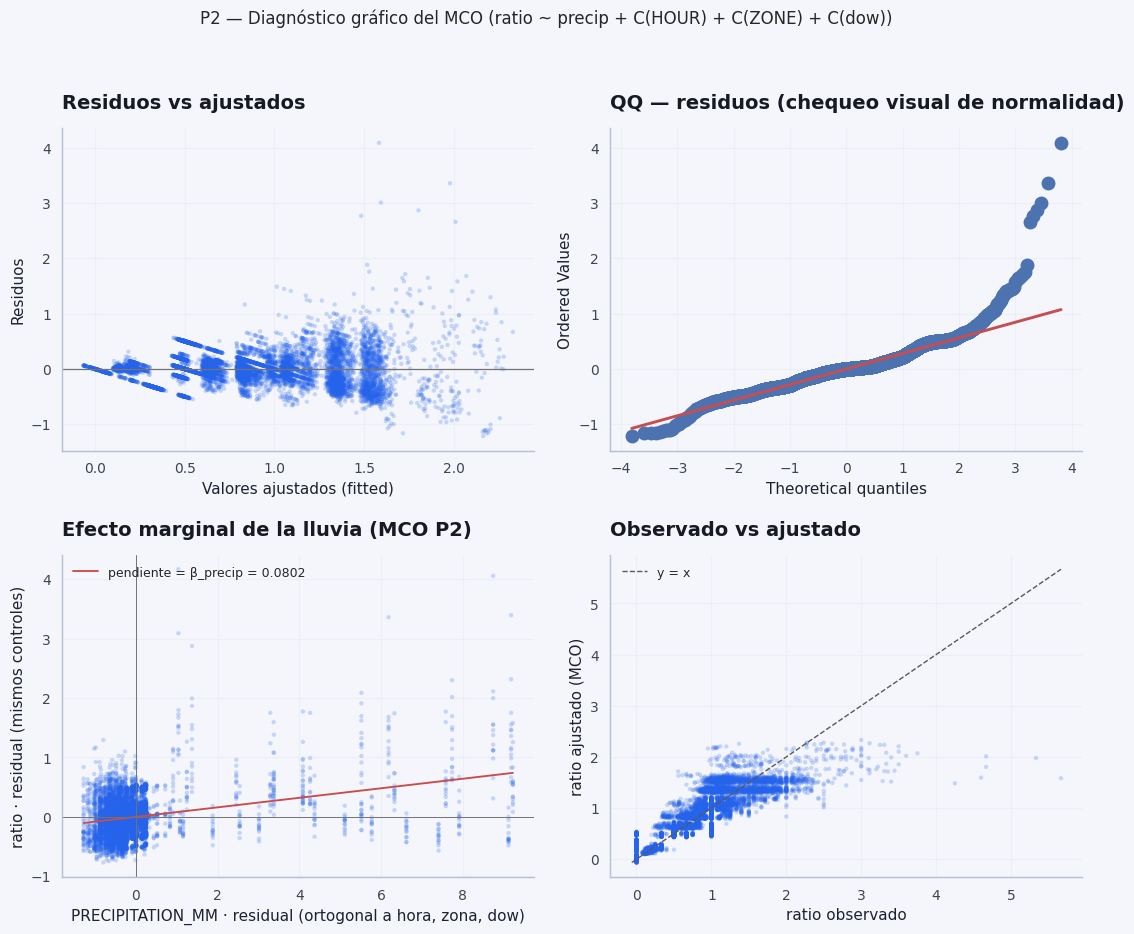

In [67]:
# P2 — Correlación + MCO ratio~lluvia + SE cluster + diagnósticos gráficos + PNG exportados.
# P2: ratio ~ lluvia con efectos fijos de hora y zona (MCO).
# Correlación Pearson escalar; inferencia con errores agrupados por zona (cluster).

import numpy as np  # Operaciones numéricas (NaN, linspace, etc.).
import pandas as pd  # Manipular DataFrame/Series del panel.

if "smf" not in globals():  # statsmodels solo si no vino de la celda base.
    import statsmodels.formula.api as smf  # API de modelos con fórmula tipo R (OLS, …).

# Si ejecutas solo esta celda: carga RAW_DATA (misma búsqueda de raíz que la celda base).
if "raw" not in globals():  # No hay panel en memoria → hay que leer el Excel.
    from pathlib import Path  # Para localizar el fichero del caso.

    def _project_root() -> Path:  # Duplicado lógico de la celda base: encontrar repo.
        here = Path.cwd().resolve()  # Directorio desde el que Jupyter lanzó el kernel.
        for p in (here, here.parent, here.parent.parent):  # Subir hasta dos niveles.
            if (p / "data" / "rappi_delivery_case_data.xlsx").is_file():  # ¿Está el Excel aquí?
                return p  # Esta carpeta es la raíz del proyecto.
        raise FileNotFoundError(  # Evitar error críptico si no se encuentra el archivo.
            "No se encuentra data/rappi_delivery_case_data.xlsx. "
            "Abre la carpeta del repo como workspace o ejecuta la celda base del notebook."
        )

    PROJECT_ROOT = _project_root()  # Raíz donde vive la carpeta data/.
    DATA = PROJECT_ROOT / "data" / "rappi_delivery_case_data.xlsx"  # Ruta completa al .xlsx.
    raw = pd.read_excel(DATA, sheet_name="RAW_DATA")  # Cargar hoja del panel operativo.

# Misma lógica que P1 / export_calibration (evita KeyError si faltan columnas).
if ("ratio" not in raw.columns) or ("clasificacion" not in raw.columns):  # Hay que derivar columnas sin mutar ajenos.
    raw = raw.copy()  # Copia para poder añadir columnas sin SettingWithCopyWarning.
if "ratio" not in raw.columns:  # ratio = pedidos por repartidor conectado.
    raw["ratio"] = raw["ORDERS"] / raw["CONNECTED_RT"].replace(0, np.nan)  # RT=0 → evitar división por cero (NaN).
if "clasificacion" not in raw.columns:  # Etiquetas operativas según umbrales del caso.
    def _clasif_operativa_p2(r):  # Función fila a fila sobre el valor de ratio.
        if pd.isna(r):  # Sin ratio válido → sin clasificación.
            return np.nan
        if r > 1.8:  # Umbral saturación del encargo.
            return "saturacion"
        if r < 0.5:  # Umbral sobre-oferta.
            return "sobre_oferta"
        if 0.9 <= r <= 1.2:  # Banda “saludable” del documento.
            return "saludable"
        return "intermedio"  # Todo lo demás entre cortes.

    raw["clasificacion"] = raw["ratio"].map(_clasif_operativa_p2)  # Aplicar reglas a toda la columna.

print(raw[["PRECIPITATION_MM", "ratio", "EARNINGS"]].corr(method="pearson"))  # Matriz 3×3 de correlación lineal (sin controles).

_raw_p2 = raw.copy()  # Copia para añadir dow sin tocar el raw global de otras celdas.
_raw_p2["dow"] = pd.to_datetime(_raw_p2["DATE"]).dt.dayofweek  # 0=lun … 6=dom; controla estacionalidad semanal en el MCO.
m = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE) + C(dow)", data=_raw_p2).fit()  # OLS con dummies de hora, zona y día.
beta_p = m.params["PRECIPITATION_MM"]  # Pendiente marginal de la lluvia (mm/h) condicional a controles.
pval_p = m.pvalues["PRECIPITATION_MM"]  # p-valor clásico (supuestos i.i.d.; contrastar con cluster abajo).
ci_lo, ci_hi = m.conf_int().loc["PRECIPITATION_MM"]  # IC95% clásico del coeficiente de precipitación.
print("Coef. precipitación (MCO):", beta_p, "p-valor:", pval_p)  # Salida legible en consola.
print(f"IC95% coef. precipitación: [{ci_lo:.6f}, {ci_hi:.6f}]")  # Formato fijo a 6 decimales.
print(f"R² del modelo: {m.rsquared:.4f}  (n observaciones: {int(m.nobs)})")  # Bondad de ajuste y filas usadas por statsmodels.
print(m.summary2().tables[0])  # Tabla resumen (AIC, BIC, F, gl, etc.).

rain = raw["PRECIPITATION_MM"] > 0.5  # Máscara booleana: “hora con lluvia material” según umbral 0.5 mm/h.
print("P(saturación | precip>0.5):", raw.loc[rain, "clasificacion"].eq("saturacion").mean())  # Fracción saturación si llueve.
print("P(saturación | precip<=0.5):", raw.loc[~rain, "clasificacion"].eq("saturacion").mean())  # Fracción si casi no llueve.

# --- P2 · Errores estándar robustos por cluster (zona): inferencia bajo dependencia dentro de zona ---
_p2 = _raw_p2.dropna(subset=["ratio", "PRECIPITATION_MM", "HOUR", "ZONE", "DATE"])  # Misma muestra que el ajuste “limpio”.
m_p2_clu = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE) + C(dow)", data=_p2).fit(  # Misma fórmula que m.
    cov_type="cluster",  # Varianza tipo sandwich con agrupación.
    cov_kwds={"groups": _p2["ZONE"]},  # Una observación por zona comparte correlación no observada.
)
print(  # Bloque formateado con inferencia robusta a correlación intra-zona.
    "\n--- P2 · Mismo MCO con SE cluster (zona) ---\n"
    "  β_precip = %.6f   se_cluster = %.6f   p = %.4g\n"
    "  IC95%% cluster  [%.6f, %.6f]"
    % (
        m_p2_clu.params["PRECIPITATION_MM"],  # Coeficiente (igual al OLS puntual; cambia solo la incertidumbre).
        m_p2_clu.bse["PRECIPITATION_MM"],  # Error estándar cluster-robusto.
        float(m_p2_clu.pvalues["PRECIPITATION_MM"]),  # p-valor con SE ajustado.
        m_p2_clu.conf_int().loc["PRECIPITATION_MM", 0],  # Límite inferior IC95% cluster.
        m_p2_clu.conf_int().loc["PRECIPITATION_MM", 1],  # Límite superior IC95% cluster.
    )
)

# --- P2 · Gráficas de diagnóstico MCO (mismas filas que el ajuste con cluster) ---
# Residuos vs ajustados, QQ (normalidad aproximada), regresión parcial de precipitación
# (Frisch–Lovell: componentes de ratio y lluvia ortogonales a HOUR, ZONE, dow), y observado vs ajustado.
from scipy import stats  # probplot para el gráfico QQ de normalidad aproximada de residuos.
import matplotlib.pyplot as plt  # Todas las figuras de esta sección.

# FIG / save_fig: si no corriste la celda base, se definen aquí para mostrar y guardar P2.
if "FIG" not in globals():  # Ruta de salida de PNG del módulo 1.
    from pathlib import Path as _PathFig  # Alias para no chocar con Path del bloque anterior.

    if "PROJECT_ROOT" not in globals():  # Si raw vino de esta celda, PROJECT_ROOT ya existe; si no, buscar.
        _here = _PathFig.cwd().resolve()  # Punto de partida para la búsqueda.
        for _p in (_here, _here.parent, _here.parent.parent):  # Hasta dos niveles arriba.
            if (_p / "data" / "rappi_delivery_case_data.xlsx").is_file():  # Criterio de raíz del repo.
                PROJECT_ROOT = _p  # Fijar variable global usada abajo.
                break  # Salir del for con la primera coincidencia.
        else:  # Ningún candidato tuvo el Excel.
            raise FileNotFoundError(  # Mensaje alineado con el resto del notebook.
                "No se encuentra data/rappi_delivery_case_data.xlsx; abre el repo como workspace o ejecuta la celda base."
            )
    FIG = PROJECT_ROOT / "modulo1_diagnostico" / "figures"  # Carpeta estándar de exportación M1.
    FIG.mkdir(parents=True, exist_ok=True)  # Asegurar que exista antes de guardar.

if "save_fig" not in globals():  # Función de guardado idéntica a la celda base.

    def save_fig(fig, path, dpi=200):  # Envoltorio: bbox tight + color de fondo coherente.
        fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")  # Escribir PNG en disco.


m_p2_vis = smf.ols(  # Reajuste sobre _p2 (sin NaN) para alinear residuos con la muestra del cluster.
    "ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE) + C(dow)", data=_p2  # Misma especificación que arriba.
).fit()  # Objeto de resultados OLS.
fitv = m_p2_vis.fittedvalues  # Valores ajustados ŷ (Serie alineada al índice de _p2).
res = m_p2_vis.resid  # Residuos e = y − ŷ.
ry = smf.ols("ratio ~ C(HOUR) + C(ZONE) + C(dow)", data=_p2).fit().resid  # Parte de ratio ortogonal a controles (Frisch–Lovell).
rx = smf.ols("PRECIPITATION_MM ~ C(HOUR) + C(ZONE) + C(dow)", data=_p2).fit().resid  # Parte de lluvia ortogonal a los mismos controles.
beta_vis = float(m_p2_vis.params["PRECIPITATION_MM"])  # Pendiente global del MCO (debe coincidir con la regresión parcial).
_cscatter = COLORS.get("p3_bar", "#2563eb") if "COLORS" in globals() else "#2563eb"  # Color puntos si existe paleta base.
_cline = COLORS.get("ref_sat", "#c94c4c") if "COLORS" in globals() else "#c94c4c"  # Color línea de pendiente en gráficos.

_p2_sep = FIG / "p2_ols_diagnostico_separados"  # Subcarpeta para los cuatro PNG sueltos.
_p2_sep.mkdir(parents=True, exist_ok=True)  # Crear si no existe.

# --- Cuatro PNG sueltos (mismo contenido que cada panel del 2×2) ---
_f1, _a1 = plt.subplots(figsize=(7.2, 5.4), facecolor=plt.rcParams["figure.facecolor"])  # Figura 1: residuos vs ajustados.
_a1.scatter(fitv, res, alpha=0.22, s=10, c=_cscatter, edgecolors="none")  # Nube de puntos semitransparente.
_a1.axhline(0.0, color="0.45", lw=0.9)  # Referencia de residuo nulo.
_a1.set_xlabel("Valores ajustados (fitted)")  # Eje X: predicción del modelo.
_a1.set_ylabel("Residuos")  # Eje Y: error por observación.
_a1.set_title("P2 · MCO — Residuos vs ajustados")  # Título del subgráfico exportado.
if "polish_axes" in globals():  # Estética opcional de la celda base.
    polish_axes(_a1)  # Título a la izquierda, sin marco superior/derecho.
_f1.tight_layout()  # Ajustar márgenes antes de guardar.
save_fig(_f1, _p2_sep / "p2_ols_residuals_vs_fitted.png")  # Exportar primer PNG suelto.
plt.close(_f1)  # Liberar memoria (no acumular figuras).

_f2, _a2 = plt.subplots(figsize=(7.2, 5.4), facecolor=plt.rcParams["figure.facecolor"])  # Figura 2: QQ-plot.
stats.probplot(res, dist="norm", plot=_a2)  # Cuantiles empíricos vs teóricos N(0,1).
_a2.set_title("P2 · MCO — QQ de residuos (normalidad aproximada)")  # Chequeo visual, no test formal aquí.
if "polish_axes" in globals():  # Misma estética opcional.
    polish_axes(_a2)
_f2.tight_layout()
save_fig(_f2, _p2_sep / "p2_ols_qq_residuals.png")  # Segundo PNG suelto.
plt.close(_f2)

_f3, _a3 = plt.subplots(figsize=(7.2, 5.4), facecolor=plt.rcParams["figure.facecolor"])  # Figura 3: regresión parcial lluvia.
_a3.scatter(rx, ry, alpha=0.22, s=10, c=_cscatter, edgecolors="none")  # rx, ry = componentes ortogonales a HOUR, ZONE, dow.
_xspan = np.linspace(float(rx.min()), float(rx.max()), 120)  # Rango del eje X para dibujar la recta sin extrapolar mucho.
_a3.plot(_xspan, beta_vis * _xspan, color=_cline, lw=1.35, label=f"pendiente = β_precip = {beta_vis:.4f}")  # Recta con pendiente del MCO.
_a3.axhline(0.0, color="0.45", lw=0.7)  # Referencia cruz en el origen (residuos centrados).
_a3.axvline(0.0, color="0.45", lw=0.7)
_a3.set_xlabel("PRECIPITATION_MM · residual (ortogonal a hora, zona, dow)")  # Eje X: lluvia purgada de efectos fijos.
_a3.set_ylabel("ratio · residual (mismos controles)")  # Eje Y: ratio purgado igualmente.
_a3.set_title("P2 · MCO — Regresión parcial (lluvia)")  # Interpretación: efecto marginal visual.
_a3.legend(loc="upper left", frameon=False, fontsize=9)  # Leyenda con β en texto.
if "polish_axes" in globals():
    polish_axes(_a3)
_f3.tight_layout()
save_fig(_f3, _p2_sep / "p2_ols_partial_precip.png")  # Tercer PNG suelto.
plt.close(_f3)

_f4, _a4 = plt.subplots(figsize=(7.2, 5.4), facecolor=plt.rcParams["figure.facecolor"])  # Figura 4: observado vs ajustado.
_a4.scatter(_p2["ratio"], fitv, alpha=0.22, s=10, c=_cscatter, edgecolors="none")  # y real frente a ŷ.
_mn = min(float(_p2["ratio"].min()), float(fitv.min()))  # Mínimo común para línea identidad.
_mx = max(float(_p2["ratio"].max()), float(fitv.max()))  # Máximo común.
_a4.plot([_mn, _mx], [_mn, _mx], color="0.35", ls="--", lw=1.0, label="y = x")  # Referencia predicción perfecta.
_a4.set_xlabel("ratio observado")  # Eje X: dato.
_a4.set_ylabel("ratio ajustado (MCO)")  # Eje Y: modelo.
_a4.set_title("P2 · MCO — Observado vs ajustado")  # Desvíos respecto a la diagonal = error.
_a4.legend(loc="upper left", frameon=False, fontsize=9)
if "polish_axes" in globals():
    polish_axes(_a4)
_f4.tight_layout()
save_fig(_f4, _p2_sep / "p2_ols_observed_vs_fitted.png")  # Cuarto PNG suelto.
plt.close(_f4)

print(f"P2 MCO · gráficos separados → {_p2_sep} (4 PNG)")  # Confirmar ruta en consola.

fig, axes = plt.subplots(2, 2, figsize=(11.2, 9.2), facecolor=plt.rcParams["figure.facecolor"])  # Panel 2×2 para el notebook/informe.

ax = axes[0, 0]  # Celda superior izquierda.
ax.scatter(fitv, res, alpha=0.22, s=10, c=_cscatter, edgecolors="none")  # Misma nube que figura 1.
ax.axhline(0.0, color="0.45", lw=0.9)
ax.set_xlabel("Valores ajustados (fitted)")
ax.set_ylabel("Residuos")
ax.set_title("Residuos vs ajustados")  # Título más corto para el panel compacto.
if "polish_axes" in globals():
    polish_axes(ax)

ax = axes[0, 1]  # Celda superior derecha.
stats.probplot(res, dist="norm", plot=ax)  # QQ en el eje preasignado.
ax.set_title("QQ — residuos (chequeo visual de normalidad)")
if "polish_axes" in globals():
    polish_axes(ax)

ax = axes[1, 0]  # Celda inferior izquierda: regresión parcial.
ax.scatter(rx, ry, alpha=0.22, s=10, c=_cscatter, edgecolors="none")
_xspan = np.linspace(float(rx.min()), float(rx.max()), 120)  # Reutilizar nombre para la recta.
ax.plot(_xspan, beta_vis * _xspan, color=_cline, lw=1.35, label=f"pendiente = β_precip = {beta_vis:.4f}")
ax.axhline(0.0, color="0.45", lw=0.7)
ax.axvline(0.0, color="0.45", lw=0.7)
ax.set_xlabel("PRECIPITATION_MM · residual (ortogonal a hora, zona, dow)")
ax.set_ylabel("ratio · residual (mismos controles)")
ax.set_title("Efecto marginal de la lluvia (MCO P2)")
ax.legend(loc="upper left", frameon=False, fontsize=9)
if "polish_axes" in globals():
    polish_axes(ax)

ax = axes[1, 1]  # Celda inferior derecha.
ax.scatter(_p2["ratio"], fitv, alpha=0.22, s=10, c=_cscatter, edgecolors="none")
_mn = min(float(_p2["ratio"].min()), float(fitv.min()))  # Recalcular límites para la diagonal.
_mx = max(float(_p2["ratio"].max()), float(fitv.max()))
ax.plot([_mn, _mx], [_mn, _mx], color="0.35", ls="--", lw=1.0, label="y = x")
ax.set_xlabel("ratio observado")
ax.set_ylabel("ratio ajustado (MCO)")
ax.set_title("Observado vs ajustado")
ax.legend(loc="upper left", frameon=False, fontsize=9)
if "polish_axes" in globals():
    polish_axes(ax)

fig.suptitle(  # Título global encima del panel 2×2.
    "P2 — Diagnóstico gráfico del MCO (ratio ~ precip + C(HOUR) + C(ZONE) + C(dow))",
    y=1.02,  # Ligeramente por encima del borde superior.
    fontsize=12,
)
fig.tight_layout()  # Compactar subplots antes de suptitle (evitar solapamiento leve).
save_fig(fig, FIG / "p2_ols_diagnostico.png")  # PNG combinado usado en informes/presentación.
plt.show()  # Mostrar el panel en el notebook (backend inline).


#### Lluvia y `ratio` (Pearson + MCO + cluster por zona)


> **Lectura sencilla:**
> Primero ves si lluvia y ratio “van juntos” en crudo; después un modelo que **separa** el efecto de la lluvia del día y de la hora. El número clave es: **más mm/h** se asocia con **más ratio** cuando mantienes fijos el reloj y el calendario — útil para operar, sin confundirlo con un experimento perfecto.

| Relación | Lectura breve |
|----------|----------------|
| **Lluvia ↔ ratio ≈ 0.32** | Asociación **positiva moderada** a nivel crudo: cuando llueve más (mm/h), el `ratio` tiende a ser mayor. No implica causalidad; además **no** condiciona por hora ni zona. |
| **Lluvia ↔ earnings ≈ 0.23** | En la celda también suele haber **earnings** algo mayores cuando hay más lluvia (posible confounding: mismas horas/zonas con más lluvia y más incentivo). |
| **Ratio ↔ earnings ≈ 0.10** | Correlación **débil** en bruto: el vínculo más fino sale en **modelos con controles** (P5, GAP2), no solo en esta matriz 2×2. |

La correlación es una foto **bivariada**; el MCO siguiente es la lectura **condicional** (misma hora, misma zona, **mismo día de la semana** vía `C(dow)`).

- **β precip** (orden de magnitud ~0.08 en el panel): manteniendo **fijas hora, zona y `dow`**, subir **1 mm/h** de precipitación se asocia con un cambio marginal en el `ratio` (lineal, en el espacio del modelo).
- **p-valor** prácticamente **0** (órdenes tipo `e-240`): la asociación es **muy significativa** en el sentido clásico **si** el modelo y los supuestos razonables se cumplen.
- **IC95%** del coeficiente (≈ [0.076, 0.085]): intervalo estrecho; el efecto no roza el cero en este ajuste OLS estándar.

**R² ≈ 0.72** con **n = 10 080**: una parte grande de la variación del `ratio` la explican **hora** y **zona** (efectos fijos), no solo la lluvia. Es normal un R² alto con esos controles: **no** significa que la lluvia sola explique el 72 %; significa que el **modelo completo** (lluvia + hora + zona) encaja bien.

- **P(saturación | precip > 0.5) ≈ 0.31**
- **P(saturación | precip ≤ 0.5) ≈ 0.038**

Son **proporciones en el Excel**: fracción de filas en saturación (`ratio > 1.8`) cuando hay “lluvia material” vs cuando no. El **orden de magnitud** (~más de 8× entre grupos) va en la misma dirección que el MCO: **más lluvia** va con **más** situaciones de saturación en el panel observado. El umbral 0.5 mm/h es una regla práctica del notebook; cambiar el corte cambia los números, no la idea cualitativa.

- **β_precip** idéntico al MCO (solo cambia la **inferencia**).
- **SE cluster** mayor que el SE i.i.d.; **p** sigue siendo **muy pequeño** (≈ 1e-14); **IC95% cluster** más ancho que el IC estándar.

**Qué implica:** las filas de la **misma zona** no son independientes. Los SE clásicos del OLS suelen **subestimar** la incertidumbre; el **cluster por zona** corrige eso. El efecto **sigue siendo claramente distinto de cero**, pero la incertidumbre reportada es **más conservadora** (más realista para panel con dependencia dentro de zona).


**Ajustando por hora y zona**, más precipitación se asocia con **mayor `ratio`** de forma **positiva** y **robusta** a inferencia por cluster; en bruto, las filas con precipitación fuerte muestran **muchas más** saturaciones que las secas, alineado con el coeficiente del MCO.

*Enlace con el resto del notebook:* GAP1 (interacción lluvia×hora) pregunta si este efecto **cambia** según la hora; P5 estudia **earnings** y lluvia sobre el `ratio` con interacción.


### Tramos de ratio, “quiebre” exploratorio y umbral 1.5 vs 1.8

> **Lectura sencilla:**
> Se agrupa el ratio en **tramos** (por debajo y por encima del umbral oficial 1,8). La idea es ver si hay una “zona amarilla” entre 1,5 y 1,8 donde ya sube el estrés: ayuda a conversar con Ops sobre alertas antes del colapso.

**NPS:** no está en `RAW_DATA`; cualquier enlace con satisfacción sería **externo** al panel.

**Valor agregado con lo disponible:** agrupamos por **tramo de `ratio`** y medimos (i) **fracción ya en saturación** (`clasificacion == saturación`, coherente con ratio > 1.8) y (ii) **CV de ORDERS** (desviación / media) como proxy de **inestabilidad operativa** en ese tramo. Si entre **(1.2, 1.5]** y **(1.5, 1.8]** aparece un salto, es una **hipótesis de degradación temprana** útil para combinar con el umbral **oficial 1.8** del caso y para diseñar **alertas “amarillas”** frente a solo rojas.

La figura resume el mensaje para **Ops** (no solo tablas académicas).


Resumen por tramo de ratio (proxy operativo; NPS no disponible):
ratio_tramo    n  p_saturacion  cv_orders  ratio_mediana
       <0.9 5780        0.0000     1.1828         0.5000
    0.9–1.2 2422        0.0000     0.7761         1.0000
    1.2–1.5  851        0.0000     0.5082         1.3214
    1.5–1.8  514        0.0000     0.3616         1.6667
       >1.8  513        1.0000     0.3685         2.0000


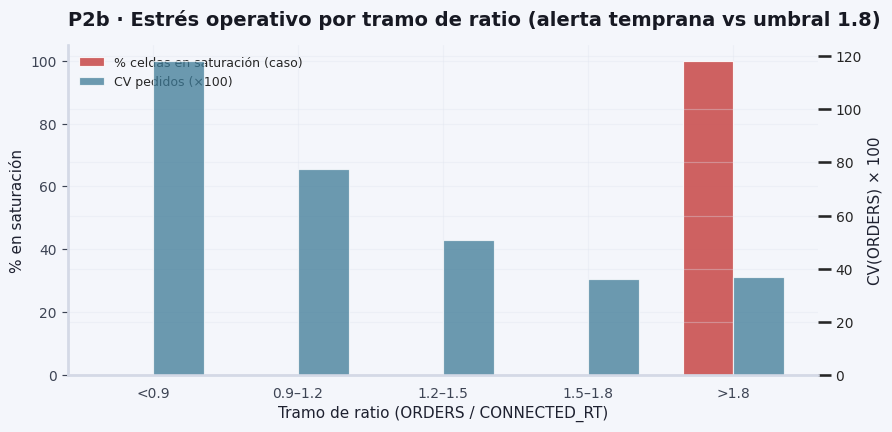

In [45]:
# P2b — Tabla + barras: % saturación y CV(ORDERS) por tramo de ratio (proxy de estrés sin NPS).
# --- P2b · Tramos de ratio + proxy de estrés (sin NPS en el Excel) ---
# Objetivo: ver cómo cambian (i) % filas ya en saturación y (ii) variabilidad de ORDERS
# al moverse el ratio por bandas; sirve como “alerta temprana” antes del umbral 1.8 del caso.

_bins = [-np.inf, 0.9, 1.2, 1.5, 1.8, np.inf]  # Cortes alineados a saludable (~0.9–1.2) y saturación (>1.8).
_labels = ["<0.9", "0.9–1.2", "1.2–1.5", "1.5–1.8", ">1.8"]  # Etiquetas legibles para cada intervalo de ratio.

_rp = raw.dropna(subset=["ratio", "ORDERS", "clasificacion"]).copy()  # Solo filas con ratio válido y columnas necesarias.
_rp["ratio_tramo"] = pd.cut(_rp["ratio"], bins=_bins, labels=_labels)  # Asigna cada fila a un tramo categórico (intervalo).

_tbl = (  # Tabla agregada: una fila por tramo de ratio.
    _rp.groupby("ratio_tramo", observed=True)  # observed=True: no muestra categorías vacías (pandas ≥2).
    .agg(
        n=("ratio", "size"),  # Número de observaciones (celdas hora×zona×día) en ese tramo.
        p_saturacion=("clasificacion", lambda s: (s == "saturacion").mean()),  # Fracción ya etiquetada saturación (ratio>1.8 en el caso).
        cv_orders=("ORDERS", lambda x: float(x.std() / x.mean()) if x.mean() > 1e-9 else np.nan),  # Coef. variación ORDERS = σ/μ (proxy de inestabilidad).
        ratio_mediana=("ratio", "median"),  # Mediana del ratio dentro del tramo (resumen robusto del nivel).
    )
    .reset_index()  # ratio_tramo pasa a ser columna normal en lugar de índice.
)
print("Resumen por tramo de ratio (proxy operativo; NPS no disponible):")  # NPS no está en el Excel; esto sustituye lectura de “estrés”.
print(_tbl.to_string(index=False, float_format=lambda x: "%.4f" % x if pd.notna(x) else ""))  # Tabla texto con 4 decimales; NaN como cadena vacía.

# FIG / save_fig / COLORS / plt: misma idea que en P2 (celda ejecutable sola).
import matplotlib.pyplot as plt  # Necesario para barras si no corriste la celda base completa.

if "COLORS" not in globals():  # Paleta mínima si falta la celda base.
    COLORS = {"ref_sat": "#c94c4c", "ref_ok": "#3d7a96"}

if "FIG" not in globals():
    from pathlib import Path as _PathFig

    if "PROJECT_ROOT" not in globals():
        _here = _PathFig.cwd().resolve()
        for _p in (_here, _here.parent, _here.parent.parent):
            if (_p / "data" / "rappi_delivery_case_data.xlsx").is_file():
                PROJECT_ROOT = _p
                break
        else:
            raise FileNotFoundError("No se encuentra el Excel; ejecuta la celda base.")
    FIG = PROJECT_ROOT / "modulo1_diagnostico" / "figures"
    FIG.mkdir(parents=True, exist_ok=True)

if "save_fig" not in globals():

    def save_fig(fig, path, dpi=200):
        fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")

fig, ax1 = plt.subplots(figsize=(9.2, 4.6), facecolor=plt.rcParams["figure.facecolor"])  # Figura y eje izquierdo (eje Y1).
x = np.arange(len(_tbl))  # Posiciones 0..n-1 para barras agrupadas por tramo.
w = 0.35  # Ancho de cada barra (mitad del hueco entre centros para dejar parejas lado a lado).

ax1.bar(x - w / 2, _tbl["p_saturacion"] * 100, width=w, label="% celdas en saturación (caso)", color=COLORS.get("ref_sat", "#c94c4c"), alpha=0.88, edgecolor="white")  # Eje Y1: % saturación (0–100).
ax1.set_ylabel("% en saturación")  # Etiqueta eje izquierdo.
ax1.set_xticks(x)  # Una marca por tramo.
ax1.set_xticklabels(list(_tbl["ratio_tramo"].astype(str)), rotation=0)  # Nombres de tramo bajo cada grupo de barras.

ax2 = ax1.twinx()  # Segundo eje Y compartiendo el mismo eje X (barras gemelas).
ax2.bar(x + w / 2, _tbl["cv_orders"] * 100, width=w, label="CV pedidos (×100)", color=COLORS.get("ref_ok", "#3d7a96"), alpha=0.75, edgecolor="white")  # Eje Y2: CV×100 para escala comparable a porcentajes.
ax2.set_ylabel("CV(ORDERS) × 100")  # Etiqueta eje derecho.

ax1.set_xlabel("Tramo de ratio (ORDERS / CONNECTED_RT)")  # Qué representa el eje X.
ax1.set_title("P2b · Estrés operativo por tramo de ratio (alerta temprana vs umbral 1.8)")  # Título descriptivo del gráfico.

if "polish_axes" in globals():  # Estética común del notebook (título a la izquierda, sin marco arriba/dcha).
    polish_axes(ax1)

h1, l1 = ax1.get_legend_handles_labels()  # Leyenda del eje izquierdo (saturación).
h2, l2 = ax2.get_legend_handles_labels()  # Leyenda del eje derecho (CV).
ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)  # Una sola leyenda combinada.

fig.tight_layout()  # Ajustar márgenes.
save_fig(fig, FIG / "p2_ratio_tramos_ops.png")  # Exportar PNG al directorio de figuras M1.
plt.show()  # Mostrar en el notebook.


### Causalidad operacional (lectura crítica)

> **Lectura sencilla:**
> Lo importante: el modelo **controla** hora y zona, pero **no demuestra** que la lluvia sea la única causa del caos (puede coincidir con horas de mucha hambre). Sirve para **priorizar** y para el motor de alertas, no para afirmar causalidad experimental.

**Qué ya cubre P2:** el MCO `ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE) + C(dow)` estima un efecto **marginal** de la lluvia con **hora, zona y día de la semana** fijos (correlación **controlada**). Es el estándar correcto para diagnóstico.

**Qué no prueba por sí solo:** que la lluvia **cause** saturación. Puede **coincidir** con franjas de alta demanda (hora pico) o con patrones espaciales: el coeficiente de precipitación resume un **promedio** condicional, no un experimento.

**Cómo subir el nivel (y alinear con el Módulo 2):** estimar explícitamente **cómo cambia la pendiente del mm/h según la hora**:

$$\text{ratio} \sim \text{PRECIPITATION\_MM} \times C(\text{HOUR}) + C(\text{ZONE})$$

Esto responde a: **¿un mm/h adicional “pega” distinto a las 15:00 que a las 21:00?** Sigue siendo **asociativo** (no hay instrumento ni A/B), pero **sí** prioriza *cuándo* las reglas de alerta deben ser más sensibles — la misma lógica de **contexto** que el motor de alertas.

**Efecto marginal interpretable:** para cada hora, la pendiente de `PRECIPITATION_MM` es $\beta_{\text{precip}} + \delta_h$ (con $h{=}0$ como categoría de referencia en el ajuste). Una frase útil para negocio es: *«cada +1 mm/h se asocia a +X en el ratio a esa hora (con zona controlada)»* — siempre con el matiz de **asociación**, no de causalidad experimental.

Modelo aditivo (P2)     R² = 0.7180   R² adj = 0.7168   n = 10080
Modelo interacción      R² = 0.7288   R² adj = 0.7271   n = 10080

Contraste de modelos anidados (¿la interacción lluvia×hora aporta conjuntamente?):
   df_resid         ssr  df_diff    ss_diff          F        Pr(>F)
0   10036.0  862.833131      0.0        NaN        NaN           NaN
1   10019.0  829.791358     17.0  33.041774  23.467666  1.105285e-72

Pendiente marginal de precipitación por hora (Δratio por +1 mm/h; HOUR=0 es categoría de referencia):
 HOUR  delta_ratio_por_1mm_h
    0              -0.116642
    1              +0.030652
    2              +0.092283
    3              -0.116642
    4              -0.116642
    5              -0.116642
    6              -0.040367
    7              -0.116642
    8              -0.016174
    9              -0.116642
   10              -0.071364
   11              -0.039205
   12              +0.128318
   13              +0.128944
   14              +0.177872
   15     

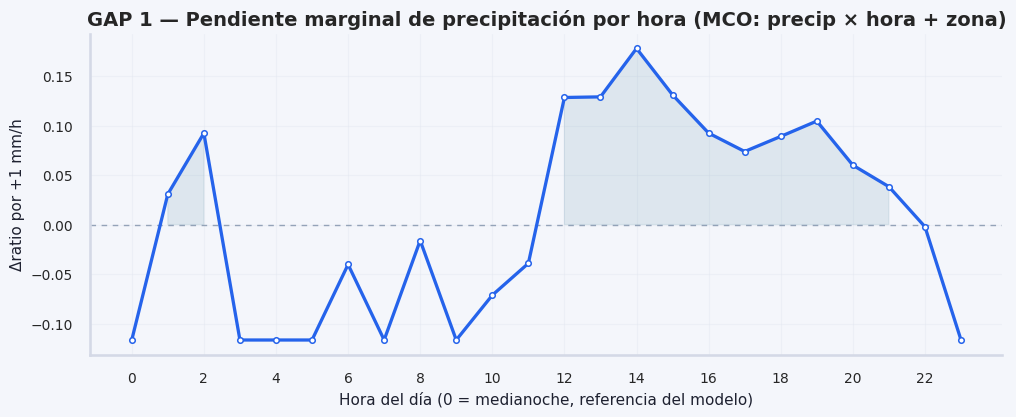

In [68]:
# --- GAP 1 — Interacción lluvia × hora y pendiente marginal por hora ---
# Modelo con término precip × C(HOUR): la pendiente de la lluvia puede cambiar por hora.
# HOUR=0 es categoría de referencia; cada hora h añade un incremento al β de precipitación.
from statsmodels.stats.anova import anova_lm

_gap1 = raw.copy()
_gap1["dow"] = pd.to_datetime(_gap1["DATE"]).dt.dayofweek  # Control de estacionalidad semanal (como P2).
m_add = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE) + C(dow)", data=_gap1).fit()  # Especificación aditiva (un solo β precip).
m_ix = smf.ols("ratio ~ PRECIPITATION_MM * C(HOUR) + C(ZONE) + C(dow)", data=_gap1).fit()  # Interacción precip × dummies de hora.

print("Modelo aditivo (P2)     R² = %.4f   R² adj = %.4f   n = %d" % (m_add.rsquared, m_add.rsquared_adj, int(m_add.nobs)))
print("Modelo interacción      R² = %.4f   R² adj = %.4f   n = %d" % (m_ix.rsquared, m_ix.rsquared_adj, int(m_ix.nobs)))
print("\nContraste de modelos anidados (¿la interacción lluvia×hora aporta conjuntamente?):")
print(anova_lm(m_add, m_ix))

# Reconstruir pendiente marginal Δratio / +1 mm/h para cada hora a partir de coeficientes del modelo con interacción.
_coef = m_ix.params
_beta0 = float(_coef["PRECIPITATION_MM"])  # Pendiente en la hora de referencia (HOUR=0).
_rows = []
for _h in range(24):
    if _h == 0:
        _marg = _beta0
    else:
        _k = "PRECIPITATION_MM:C(HOUR)[T.%d]" % _h  # Nombre patsy del término de interacción para hora h.
        _marg = _beta0 + float(_coef[_k])
    _rows.append({"HOUR": _h, "delta_ratio_por_1mm_h": _marg})

_marg_df = pd.DataFrame(_rows)
print("\nPendiente marginal de precipitación por hora (Δratio por +1 mm/h; HOUR=0 es categoría de referencia):")
print(_marg_df.to_string(index=False, float_format=lambda x: "%+.6f" % x))

_imax = _marg_df["delta_ratio_por_1mm_h"].idxmax()
_h_peak = int(_marg_df.loc[_imax, "HOUR"])
_v_peak = float(_marg_df.loc[_imax, "delta_ratio_por_1mm_h"])
print(
    "\n--- Frase negocio (hora con mayor pendiente estimada, %d:00) ---\n"
    "Cada +1 mm/h de precipitación se asocia a un cambio medio de aprox. %+.3f en el ratio "
    "(condicionado a la zona mediante dummies), según el MCO con interacción. "
    "Lectura asociativa, no causal."
    % (_h_peak, _v_peak)
)

_beta_p2 = float(m_add.params["PRECIPITATION_MM"])
print(
    "\n--- Modelo aditivo P2 (un solo β de precipitación con hora y zona en dummies) ---\n"
    "Cada +1 mm/h → Δratio medio %+.4f en el modelo lineal (interpretación global con controles)."
    % _beta_p2
)

# ---------- Figura: curva de pendientes marginales por hora ----------
if "COLORS" not in globals():
    import matplotlib.pyplot as plt
    import numpy as np
    COLORS = {"accent": "#2563eb", "ref_ok": "#3d7a96"}
if "save_fig" not in globals():
    def save_fig(fig, path, dpi=200):
        fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")

if "FIG" not in globals():
    from pathlib import Path as _PathFig

    if "PROJECT_ROOT" not in globals():
        _here = _PathFig.cwd().resolve()
        for _p in (_here, _here.parent, _here.parent.parent):
            if (_p / "data" / "rappi_delivery_case_data.xlsx").is_file():
                PROJECT_ROOT = _p
                break
        else:
            raise FileNotFoundError(
                "No se encuentra data/rappi_delivery_case_data.xlsx. Ejecuta la celda de imports base."
            )
    FIG = PROJECT_ROOT / "modulo1_diagnostico" / "figures"
    FIG.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10.4, 4.45), facecolor=plt.rcParams["figure.facecolor"])
ax.axhline(0, color="#94a3b8", linewidth=1.0, linestyle=(0, (4, 4)), zorder=1)
ax.fill_between(
    _marg_df["HOUR"],
    _marg_df["delta_ratio_por_1mm_h"],
    0,
    where=_marg_df["delta_ratio_por_1mm_h"].values >= 0,
    color=COLORS.get("ref_ok", "#3d7a96"),
    alpha=0.12,
    zorder=2,
)
ax.plot(
    _marg_df["HOUR"],
    _marg_df["delta_ratio_por_1mm_h"],
    color=COLORS.get("accent", "#2563eb"),
    linewidth=2.35,
    marker="o",
    markersize=4.0,
    markerfacecolor="white",
    markeredgewidth=1.1,
    zorder=4,
)
ax.set_xlabel("Hora del día (0 = medianoche, referencia del modelo)")
ax.set_ylabel("Δratio por +1 mm/h")
ax.set_title("GAP 1 — Pendiente marginal de precipitación por hora (MCO: precip × hora + zona)")
ax.set_xticks(range(0, 24, 2))
fig.tight_layout()
save_fig(fig, FIG / "gap1_precip_marginal_por_hora.png")
plt.show()


#### Pendiente marginal de lluvia por hora (interacción precip × hora)

> **Lectura sencilla:**
> Este gráfico pregunta: **¿un mismo chaparrón importa igual a las 8 h que a las 21 h?** La curva muestra en qué franjas un poco más de lluvia se asocia con más ratio, comparando con una hora base.

#### Qué mide el gráfico

El eje **Y** (“Δratio por +1 mm/h”) muestra la **pendiente marginal** del `ratio` respecto a la precipitación **en cada hora**, según el MCO con **interacción lluvia × hora**, efectos de **zona** y **`C(dow)`** (la especificación de la celda anterior). La **hora 0** es la **categoría de referencia**: en cada hora \(h\) se interpreta el **contraste** respecto a esa referencia (no el nivel absoluto del `ratio`).

En la práctica: indica **en qué franjas del día** un incremento de lluvia se asocia con una **subida (o bajada) adicional** del `ratio`, frente al patrón asociado a la madrugada de referencia.

#### Lectura cualitativa

1. **Zona de pendientes positivas (p. ej. ~11–12 h a ~22 h)**  
   Donde la curva está **claramente por encima de 0**, más mm/h se asocian con **más `ratio`** (más tensión demanda/oferta en el sentido del caso), **condicionado** al modelo. Coincide con **ventanas de demanda** (comida, tarde, cena).

2. **Pico hacia las ~14 h**  
   Si el máximo cae alrededor de las **14:00**, el efecto **marginal** de la lluvia sobre el `ratio` es **especialmente fuerte** a media tarde en este ajuste. Encaja con **P1** (muchas saturaciones al mediodía) y con la idea de que **no** es lo mismo llover a las 14:00 que a las 4:00.

3. **Madrugada y noche (curva a menudo por debajo de 0)**  
   En esas horas la pendiente **respecto a la referencia** puede ser **menor o negativa**: el modelo captura que el **mismo shock** de lluvia **no** empuja el `ratio` de la misma forma cuando la actividad base o el mix hora×zona son distintos. **No** implica automáticamente “la lluvia baja el ratio” en sentido causal puro: es **heterogeneidad por hora** y contraste con **HOUR=0**.

4. **Pequeños picos aislados (p. ej. ~2 h, ~8 h)**  
   Pueden ser **poco soporte** en esas horas, **ruido** o patrones débiles; conviene cruzar con **N por hora** si se quiere inferencia más fina.

#### Enlace con P2 “global”

En P2 el **β** de precipitación es un **promedio** condicional con hora y zona en el modelo **aditivo**.  muestra que el efecto **no es constante**: se **concentra** en franja diurna/vespertina y puede ser **máximo** hacia las **14 h**. Es la pieza de **heterogeneidad temporal** del mismo fenómeno.

#### Frase-resumen

La gráfica sugiere que la lluvia se asocia sobre todo con **subidas del `ratio` en horas de mayor actividad** (mediodía y tarde-noche), con un **efecto marginal muy alto** hacia la **14:00** en el panel estimado, mientras que de **madrugada** el patrón marginal es distinto (más bajo o negativo **respecto a la referencia**).

#### Matices

- Resultado de un **modelo lineal** sobre datos observados: **no** demuestra causalidad estricta (exogeneidad de la lluvia, confusores, etc.).
- Valores negativos son sobre todo **contraste con la hora 0** en esta parametrización; la lectura segura es **heterogeneidad por hora**, no un veredicto literal “lluvia mala de madrugada” sin contexto.


> **Lectura sencilla:**
> Este apartado une **medir presión** (mucho pedido por repartidor) con **decidir incentivos**: cuánto subir tarifa para traer más repartidores. Lo que sigue estima esa respuesta en el panel; los resultados **orientan** a Ops y finanzas, no reemplazan reglas de empresa.

**En lenguaje de equipo de Ops:** los números del notebook **informan** (“en estas horas y con esta lluvia el riesgo sube”), pero la **decisión** final (cuánto subir tarifa, en qué zona priorizar) sigue siendo política de negocio — equidad, presupuesto, reglas internas.



### No cerrar el loop con **decisiones** (muy importante)

El caso insinúa la pregunta operativa: **¿cuánto subir earnings?** para desestresar el `ratio`. Los bloques `ratio ~ …` describen **presión** (pedidos vs capacidad), pero hace falta un puente hacia **palancas**: incentivos → **repartidores conectados** (`CONNECTED_RT`).

**1. Modelo invertido (respuesta de oferta / supply response)**

$$\text{CONNECTED\_RT} \sim \text{EARNINGS} + \text{PRECIPITATION\_MM} + C(\text{HOUR}) + C(\text{ZONE})$$

El coeficiente de `EARNINGS` se interpreta como **pendiente**: cuántos **repartidores conectados** adicionales se asocian, en promedio, a **+1 unidad** de earnings en el panel (con hora, zona y lluvia controladas). Es lo más cercano a una **elasticidad en niveles** sin panel instrumental: **asociativo**, no A/B.

**Elasticidad (complemento técnico):** un modelo **log–log** `log(CONNECTED_RT) ~ log(EARNINGS) + …` da un coeficiente interpretable como **elasticidad aproximada**: *% esperado de cambio en RT por 1% de cambio en earnings* (condicionado a controles). La celda reporta también una **elasticidad puntual** $\hat\beta_{\text{EARNINGS}} \cdot (\bar e / \overline{\text{RT}})$ desde el modelo en **niveles** y **errores estándar agrupados por zona** para no inflar confianza ante correlación dentro de la misma zona.

**2. Identidad contable + objetivo de ratio**

$$\text{ratio} = \frac{\text{ORDERS}}{\text{CONNECTED\_RT}} \quad\Rightarrow\quad \text{CONNECTED\_RT}^{\,\text{meta}} = \frac{\text{ORDERS}}{\text{ratio}_{\text{objetivo}}}$$

(asumiendo **pedidos fijos** en el corto plazo). El **déficit de capacidad** es $\Delta \text{RT} = \text{RT}^{\,\text{meta}} - \text{CONNECTED\_RT}$. En porcentaje: $(\text{RT}^{\,\text{meta}}/\text{RT}) - 1$.

**3. Fórmula de decisión (aproximación lineal al MCO)**

Si $\hat\beta_{\text{EARNINGS}} = \partial \widehat{\text{CONNECTED\_RT}} / \partial \text{EARNINGS}$:

$$\Delta \text{EARNINGS} \approx \frac{\Delta \text{CONNECTED\_RT}}{\hat\beta_{\text{EARNINGS}}}$$

Frase tipo caso: *«Para bajar el ratio de 1,9 a 1,2 hace falta +X % capacidad → eso el modelo asocia a subir earnings de A a B MXN»* (orden de magnitud; ver celda siguiente con números del propio panel).

**4. Relación con P6** — `rebalance_incentives.py` optimiza el **reparto** del presupuesto; este bloque da la **historia contable + pendiente** que conecta earnings con RT fila a fila.

In [69]:
# --- GAP 2 — Oferta (supply): CONNECTED_RT ~ EARNINGS + controles + ejemplo numérico ---
# Pregunta: ¿cuántos repartidores conectados extra se asocian a +1 MXN de incentivo, fijando hora, zona y lluvia?
# Se ajusta MCO en niveles y (opcional) log–log; errores cluster por zona para dependencia intra-zona.
_gap2 = raw.dropna(subset=["CONNECTED_RT", "EARNINGS", "PRECIPITATION_MM", "HOUR", "ZONE"])
m_supply = smf.ols(
    "CONNECTED_RT ~ EARNINGS + PRECIPITATION_MM + C(HOUR) + C(ZONE)",
    data=_gap2,
).fit()
m_supply_clu = smf.ols(
    "CONNECTED_RT ~ EARNINGS + PRECIPITATION_MM + C(HOUR) + C(ZONE)",
    data=_gap2,
).fit(cov_type="cluster", cov_kwds={"groups": _gap2["ZONE"]})
_b = float(m_supply.params["EARNINGS"])
_ci_lo, _ci_hi = m_supply.conf_int().loc["EARNINGS"]
_b_se_clu = float(m_supply_clu.bse["EARNINGS"])
_ci_clu = m_supply_clu.conf_int().loc["EARNINGS"]
_mean_e = float(_gap2["EARNINGS"].mean())
_mean_rt = float(_gap2["CONNECTED_RT"].mean())
# Elasticidad puntual en niveles (aprox.): η ≈ β * (Ē / RT̄) — interpretación % en la media muestral.
_eta_point = _b * (_mean_e / _mean_rt) if _mean_rt > 1e-9 else float("nan")
print("MCO supply · CONNECTED_RT ~ EARNINGS + PRECIPITATION_MM + C(HOUR) + C(ZONE)")
print(
    "  β_EARNINGS = %.4f  (IC95%% i.i.d. [%.4f, %.4f])  p = %.4g"
    % (_b, _ci_lo, _ci_hi, float(m_supply.pvalues["EARNINGS"]))
)
print(
    "  SE cluster (zona) = %.4f  IC95%% cluster [%.4f, %.4f]  p_cluster = %.4g"
    % (_b_se_clu, float(_ci_clu[0]), float(_ci_clu[1]), float(m_supply_clu.pvalues["EARNINGS"]))
)
print(
    "  Elasticidad puntual (niveles, en la media): η ≈ β·(Ē/RT̄) = %.4f  (1%% más earnings → ~%.3f%% más RT aprox.)"
    % (_eta_point, _eta_point)
)
print(
    "  Interpretación: +1 unidad de EARNINGS → +%.3f repartidores conectados de media (cond. hora/zona/lluvia)."
    % _b
)
print("  R² = %.4f   R² adj = %.4f   n = %d" % (m_supply.rsquared, m_supply.rsquared_adj, int(m_supply.nobs)))

# Submuestra estrictamente positiva para log (evita log(0)).
_gaplog = _gap2.loc[(_gap2["CONNECTED_RT"] > 0) & (_gap2["EARNINGS"] > 0)].copy()
m_log = smf.ols(
    "np.log(CONNECTED_RT) ~ np.log(EARNINGS) + PRECIPITATION_MM + C(HOUR) + C(ZONE)",
    data=_gaplog,
).fit()
m_log_clu = smf.ols(
    "np.log(CONNECTED_RT) ~ np.log(EARNINGS) + PRECIPITATION_MM + C(HOUR) + C(ZONE)",
    data=_gaplog,
).fit(cov_type="cluster", cov_kwds={"groups": _gaplog["ZONE"]})
_log_e_name = [k for k in m_log.params.index if "EARNINGS" in k and "log" in k.lower()][0]
_el = float(m_log.params[_log_e_name])
_el_ci = m_log.conf_int().loc[_log_e_name]
_el_se_clu = float(m_log_clu.bse[_log_e_name])
_el_ci_clu = m_log_clu.conf_int().loc[_log_e_name]
print("\n--- Elasticidad log–log (aprox. %%ΔRT por 1%% Δearnings, mismo panel filtrado RT,E>0) ---")
print(
    "  η_log = %.4f  (IC95%% i.i.d. [%.4f, %.4f])  R² = %.4f  n = %d"
    % (_el, float(_el_ci[0]), float(_el_ci[1]), m_log.rsquared, int(m_log.nobs))
)
print(
    "  SE cluster (zona) = %.4f  IC95%% cluster [%.4f, %.4f]"
    % (_el_se_clu, float(_el_ci_clu[0]), float(_el_ci_clu[1]))
)

# ---------- Ejemplo transparente: cuánto subir incentivos para mover ratio con pedidos fijos ----------
TARGET_RATIO = 1.2
EXAMPLE_RATIO = 1.9  # Narrativa tipo caso (partida en estrés alto).
_ex = raw.dropna(subset=["ratio"]).query("ratio >= 1.75 & ratio < 2.0").sort_values("ratio")
if len(_ex) == 0:
    _ex = raw.dropna(subset=["ratio"]).query("ratio >= 1.5").sort_values("ratio", ascending=False)
_row = _ex.iloc[len(_ex) // 2]
_O = float(_row["ORDERS"])
_R = float(_row["CONNECTED_RT"])
_e0 = float(_row["EARNINGS"])
_r_obs = _O / _R
# Reescala ORDERS para fijar ratio de partida en EXAMPLE_RATIO manteniendo RT observado (solo ilustración).
if _O > 0 and _R > 0:
    _O_sc = _R * EXAMPLE_RATIO
else:
    _O_sc = _O
_R_star = _O_sc / TARGET_RATIO  # RT necesario para alcanzar TARGET_RATIO con esos pedidos.
_dR = _R_star - _R
_dE = _dR / _b if abs(_b) > 1e-8 else float("nan")  # Aproximación lineal ΔE ≈ ΔRT / β.
_e1 = _e0 + _dE
_pct = (_R_star - _R) / _R * 100 if _R > 0 else float("nan")

print("\n--- Ejemplo (pedidos fijos, misma celda zona–hora; ratio de partida ≈ %.2f) ---" % EXAMPLE_RATIO)
print(
    "  ORDERS (ajustado a ratio=%.1f con RT observado) = %.2f  |  CONNECTED_RT = %.2f  |  EARNINGS = %.2f"
    % (EXAMPLE_RATIO, _O_sc, _R, _e0)
)
print("  ratio_objetivo = %.2f  →  CONNECTED_RT_meta = ORDERS / ratio_obj = %.2f" % (TARGET_RATIO, _R_star))
print("  ΔCONNECTED_RT necesario = %+.2f  (~%+0.1f %% vs capacidad actual)" % (_dR, _pct))
print("  ΔEARNINGS ≈ ΔRT / β ≈ %+.2f MXN  →  earnings de referencia %.1f → %.1f MXN" % (_dE, _e0, _e1))
print(
    "\nFrase negocio: «Para acercar el ratio de ~%.1f a ~%.1f con esos pedidos, "
    "hace falta ~%+0.0f %% más capacidad; la pendiente del MCO sugiere ~%+0.0f MXN más de earnings "
    "(aprox. lineal, no óptimo de política).»"
    % (EXAMPLE_RATIO, TARGET_RATIO, _pct, _dE)
)


MCO supply · CONNECTED_RT ~ EARNINGS + PRECIPITATION_MM + C(HOUR) + C(ZONE)
  β_EARNINGS = 0.3401  (IC95% i.i.d. [0.3333, 0.3469])  p = 0
  SE cluster (zona) = 0.0301  IC95% cluster [0.2812, 0.3990]  p_cluster = 1.119e-29
  Elasticidad puntual (niveles, en la media): η ≈ β·(Ē/RT̄) = 2.1464  (1% más earnings → ~2.146% más RT aprox.)
  Interpretación: +1 unidad de EARNINGS → +0.340 repartidores conectados de media (cond. hora/zona/lluvia).
  R² = 0.8982   R² adj = 0.8978   n = 10080

--- Elasticidad log–log (aprox. %%ΔRT por 1%% Δearnings, mismo panel filtrado RT,E>0) ---
  η_log = 1.5928  (IC95% i.i.d. [1.5691, 1.6166])  R² = 0.9812  n = 10080
  SE cluster (zona) = 0.0222  IC95% cluster [1.5493, 1.6364]

--- Ejemplo (pedidos fijos, misma celda zona–hora; ratio de partida ≈ 1.90) ---
  ORDERS (ajustado a ratio=1.9 con RT observado) = 34.20  |  CONNECTED_RT = 18.00  |  EARNINGS = 54.60
  ratio_objetivo = 1.20  →  CONNECTED_RT_meta = ORDERS / ratio_obj = 28.50
  ΔCONNECTED_RT necesario = +

#### MCO supply (`CONNECTED_RT` ~ `EARNINGS` + controles) y ejemplo mecánico

> **Lectura sencilla:**
> Aquí se mira la **oferta**: si subes la tarifa (earnings), ¿cuántos repartidores conectados más suelen aparecer en el panel, dejando fijos hora, zona y lluvia? Es una **pendiente estimada**, no una orden automática de cuánto pagar.

### Qué modelo es

Es un **MCO** con variable dependiente **`CONNECTED_RT`** (repartidores conectados en la fila hora×zona×día) y regresores **`EARNINGS`**, **`PRECIPITATION_MM`** y efectos fijos **`C(HOUR)`** y **`C(ZONE)`**.

Se interpreta como **respuesta de oferta** en el panel: *manteniendo fijas la hora, la zona y la lluvia*, ¿cuánto más **RT** se asocia con **un peso más de earnings**? No es un experimento ni la política óptima; es la **pendiente estimada** en datos observacionales.

### Coeficiente β_EARNINGS (niveles)

| Idea | Contenido |
|------|-----------|
| **Lectura directa** | **+1 MXN** de `EARNINGS` se asocia con **+β** unidades de `CONNECTED_RT` de media (condicional a hora, zona y lluvia). |
| **IC i.i.d. y p** | Intervalo estrecho y p casi 0: efecto **muy estable** si se asumiera independencia entre filas. |
| **SE cluster (zona)** | Las filas de la **misma zona** se correlacionan; el SE sube y el IC se **ensancha**, pero el efecto suele seguir **muy significativo** (p cluster muy pequeño). |

**R² alto (~0.90):** con hora y zona, `CONNECTED_RT` es muy predecible; el coeficiente de **earnings** mide el **margen** dentro de ese ajuste.

### Elasticidad puntual en la media (η ≈ β·(Ē/RT̄))

- Aproximación de “**+1 % en earnings** → **+η % en RT**” alrededor de la media del panel (modelo **lineal en niveles**).
- **No** tiene por coincidir con la elasticidad **log–log**: aquí conviertes a porcentajes solo en un punto (la media).

### Elasticidad log–log (η_log)

- Modelo del tipo **log(RT) ~ log(EARNINGS) + …**: **η_log** es la elasticidad estándar (**+1 % earnings → +η_log % RT** aprox.), homogénea en sentido logarítmico.
- **R²** en logs puede ser muy alto; sigue sin implicar causalidad estricta.
- **Cluster por zona:** mismo criterio que arriba — inferencia más conservadora.

**Por qué difieren η y η_log:** son **parametrizaciones distintas** (aproximación local en niveles vs curva log en todo el rango típico).

### Ejemplo numérico (ratio ~1.9 → objetivo 1.2)

Pasos lógicos:

1. Con **pedidos fijos** y **RT** observado, el ratio de partida es \(O/\text{RT}\).
2. Para alcanzar **ratio_obj**, hace falta **RT_meta = ORDERS / ratio_obj** (identidad contable).
3. **ΔRT** = RT_meta − RT actual.
4. Con pendiente lineal **β**, **ΔEARNINGS ≈ ΔRT / β** es un **back-of-envelope** (no óptimo de política).

**Qué sí dice:** orden de magnitud del **subidón de incentivo** que, **si** valiera la linealidad y el resto fijo, “cuadraría” con el ΔRT necesario.

**Qué no dice:** que ese incremento sea **óptimo**, **lineal lejos de la media** o realizable sin fricciones operativas.

### Frase de negocio

Para pasar de un ratio **alto** (p. ej. ~1.9) a un **objetivo** (p. ej. 1.2) con **los mismos pedidos**, hace falta **mucho más** `CONNECTED_RT` (en el ejemplo, un salto porcentual grande); la pendiente del MCO sugiere un orden de magnitud de **ΔEARNINGS** en MXN como **ilustración mecánica**, **no** como regla óptima de operaciones.


### Modelar el problema como **predicción** 

> **Lectura sencilla:**
> Pasamos de describir el pasado a estimar **probabilidad** de saturación (ratio alto) con lluvia, tarifa y hora. Eso permite escenarios tipo “si llueve X y pagamos Y, qué tan probable es el estrés”.

Hasta aquí el trabajo es **descriptivo** (distribuciones, MCO, correlaciones). El **sistema operativo** necesita traducir señales en **probabilidad de un evento futuro** — en este caso, **saturación** (`ratio > 1.8`) — para decidir si **alertar**.

**Clasificación (simple y usable):**

- `is_saturated = 1` si `ratio > 1.8`, `0` si no (filas sin `ratio` válido se excluyen del ajuste).

**Logit:**

$$\text{is\_saturated} \sim \text{PRECIPITATION\_MM} + \text{EARNINGS} + C(\text{HOUR}) + C(\text{ZONE})$$

Con el modelo ajustado puedes **predecir** $\Pr(\text{saturación} \mid \mathbf{x})$. El valor **depende** de hora, zona y earnings: una referencia “promedio” puede dar probabilidad **casi nula** si en el panel casi no hay saturación en esa tupla. La celda siguiente contrasta ese caso con una **plantilla de estrés** (fila real con `is_saturated=1`, variando solo mm/h), donde la curva 0 → 3 → 6 mm/h sí es **interpretable** y encaja con frases tipo negocio (*«con ~6 mm/h, P alta»*).

**Puente al motor de alertas (Módulo 2):** regla del tipo `if prob_saturacion > 0.7: alert()` — el umbral es **política** (calibrar con coste de falsos positivos/negativos); aquí solo se **demuestra** el cableado **probabilidad → decisión**.

In [70]:
# --- GAP 3 — Logit: P(saturación) y regla tipo alerta (espíritu Módulo 2) ---
# Variable dependiente binaria: is_saturated = 1 si ratio > 1.8 (mismo umbral del caso).
import numpy as np

raw["is_saturated"] = np.where(
    raw["ratio"].isna(),
    np.nan,
    (raw["ratio"] > 1.8).astype(int),
)
_g3 = raw.dropna(subset=["is_saturated", "PRECIPITATION_MM", "EARNINGS"]).copy()
_g3["is_saturated"] = _g3["is_saturated"].astype(int)

print(
    "Base: fracción de filas saturadas = %.3f  (n=%d, ratio válido)"
    % (_g3["is_saturated"].mean(), len(_g3))
)

logit_sat = smf.logit(
    "is_saturated ~ PRECIPITATION_MM + EARNINGS + C(HOUR) + C(ZONE)",
    data=_g3,
).fit(disp=0)
print(logit_sat.summary2().tables[0])

# Escenario A — tupla "genérica" (moda zona, mediana hora, media earnings).
_REF_ZONE = str(_g3["ZONE"].mode().iloc[0])
_REF_HOUR = int(_g3["HOUR"].median())
_REF_EARN = float(_g3["EARNINGS"].mean())


def _prob_sat_row(mm_h: float, earn: float, hour: int, zone: str) -> float:
    # P̂(sat) del logit en un punto (lluvia, incentivo, hora, zona).
    _df = pd.DataFrame(
        {
            "PRECIPITATION_MM": [mm_h],
            "EARNINGS": [earn],
            "HOUR": [hour],
            "ZONE": [zone],
        }
    )
    return float(logit_sat.predict(_df).iloc[0])


print(
    "\n[A] Referencia · zona=%r  hora=%d  earnings≈%.2f (moda/mediana/media)"
    % (_REF_ZONE, _REF_HOUR, _REF_EARN)
)
for _mm in (0.0, 3.0, 6.0):
    _p = _prob_sat_row(_mm, _REF_EARN, _REF_HOUR, _REF_ZONE)
    print("  P(sat | precip=%.1f mm/h) ≈ %.2f %%" % (_mm, 100 * _p))

# Escenario B — fila realmente saturada como plantilla (mantiene zona/hora/earn observados).
_sat_rows = _g3[_g3["is_saturated"] == 1]
_tpl = _sat_rows.iloc[len(_sat_rows) // 2]
_TZ = str(_tpl["ZONE"])
_TH = int(_tpl["HOUR"])
_TE = float(_tpl["EARNINGS"])
print(
    "\n[B] Plantilla estrés (celda real saturada) · zona=%r  hora=%d  earnings=%.2f"
    % (_TZ, _TH, _TE)
)
for _mm in (0.0, 3.0, 6.0):
    _p = _prob_sat_row(_mm, _TE, _TH, _TZ)
    print("  P(sat | precip=%.1f mm/h) ≈ %.1f %%" % (_mm, 100 * _p))

_p6 = _prob_sat_row(6.0, _TE, _TH, _TZ)
print(
    "\n--- Frase tipo caso (plantilla [B], 6 mm/h) ---\n"
    "«Con ~6 mm/h de lluvia (manteniendo hora/zona/earnings de una celda saturada típica), "
    "P(saturación) ≈ %.0f %%.»"
    % (100 * _p6)
)

ALERT_THRESHOLD = 0.7


def alert_if_saturated_risk(prob: float, threshold: float = ALERT_THRESHOLD) -> bool:
    # Umbral de política: disparar alerta si probabilidad predicha supera threshold.
    return prob > threshold


print(
    "\n--- Regla tipo Módulo 2 ---\n"
    "if prob_saturacion > %.1f: alert()  →  a 6 mm/h [B]: %s"
    % (ALERT_THRESHOLD, alert_if_saturated_risk(_p6))
)


Base: fracción de filas saturadas = 0.051  (n=10080, ratio válido)
                     0                 1                  2          3
0               Model:             Logit            Method:        MLE
1  Dependent Variable:      is_saturated  Pseudo R-squared:      0.700
2                Date:  2026-04-03 19:27               AIC:  1294.7578
3    No. Observations:             10080               BIC:  1576.2719
4            Df Model:                38    Log-Likelihood:    -608.38
5        Df Residuals:             10041           LL-Null:    -2027.4
6           Converged:            1.0000       LLR p-value:     0.0000
7      No. Iterations:           22.0000             Scale:     1.0000

[A] Referencia · zona='Apodaca Centro'  hora=11  earnings≈57.70 (moda/mediana/media)
  P(sat | precip=0.0 mm/h) ≈ 0.00 %
  P(sat | precip=3.0 mm/h) ≈ 0.00 %
  P(sat | precip=6.0 mm/h) ≈ 0.00 %

[B] Plantilla estrés (celda real saturada) · zona='La Fe'  hora=21  earnings=56.50
  P(sat | precip

#### Logit `P(saturación)` y escenarios [A] / [B]

> **Lectura sencilla:**
> El modelo predice **qué tan probable** es estar saturado en distintos escenarios. La tabla resume qué tan bien explica el patrón; los números dependen de la hora y la zona — no hay un solo “%” universal.

### «Base: fracción de filas saturadas = 0.051 (n = 10080)»

En el panel hay **10 080** filas con `ratio` válido. En **~5,1 %** de ellas la fila está en **saturación** (`ratio > 1.8` → `is_saturated = 1`). Es la **frecuencia bruta** del evento antes de condicionar por lluvia, hora, zona y earnings: el evento es **relativamente raro** en crudo. El logit usa esa base y añade predictores para explicar **cuándo** sube la probabilidad.

### Tabla resumen del modelo Logit

| Campo | Lectura |
|--------|---------|
| **Dependent Variable: is_saturated** | Se modela **P(saturación = 1)** con **logit** (MLE). |
| **Pseudo R²** (~0.70) | Mejora frente al modelo que solo predice la media; **no** es el R² del MCO lineal. |
| **Log-Likelihood vs LL-Null** | El bloque de predictores reduce mucho el error frente al modelo nulo (**LLR p-value ≈ 0** → aportan **conjuntamente**). |
| **AIC / BIC** | Útiles para **comparar** especificaciones; no bastan solos como “bondad” absoluta. |
| **Converged** | El optimizador encontró solución. |

En conjunto: el logit **encaja bien** la probabilidad de saturación con lluvia, earnings, hora y zona (en el panel observado).


### Escenario [A] — Referencia (Apodaca Centro, hora 11, earnings ~57.7)

Tupla **típica** (moda/mediana/media) para un punto **no extremo** del panel.

- Con **0, 3 o 6 mm/h**, **P(saturación)** predicha **≈ 0 %**.
- Lectura: en esa combinación zona/hora/earnings, el modelo sitúa el riesgo de saturación **muy bajo** incluso con algo de lluvia: **baja presión** relativa en ese punto del espacio de covariables.

### Escenario [B] — Plantilla estrés (La Fe, hora 21, earnings 56.5)

Celda **real** con estrés (saturación); se **fijan** zona, hora y earnings y solo **varía** la lluvia.

| Lluvia | P(sat) aprox. |
|--------|----------------|
| 0 mm/h | **~8 %** |
| 3 mm/h | **~67 %** |
| 6 mm/h | **~98 %** |

Lectura: **condicional** a esa hora/zona/earnings, más precipitación se asocia con **mucho más** riesgo de saturación según el logit. Es el mapa **estimado** en datos; no garantiza el mismo resultado fuera de muestra.

### Frase tipo caso

Con **~6 mm/h** y la plantilla **[B]**, el modelo asigna **P(saturación) ≈ 98 %** — útil como **narrativa** para Operations (“bajo esas condiciones el modelo ve casi segura la saturación”).

### Regla tipo Módulo 2: `if prob_saturacion > 0.7: alert()`

- Umbral **0.7** = “alta probabilidad” en una regla **simple**.
- Con **[B]** y **6 mm/h**, **P ≈ 0.98 > 0.7** → **`alert()` = True** (en esta lógica reducida).
- Con **[A]**, P ≈ 0 → **no** dispara por probabilidad (un motor real puede añadir más condiciones: lluvia mínima, etc.).

### Frase-resumen

La **base** muestra que saturar es **poco frecuente** en crudo (~5 %); el **logit** estima cómo cambia el **riesgo** con covariables; **[A]** ilustra un contexto **tranquilo**, **[B]** uno **tenso** donde la lluvia **dispara** P(sat); la regla **> 0.7** lo traduce en **alerta** en el ejemplo [B] con lluvia fuerte.

### P3 — Heterogeneidad por zona (sensibilidad a lluvia)

> **Lectura sencilla:**
> P3 mira si **cada barrio** reacciona distinto a la lluvia: en uno el ratio puede dispararse con poca lluvia y en otro no. Eso alimenta **reglas distintas por zona** (como en el Módulo 2).

**Nota:** Se estima **por cada zona** un modelo `ratio ~ PRECIPITATION_MM + C(HOUR) + C(dow)` —equivalente a **estratificar** el panel por `ZONE` y ajustar el mismo MCO dentro de cada estrato (`Teoria/Machine Learning/tema5.pdf`, idea de submodelos / heterogeneidad). Así se evita una única pendiente de lluvia “promedio” que oculte **sensibilidades distintas** por territorio. El gráfico muestra el **coeficiente marginal de precipitación** por zona: pendientes mayores en valor absoluto sugieren zonas donde el ratio responde más a la lluvia **condicionado a hora y día de la semana** dentro de esa zona.

                  ZONE  coef_precip_mm
0             Santiago        0.190569
1   Carretera Nacional        0.131460
2       Santa Catarina        0.103332
3  MTY_Apodaca_Huinalá        0.085885
4        Independencia        0.073652
5            San Pedro        0.068153
6       Apodaca Centro        0.065663
7             Escobedo        0.063273


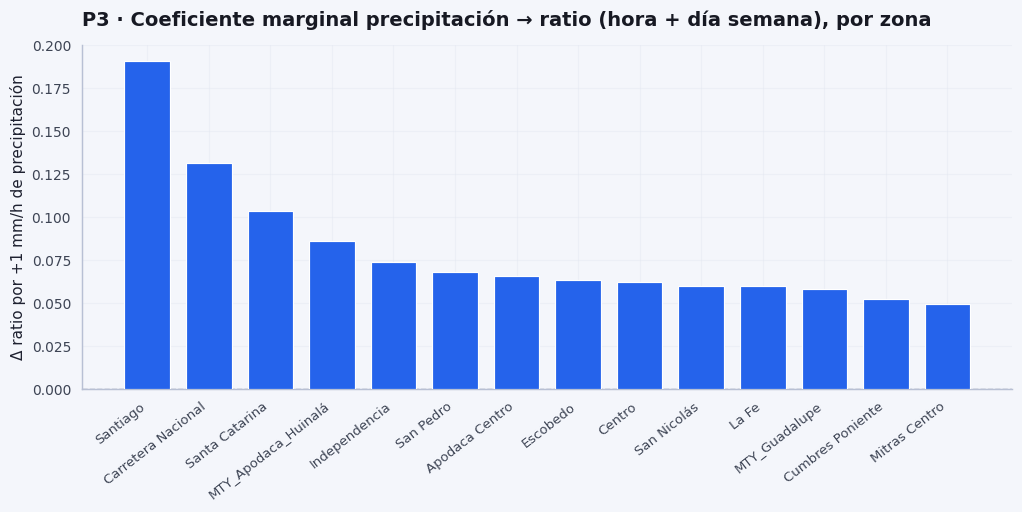

In [71]:
# --- P3 · Sensibilidad del ratio a la lluvia por zona (MCO estratificado) ---
# Objetivo: estimar, **dentro de cada zona**, cuánto cambia el ratio ante +1 mm/h de precipitación,
# dejando fijos los efectos de **hora** y **día de la semana** (dummies). Así se ve heterogeneidad territorial.
# Requiere `raw` con ZONE, ratio, PRECIPITATION_MM, HOUR, DATE (y opcionalmente columna `dow`).

# ---------- Entorno gráfico (celda ejecutable sola) ----------
# Si no corriste la celda base del notebook, se definen paleta, carpeta FIG, save_fig y polish_axes aquí.
if "COLORS" not in globals():
    import matplotlib.pyplot as plt
    import numpy as np
    COLORS = {
        "p1_hours": plt.cm.magma(np.linspace(0.22, 0.88, 24)),
        "p1_zones_cmap": "Reds",
        "p3_bar": "#3d6b8e",
        "p4_face": "#2a9d8f",
        "p4_edge": "#1b4332",
        "sens_bar": "#1d3557",
    }
if "save_fig" not in globals():
    def save_fig(fig, path, dpi=200):
        fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")

if "FIG" not in globals():
    from pathlib import Path as _PathFig

    if "PROJECT_ROOT" not in globals():
        _here = _PathFig.cwd().resolve()
        for _p in (_here, _here.parent, _here.parent.parent):
            if (_p / "data" / "rappi_delivery_case_data.xlsx").is_file():
                PROJECT_ROOT = _p
                break
        else:
            raise FileNotFoundError(
                "No se encuentra data/rappi_delivery_case_data.xlsx. Ejecuta la celda de imports base."
            )
    FIG = PROJECT_ROOT / "modulo1_diagnostico" / "figures"
    FIG.mkdir(parents=True, exist_ok=True)

if "polish_axes" not in globals():
    def polish_axes(ax, title_pad=14):
        title = ax.get_title()
        ax.set_title("")
        ax.set_title(title, loc="left", pad=title_pad, fontsize=14, fontweight="600", color="#171923")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_linewidth(1.05)
            ax.spines[side].set_color("#b8c0d4")
        ax.tick_params(axis="both", which="major", length=4.5, width=0.85, colors="#3d4454")

import pandas as pd
import statsmodels.formula.api as smf

# Patsy necesita columna `dow` para C(dow); si solo corres esta celda, se deriva de DATE.
if "dow" not in raw.columns:
    raw = raw.copy()
    raw["dow"] = pd.to_datetime(raw["DATE"], errors="coerce").dt.dayofweek

# ---------- MCO por zona: pendiente marginal de PRECIPITATION_MM ----------
# Misma fórmula que en otros bloques (GAP): β_precip = Δratio asociado a +1 mm/h **condicional** a HOUR y dow.
slopes = []
for z in sorted(raw["ZONE"].unique()):
    sub = raw[raw["ZONE"] == z]  # Estrato: solo filas de esa zona.
    mz = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR) + C(dow)", data=sub).fit()
    slopes.append((z, float(mz.params["PRECIPITATION_MM"])))

slopes = sorted(slopes, key=lambda x: -abs(x[1]))  # Prioriza zonas con |pendiente| grande (mapa de sensibilidad).
coef_df = pd.DataFrame(slopes, columns=["ZONE", "coef_precip_mm"])
print(coef_df.head(8))

# ---------- Figura: barras = coeficiente por zona (orden por |β|) ----------
fig, ax = plt.subplots(figsize=(10.5, 5.4), facecolor=plt.rcParams["figure.facecolor"])
x = np.arange(len(coef_df))  # Posiciones 0..n-1 en el eje X (etiquetas = nombres de zona).
ax.bar(
    x,
    coef_df["coef_precip_mm"],
    color=COLORS.get("p3_bar", "#2563eb"),  # .get: evita KeyError si COLORS vino de otra celda sin `p3_bar`.
    edgecolor="white",
    linewidth=0.85,
    width=0.74,
    zorder=3,
)
ax.axhline(0, color="#8892a6", linewidth=1.0, linestyle="--", zorder=2)  # Referencia: sin efecto lineal local de lluvia.
ax.set_xticks(x)
ax.set_xticklabels(coef_df["ZONE"], rotation=38, ha="right", fontsize=9.5)
ax.set_ylabel("Δ ratio por +1 mm/h de precipitación")
ax.set_title("P3 · Coeficiente marginal precipitación → ratio (hora + día semana), por zona")
polish_axes(ax)
ax.grid(axis="y", zorder=0)
fig.tight_layout()
save_fig(fig, FIG / "p3_sensibilidad_zona.png")
plt.show()


#### Sensibilidad marginal de la lluvia por zona (`coef_precip_mm`)

> **Lectura sencilla:**
> La tabla y la gráfica ordenan zonas por “**cuánto sube el ratio** si aumenta un poco la lluvia en ese barrio”, con hora y día controlados. Es la base de la **sensibilidad por zona** del caso.

### Qué estima el bloque

Por **cada zona** se ajusta un MCO del tipo **`ratio ~ PRECIPITATION_MM + C(HOUR) + C(dow)`** (misma especificación **dentro** de cada `ZONE`). La columna **`coef_precip_mm`** es la **pendiente** de la precipitación en esa zona:

> **+1 mm/h** adicional se asocia con un cambio de **`coef_precip_mm` unidades** en el `ratio`, **manteniendo fijos hora y día de la semana** (efectos `C(HOUR)` y `C(dow)` dentro del estrato).

No es una probabilidad; es **efecto marginal sobre el ratio** en el panel observado, **por zona**.

### Cómo leer la tabla y el gráfico de barras

- El eje vertical (**Δratio por +1 mm/h**) coincide con **`coef_precip_mm`**.
- Las zonas suelen ordenarse de **mayor a menor** coeficiente: arriba, donde el **mismo incremento** de lluvia se asocia con un **mayor** aumento del `ratio` (en este ajuste).

| Lectura cualitativa | Contenido |
|---------------------|-----------|
| **Cola alta del ranking** (p. ej. **Santiago**, **Carretera Nacional**, **Santa Catarina** en muchas ejecuciones) | Pendientes **más altas**: mayor sensibilidad **marginal** del `ratio` a la lluvia **condicional a hora y día de la semana**. |
| **Zonas centrales / cola baja** | Pendientes **menores**: misma lluvia se asocia con una **subida más suave** del `ratio` en términos del modelo. |

La conclusión principal es **heterogeneidad espacial**: **la lluvia no empuja el `ratio` igual** en todas las zonas cuando se controlan **hora y día de la semana** **dentro** de cada una.

### Uso operativo (con matices)

- Zonas con **coeficiente alto** son candidatas a **más atención** en lluvia (alertas, incentivos, capacidad) **si** el criterio de negocio es “donde la lluvia asocia más fuerte a tensión en el `ratio`”.
- **No** implica causalidad perfecta ni que “periferia vs centro” sea la explicación única: puede haber **confusión** con otros factores correlacionados con lluvia por zona.
- El MCO es **lineal en mm/h**; lluvias **extremas** pueden comportarse peor fuera del rango típico.

### Frase-resumen

**P3 ordena las zonas por la pendiente marginal de precipitación sobre el `ratio` (hora y día de la semana controlados dentro de la zona): sirve para priorizar dónde un mismo shock de lluvia se asocia con mayor presión en el `ratio` observado, no para afirmar por sí solo un mecanismo causal detallado.**


### P4 — Calibración de earnings y posible gasto ineficiente

> **Lectura sencilla:**
> P4 junta información **por día**: días muy estresados vs días con mucho incentivo pero poca presión. Sirve para detectar **posible gasto raro**; el siguiente bloque refina la lectura hora a hora.

**Nota:** Se **agrega por día** (`DATE`): earnings medio del día, **fracción de filas en saturación** (`sat_frac`), **fracción en sobre-oferta** (`sobre_frac`) y ratio medio. Ordenar por `sat_frac` destaca **días con más estrés**. La salida incluye **enumeración explícita de fechas** (año-mes-día y día de la semana) para los tops y para reglas p75 — útil para el informe (“el **2024-03-28**…”). La nube **earnings vs sat_frac** y el corte **p75 earn × p75 sobre-oferta** ayudan a localizar **posible gasto sin presión de saturación**.

**Siguiente (GAP 4):** contraste **intra-hora** (alto vs bajo earnings en la misma `HOUR`) para acercarse a lectura **contrafactual** y mitigar confusión **demanda–incentivo** de la agregación diaria.

Días con mayor fracción de horas saturadas (top 10):
          DATE  earn_mean  sat_frac  sobre_frac  ratio_mean
27  2024-03-28  55.863393  0.166667    0.199405    1.102925
7   2024-03-08  56.218155  0.139881    0.217262    0.975630
24  2024-03-25  56.071131  0.130952    0.214286    0.896001
4   2024-03-05  57.172917  0.095238    0.205357    0.979752
26  2024-03-27  56.660714  0.065476    0.214286    0.809092
13  2024-03-14  60.444940  0.050595    0.279762    0.746482
15  2024-03-16  57.166369  0.050595    0.220238    0.800138
0   2024-03-01  56.587500  0.047619    0.196429    0.830797
17  2024-03-18  56.638393  0.044643    0.202381    0.814346
25  2024-03-26  56.550595  0.044643    0.217262    0.816600

Días candidatos a desalineación earn vs estrés (p75 earn y p75 sat_frac):
          DATE  earn_mean  sat_frac  sobre_frac
13  2024-03-14   60.44494  0.050595    0.279762

Días candidatos: incentivo diario alto (p75 earn) y mucha sobre-oferta (p75 sobre_frac):
          DATE  earn_mean 

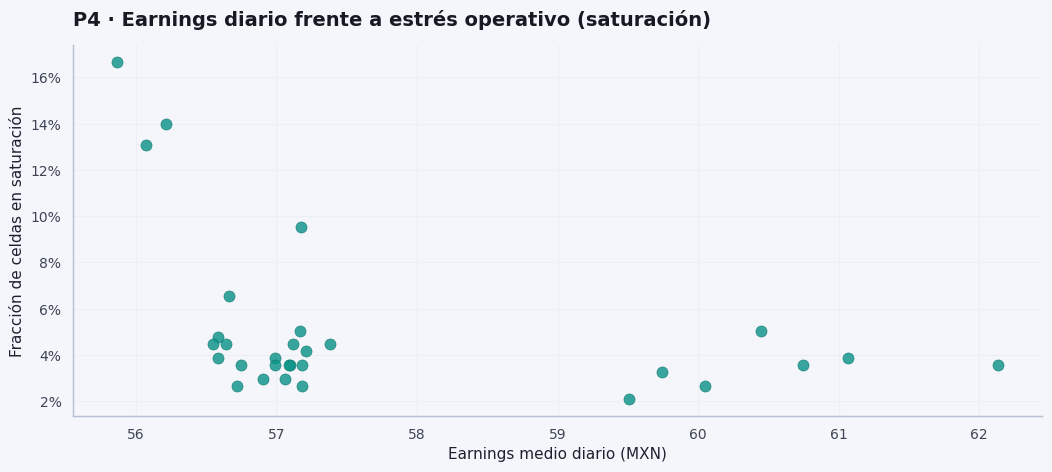

In [50]:
# --- P4 · Earnings diarios frente a estrés (saturación / sobre-oferta) ---
# Estilo de figuras (por si no ejecutaste la celda de imports completa)
if "COLORS" not in globals():
    import matplotlib.pyplot as plt
    import numpy as np
    COLORS = {
        "p1_hours": plt.cm.magma(np.linspace(0.22, 0.88, 24)),
        "p1_zones_cmap": "Reds",
        "p3_bar": "#3d6b8e",
        "p4_face": "#2a9d8f",
        "p4_edge": "#1b4332",
        "sens_bar": "#1d3557",
    }
if "save_fig" not in globals():
    def save_fig(fig, path, dpi=200):
        fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")

if "FIG" not in globals():
    from pathlib import Path as _PathFig

    if "PROJECT_ROOT" not in globals():
        _here = _PathFig.cwd().resolve()
        for _p in (_here, _here.parent, _here.parent.parent):
            if (_p / "data" / "rappi_delivery_case_data.xlsx").is_file():
                PROJECT_ROOT = _p
                break
        else:
            raise FileNotFoundError(
                "No se encuentra data/rappi_delivery_case_data.xlsx. Ejecuta la celda de imports base."
            )
    FIG = PROJECT_ROOT / "modulo1_diagnostico" / "figures"
    FIG.mkdir(parents=True, exist_ok=True)

if "polish_axes" not in globals():
    def polish_axes(ax, title_pad=14):
        title = ax.get_title()
        ax.set_title("")
        ax.set_title(title, loc="left", pad=title_pad, fontsize=14, fontweight="600", color="#171923")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_linewidth(1.05)
            ax.spines[side].set_color("#b8c0d4")
        ax.tick_params(axis="both", which="major", length=4.5, width=0.85, colors="#3d4454")

# Agregamos a nivel DATE: earn medio, fracciones de clasificación y ratio medio (un punto = un día).
daily = raw.groupby("DATE").agg(
    earn_mean=("EARNINGS", "mean"),
    sat_frac=("clasificacion", lambda s: (s == "saturacion").mean()),
    sobre_frac=("clasificacion", lambda s: (s == "sobre_oferta").mean()),
    ratio_mean=("ratio", "mean"),
).reset_index()

_daily_stress = daily.sort_values("sat_frac", ascending=False)
print("Días con mayor fracción de horas saturadas (top 10):")
print(_daily_stress.head(10))

# Percentiles 75 simultáneos: días con incentivo alto Y estrés alto (posible desalineación gasto–riesgo).
p75_e = daily["earn_mean"].quantile(0.75)
p75_sat = daily["sat_frac"].quantile(0.75)
stress = daily["sat_frac"] >= p75_sat
ineff = daily[(daily["earn_mean"] >= p75_e) & stress]
print("\nDías candidatos a desalineación earn vs estrés (p75 earn y p75 sat_frac):")
print(ineff[["DATE", "earn_mean", "sat_frac", "sobre_frac"]])

# Variante: mucho incentivo pero mucha sobre-oferta (poca presión de saturación).
p75_sobre = daily["sobre_frac"].quantile(0.75)
ineff_b = daily[(daily["earn_mean"] >= p75_e) & (daily["sobre_frac"] >= p75_sobre)]
print("\nDías candidatos: incentivo diario alto (p75 earn) y mucha sobre-oferta (p75 sobre_frac):")
print(ineff_b[["DATE", "earn_mean", "sat_frac", "sobre_frac"]])

_DOW_ES = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]


def _linea_fecha_p4(r) -> str:
    dt = pd.to_datetime(r["DATE"])
    dow = _DOW_ES[int(dt.weekday())]
    return (
        f"  · {dt.strftime('%Y-%m-%d')} ({dow})  —  earn medio {r['earn_mean']:.2f} MXN  —  "
        f"sat {r['sat_frac']:.1%} del día  —  sobre-oferta {r['sobre_frac']:.1%} del día  —  ratio medio {r['ratio_mean']:.3f}"
    )


print("\n=== Enumeración explícita de fechas (ineficiencia / estrés diario) ===")
print("(1) Top 10 días por fracción de saturación:")
for _, r in _daily_stress.head(10).iterrows():
    print(_linea_fecha_p4(r))

print("\n(2) Días con earn alto y estrés alto (p75 simultáneos) — desalineación gasto vs riesgo:")
if len(ineff) == 0:
    print("  (ninguno con los percentiles actuales)")
else:
    for _, r in ineff.iterrows():
        print(_linea_fecha_p4(r))

print("\n(3) Días con earn alto y mucha sobre-oferta (p75) — posible gasto sin presión de saturación:")
if len(ineff_b) == 0:
    print("  (ninguno)")
else:
    for _, r in ineff_b.iterrows():
        print(_linea_fecha_p4(r))

fig, ax = plt.subplots(figsize=(10.8, 5), facecolor=plt.rcParams["figure.facecolor"])
ax.scatter(
    daily["earn_mean"],
    daily["sat_frac"],
    s=64,
    alpha=0.82,
    c=COLORS["p4_face"],
    edgecolors=COLORS["p4_edge"],
    linewidths=0.45,
    zorder=3,
)
ax.set_xlabel("Earnings medio diario (MXN)")
ax.set_ylabel("Fracción de celdas en saturación")
ax.set_title("P4 · Earnings diario frente a estrés operativo (saturación)")
polish_axes(ax)
ax.grid(True, zorder=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
fig.tight_layout()
save_fig(fig, FIG / "p4_earnings_vs_estres.png")
plt.show()


#### Agregación diaria: `earn_mean`, `sat_frac` y nube earnings vs estrés

> **Lectura sencilla:**
> Se construyen **totales diarios**: cuánto se pagó de media, qué fracción del día estuvo en rojo (saturación) o con demasiada oferta. Las fechas listadas ayudan a contar la historia en reuniones.

### Qué construye el bloque

Por **día** (`DATE`) se agrega el panel:

- **`earn_mean`**: earnings **medio** ese día (todas las horas y zonas del Excel).
- **`sat_frac`**: **fracción de filas** del día en **saturación** (`ratio > 1.8` / clasificación equivalente): qué parte del “día×celdas” estuvo en rojo.
- **`sobre_frac`**: fracción del día en **sobre-oferta** (`clasificacion == sobre_oferta`), útil para detectar días con **mucho incentivo medio** pero **poca** presión de saturación.
- **`ratio_mean`**: ratio medio del día (resumen de carga agregada).

Es una vista **diaria**: resume **estrés** y **nivel de incentivo** sin detallar hora a hora ni zona a zona.

**Enumeración de fechas (requisito de calibración):** la celda de código imprime listas **(1)** top días por estrés, **(2)** días p75 earn & p75 saturación, **(3)** días p75 earn & p75 sobre-oferta, cada uno con **fecha `YYYY-MM-DD` (día semana en español)** y magnitudes — para citar en informe o demo (“el **2024-03-28** concentró…”).

### Tabla “top días por saturación”

Ordena los días con **`sat_frac`** más alta (más proporción de celdas saturadas ese día). Suele aparecer un **puñado de días** con estrés muy alto.

**Lectura típica:** esos días a menudo combinan **fracción saturada elevada** con **`earn_mean` relativamente bajo** respecto al resto: patrón **“mucho estrés, incentivo medio no alto ese día”** en el histórico — candidato a revisar política de incentivos o choques externos (lluvia, eventos, mix operativo). **No** implica causalidad: el agregado **enmascara** horas y zonas.

### Tabla “candidatos a desalineación” (p75 `earn_mean` y p75 `sat_frac`)

Marca días **por encima del percentil 75** en **ambas** dimensiones: **días “caros”** en incentivo medio **y** con **estrés alto** en fracción diaria.

**Lectura:** son **pocos** días donde conviven **pagos altos en media** y **saturación no trivial** a nivel día. Puede indicar **desalineación** gasto–resultado o **composición** (unas zonas muy caras y otras saturadas). Por eso el notebook enlaza con **GAP 4** (contrafactuales **misma hora**): el agregado diario **no** basta para concluir “el incentivo no sirve”.

### Gráfico de dispersión (earnings diario vs fracción en saturación)

- **Eje X:** incentivo medio del día (MXN).
- **Eje Y:** porcentaje del día en saturación (`sat_frac` × 100).

**Patrones habituales:**

1. **Nube central** — muchos días con **baja** fracción saturada (p. ej. ~2–6 %) y earnings medios en un rango moderado.
2. **Outliers arriba-izquierda** — **alta** saturación y **earn medio bajo**: días “malos” en esta representación (mucho estrés, poco incentivo medio).
3. **Puntos aislados** con **earn alto** y **estrés moderado** — corresponden a la lógica de la tabla de desalineación (p75/p75); perfil distinto al cluster de crisis.

### Enlace con el resto del análisis

- Modelos **fila a fila** (logit, MCO) y **P4 diario** son **capas distintas**: una no sustituye a la otro.
- Para interpretar un día concreto conviene cruzar con **lluvia**, **calendario** y, si aplica, **misma hora** (GAP 4).

### Frase-resumen

**P4 muestra que la mayoría de los días tienen baja fracción de saturación; unos pocos concentran mucho estrés y suelen asociarse a earnings medios más bajos; los días “altos en ambos” (p75) son raros y piden lectura fina (contrafactuales, no solo el punto en la nube).**


### P4 (earnings) incompleta sin **contrafactuales**

> **Lectura sencilla:**
> Comparar solo **días** puede confundir: un día caro puede ser también un día de mucha demanda. Por eso el notebook añade comparaciones **en la misma hora** (alto vs bajo incentivo): se acerca a “mismo contexto, distinta palanca”.

**Agrega por **día** y relaciona **earnings medio** con **fracción de saturación** — útil para ver días “caros” y estresados.

**Qué falta:** lectura **contrafactual** en el **mismo contexto**. A nivel diario, *earnings alto* puede **coincidir** con *más saturación* porque ambos suben en picos de demanda (**endogeneidad** / confusión demanda–incentivo), no porque el incentivo “cause” el estrés.

**Mejora:** estratificar por **hora** (y, si hay suficientes filas, también por zona):

- `same_hour = raw[raw["HOUR"] == h]`
- Dentro de esa rebanada, partir en **alto vs bajo earnings** (p. ej. por **mediana** de `EARNINGS` en esa hora).
- Comparar **tasa de saturación** (`clasificacion == "saturacion"`) o `ratio` medio entre ambos grupos.

Así se pregunta: *condicionado a la hora del día*, ¿las celdas con incentivos más altos muestran **más** o **menos** saturación que las de incentivos bajos? La respuesta sigue siendo **asociativa**, pero **más cercana** a un contraste “mismo tramo del día” que la nube diaria sola.

GAP 4 · Misma hora: mediana de EARNINGS dentro de la hora; alto = ≥ mediana, bajo = < mediana
 HOUR   n  P_sat_earn_ge_med  P_sat_earn_lt_med  diff_P_sat  mean_ratio_ge_med  mean_ratio_lt_med
    0 420             0.0000             0.0000      0.0000             0.1634             0.1768
    1 420             0.0000             0.0000      0.0000             0.3870             0.5367
    2 420             0.0000             0.0000      0.0000             0.3884             0.5361
    3 420             0.0000             0.0000      0.0000             0.4159             0.4665
    4 420             0.0000             0.0000      0.0000             0.4155             0.5246
    5 420             0.0000             0.0000      0.0000             0.4143             0.5120
    6 420             0.0000             0.0000      0.0000             0.4057             0.5224
    7 420             0.0000             0.0000      0.0000             0.0992             0.1175
    8 420             0.

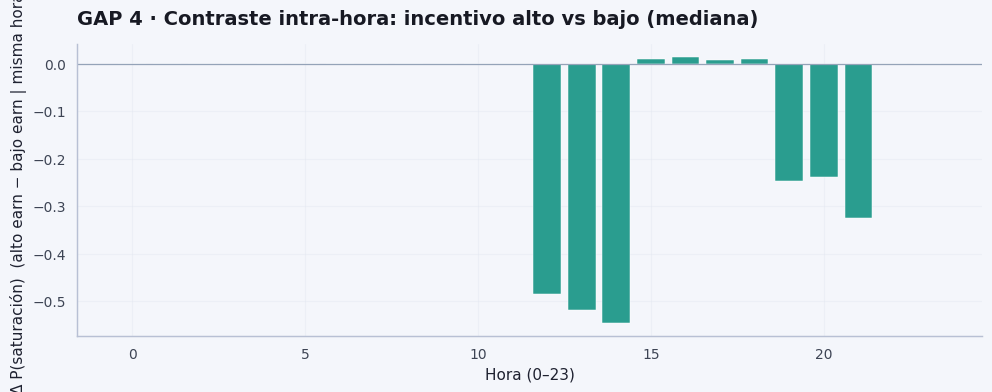


Lectura: si diff ≈ 0, alto y bajo earn en esa hora tienen estrés similar (menos compatible con «solo subieron incentivos porque ya había caos»). Si diff ≫ 0, revisar confusores (zona, lluvia) o mecánica de asignación de incentivos.


In [51]:
# --- GAP 4 — Contrafactuales: alto vs bajo earnings en la MISMA hora ---
# Idea: dentro de cada hora del día, comparar filas con incentivos (EARNINGS) altos vs bajos.
# Así se controla parcialmente el confusor "hora pico" (misma HOUR en ambos grupos).
# Requiere `clasificacion` (p. ej. saturacion) y columnas estándar del panel (`raw`, EARNINGS, ratio).

# Umbral mínimo de observaciones por hora: evita medianas y proporciones muy ruidosas.
# ~28 ≈ orden de 14 zonas × ~2 lecturas por celda hora×zona como referencia de escala.
_MIN_N = 28

# ---------- A) Tabla resumen por hora (split por mediana de EARNINGS dentro de la hora) ----------
_rows = []  # Una fila por hora válida (las que superan _MIN_N).
for _h in range(24):  # Recorre las 24 horas calendario (0 = medianoche, …).
    # Subconjunto: solo esa hora; sin NaN en ganancia ni en clasificación operativa.
    _sh = raw.loc[raw["HOUR"] == _h].dropna(subset=["EARNINGS", "clasificacion"])
    if len(_sh) < _MIN_N:  # Hora con pocas filas → se omite (no entra en el contraste).
        continue
    _med = _sh["EARNINGS"].median()  # Mediana de incentivos **dentro** de esa hora (no global).
    # "Alto earn": filas en o por encima de la mediana; "bajo earn": estrictamente debajo.
    _hi = _sh[_sh["EARNINGS"] >= _med]
    _lo = _sh[_sh["EARNINGS"] < _med]
    # Fracción de observaciones clasificadas como saturación en cada mitad (proporción, 0–1).
    _ps_hi = _hi["clasificacion"].eq("saturacion").mean()
    _ps_lo = _lo["clasificacion"].eq("saturacion").mean()
    # Media del ratio operativo en cada mitad (contexto de carga además de P(sat)).
    _ratio_hi = _hi["ratio"].mean()
    _ratio_lo = _lo["ratio"].mean()
    _rows.append(
        {
            "HOUR": _h,  # Etiqueta de hora.
            "n": len(_sh),  # Tamaño muestral usado en esa hora (antes del split).
            "P_sat_earn_ge_med": _ps_hi,  # P(saturación | alto earn, hora fija).
            "P_sat_earn_lt_med": _ps_lo,  # P(saturación | bajo earn, hora fija).
            "diff_P_sat": _ps_hi - _ps_lo,  # Contraste: positivo → más saturación cuando el earn es alto.
            "mean_ratio_ge_med": _ratio_hi,
            "mean_ratio_lt_med": _ratio_lo,
        }
    )

_gap4 = pd.DataFrame(_rows)  # Panel compacto: una fila por hora analizada.
print("GAP 4 · Misma hora: mediana de EARNINGS dentro de la hora; alto = ≥ mediana, bajo = < mediana")
print(_gap4.to_string(index=False, float_format=lambda x: "%.4f" % x))

# ---------- B) Destacar horas con contraste fuerte (umbral arbitrario 2 puntos porcentuales) ----------
# Positivo grande: en esa hora, más saturación entre quienes tienen earn alto (asociación; no implica causalidad).
_sus = _gap4[_gap4["diff_P_sat"] > 0.02].sort_values("diff_P_sat", ascending=False)
if len(_sus) > 0:
    print("\nHoras con diff P(sat) (alto − bajo) > 2 pp:")
    print(_sus[["HOUR", "diff_P_sat", "P_sat_earn_ge_med", "P_sat_earn_lt_med"]].to_string(index=False))

# ---------- C) Figura de barras: Δ P(sat) por hora ----------
# Paleta y backend: si no se corrió la celda base del notebook, se define aquí lo mínimo.
if "COLORS" not in globals():
    import matplotlib.pyplot as plt
    import numpy as np
    COLORS = {"accent": "#2a9d8f", "muted": "#94a3b8"}

fig, ax = plt.subplots(figsize=(10.2, 4.2), facecolor=plt.rcParams["figure.facecolor"])
ax.axhline(0, color=COLORS.get("muted", "#94a3b8"), linewidth=0.9)  # Referencia: sin diferencia entre mitades.
ax.bar(
    _gap4["HOUR"],  # Posición en eje X = hora del día.
    _gap4["diff_P_sat"],  # Altura = diferencia de probabilidades de saturación.
    color=COLORS.get("accent", "#2a9d8f"),
    edgecolor="white",
    linewidth=0.35,
)
ax.set_xlabel("Hora (0–23)")
ax.set_ylabel("Δ P(saturación)  (alto earn − bajo earn | misma hora)")
ax.set_title("GAP 4 · Contraste intra-hora: incentivo alto vs bajo (mediana)")
if "polish_axes" in globals():  # Estética compartida con otras figuras del módulo.
    polish_axes(ax)
fig.tight_layout()
save_fig(fig, FIG / "gap4_p4_counterfactual_misma_hora.png")  # Exporta PNG bajo modulo1_diagnostico/figures.
plt.show()

# ---------- D) Lectura para negocio ----------
print(
    "\nLectura: si diff ≈ 0, alto y bajo earn en esa hora tienen estrés similar "
    "(menos compatible con «solo subieron incentivos porque ya había caos»). "
    "Si diff ≫ 0, revisar confusores (zona, lluvia) o mecánica de asignación de incentivos."
)


### Falta **priorización operacional** (y escenarios para Operations)

> **Lectura sencilla:**
> Aunque todo esté bien estimado, falta **ordenar**: ¿a qué zona entrar primero? El “risk score” mezcla historial de crisis, sensibilidad a lluvia y volatilidad de pedidos en un **ranking** transparente, no en una fórmula mágica única.

El análisis puede ser correcto y aun así no responder: **¿en qué zona actuar primero?**

**Score de riesgo por zona** (heurístico, alimenta priorización tipo motor / tablero):

$$\text{risk\_score}_z \propto \underbrace{\Pr(\text{hist. saturación})_z}_{\text{frecuencia de crisis}} \times \underbrace{|\beta^{\text{lluvia}}_z|}_{\text{sensibilidad (P3)}} \times \underbrace{\text{CV}(\text{pedidos})_z}_{\text{variabilidad de demanda}}$$

Cada componente se **escala** entre zonas (min–max) para que sean comparables; el producto ordena **dónde** concentrar atención. No es óptimo teórico: es **ranking** transparente.

**BONUS — Vender mejor lo que ya tienes:** la **sensibilidad mm** (1,2→1,8) y **P6** encajan como **simulación de política operativa**: “si sube la lluvia o el incentivo, ¿qué pasa con el ratio?”

**Rejilla de escenarios (Operations):** fijando **hora** y **zona** de referencia, un MCO del `ratio` en función de `PRECIPITATION_MM` y `EARNINGS` (más controles categóricos) permite **predecir** el ratio en una malla `rain × earnings` — tabla tipo:

| Rain | Earnings | Ratio pred. |
|------|----------|---------------|
| 8 mm | 55 MXN   | … |
| 8 mm | 78 MXN   | … |

Los números concretos salen de la celda siguiente (dependen del ajuste y de la tupla hora–zona).

GAP 5 · Risk score por zona (mayor = priorizar antes; heurístico)

               ZONE  prob_sat_hist  sensitivity_rain  demand_cv_orders  risk_score_0_1
           Santiago         0.0625            0.1906            1.0947          1.0000
 Carretera Nacional         0.0597            0.1315            1.0842          0.4651
        San Nicolás         0.0625            0.0599            1.0193          0.0180
      MTY_Guadalupe         0.0611            0.0581            1.0190          0.0139
           Escobedo         0.0500            0.0633            1.0210          0.0134
MTY_Apodaca_Huinalá         0.0375            0.0859            1.0934          0.0134
      Independencia         0.0528            0.0737            1.0047          0.0108
     Apodaca Centro         0.0514            0.0657            1.0050          0.0068
          San Pedro         0.0403            0.0682            1.0075          0.0027
   Cumbres Poniente         0.0417            0.0520           

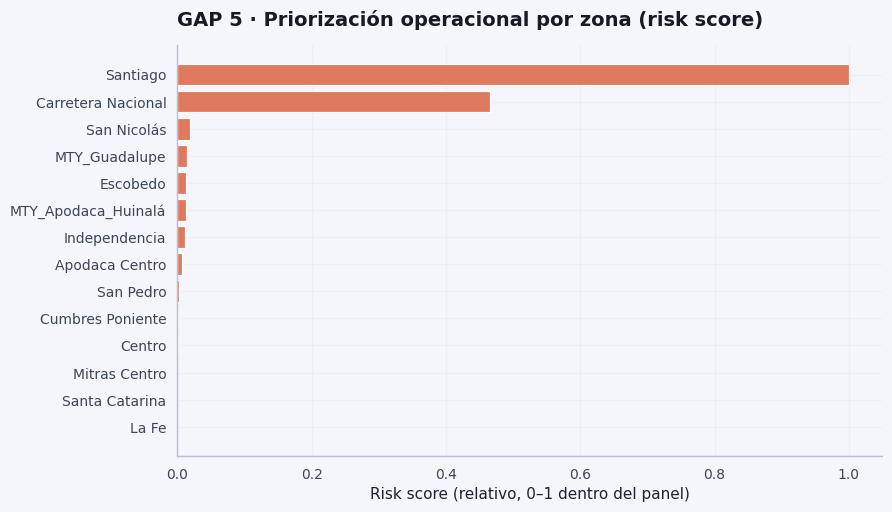


--- Simulación de política operativa · ratio predicho ---
MCO: ratio ~ PRECIPITATION_MM + EARNINGS + C(HOUR) + C(ZONE)
Referencia fija: HOUR=11  ZONE='Apodaca Centro'

 rain_mm_h  earnings_MXN  ratio_pred
         0            50       1.258
         0            70       0.723
         0            90       0.187
         5            50       1.786
         5            70       1.250
         5            90       0.715
        10            50       2.314
        10            70       1.778
        10            90       1.242
  8 mm/h · 55 MXN → ratio pred ≈ 1.97
  8 mm/h · 78 MXN → ratio pred ≈ 1.35

Nota: la rejilla es **contrafactual lineal** (extrapola fuera del rango observado con cautela). P6 / sensibilidad por zona aportan otra capa de ‘simulación’ bajo restricciones de presupuesto.


In [52]:
# --- GAP 5 — Risk score por zona + rejilla lluvia × earnings (ratio predicho) ---
# A) Construye un score heurístico por zona: histórico P(sat), sensibilidad del ratio a la lluvia (|β| MCO), CV de demanda.
# B) Tabla contrafactual: ratio predicho en rejilla (lluvia × earnings) con HOUR/ZONA de referencia.

# ---------- A) Risk score (componentes por zona) ----------
import pandas as pd

if "dow" not in raw.columns:
    raw = raw.copy()
    raw["dow"] = pd.to_datetime(raw["DATE"], errors="coerce").dt.dayofweek

_risk_rows = []
for _z in raw["ZONE"].unique():
    _sub = raw.loc[raw["ZONE"] == _z]
    _p_sat = _sub["clasificacion"].eq("saturacion").mean()  # Fracción histórica de filas saturadas en la zona.
    _sub_m = _sub.dropna(subset=["ratio", "PRECIPITATION_MM", "HOUR", "dow"])
    if len(_sub_m) < 48:  # Mínimo aproximado para MCO con muchas dummies de hora.
        continue
    _mz = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR) + C(dow)", data=_sub_m).fit()
    _sens = abs(float(_mz.params["PRECIPITATION_MM"]))  # Magnitud del efecto marginal de lluvia (valor absoluto).
    _mu_o = float(_sub["ORDERS"].mean())
    _cv = float(_sub["ORDERS"].std() / _mu_o) if _mu_o > 0 else 0.0  # Inestabilidad relativa de la demanda.
    _risk_rows.append(
        {"ZONE": _z, "prob_sat_hist": _p_sat, "sensitivity_rain": _sens, "demand_cv_orders": _cv}
    )

_risk = pd.DataFrame(_risk_rows)
# Normalización min–max por columna: cada señal en [0,1] antes de combinarlas.
for _c in ("prob_sat_hist", "sensitivity_rain", "demand_cv_orders"):
    _lo, _hi = _risk[_c].min(), _risk[_c].max()
    _risk[_c + "_norm"] = (_risk[_c] - _lo) / (_hi - _lo + 1e-12)

_risk["risk_score"] = (
    _risk["prob_sat_hist_norm"] * _risk["sensitivity_rain_norm"] * _risk["demand_cv_orders_norm"]
)
# Escala 0–1 respecto al máximo del producto (solo ranking relativo entre zonas del panel).
_rmax = float(_risk["risk_score"].max())
if _rmax > 0:
    _risk["risk_score_display"] = _risk["risk_score"] / _rmax
else:
    _risk["risk_score_display"] = _risk["risk_score"]

_risk = _risk.sort_values("risk_score_display", ascending=False)
print("GAP 5 · Risk score por zona (mayor = priorizar antes; heurístico)\n")
print(
    _risk[["ZONE", "prob_sat_hist", "sensitivity_rain", "demand_cv_orders", "risk_score_display"]]
    .rename(columns={"risk_score_display": "risk_score_0_1"})
    .to_string(index=False, float_format=lambda x: "%.4f" % x)
)

if "COLORS" not in globals():
    import matplotlib.pyplot as plt

    COLORS = {"bar": "#e76f51", "grid": "#dee2e6"}

fig, ax = plt.subplots(figsize=(9.2, 5.4), facecolor=plt.rcParams["figure.facecolor"])
_top = _risk.head(14).iloc[::-1]  # Barh: mayor arriba tras invertir orden.
ax.barh(_top["ZONE"], _top["risk_score_display"], color=COLORS.get("bar", "#e76f51"), edgecolor="white")
ax.set_xlabel("Risk score (relativo, 0–1 dentro del panel)")
ax.set_title("GAP 5 · Priorización operacional por zona (risk score)")
if "polish_axes" in globals():
    polish_axes(ax)
fig.tight_layout()
save_fig(fig, FIG / "gap5_risk_score_zonas.png")
plt.show()

# ---------- B) Simulación de escenarios: ratio predicho (MCO) ----------
_scen_fit = raw.dropna(subset=["ratio", "PRECIPITATION_MM", "EARNINGS"]).copy()
m_ratio_scen = smf.ols(
    "ratio ~ PRECIPITATION_MM + EARNINGS + C(HOUR) + C(ZONE)",
    data=_scen_fit,
).fit()

_REF_H = int(_scen_fit["HOUR"].median())
_REF_Z = str(_scen_fit["ZONE"].mode().iloc[0])

_grid_rows = []
for _rain in (0, 5, 10):
    for _earn in (50, 70, 90):
        _pred = m_ratio_scen.predict(
            pd.DataFrame(
                {
                    "PRECIPITATION_MM": [_rain],
                    "EARNINGS": [_earn],
                    "HOUR": [_REF_H],
                    "ZONE": [_REF_Z],
                }
            )
        )
        _grid_rows.append(
            {
                "rain_mm_h": _rain,
                "earnings_MXN": _earn,
                "ratio_pred": float(_pred.iloc[0]),
            }
        )

_grid = pd.DataFrame(_grid_rows)
print(
    "\n--- Simulación de política operativa · ratio predicho ---\n"
    "MCO: ratio ~ PRECIPITATION_MM + EARNINGS + C(HOUR) + C(ZONE)"
)
print("Referencia fija: HOUR=%d  ZONE=%r\n" % (_REF_H, _REF_Z))
print(_grid.to_string(index=False, float_format=lambda x: "%.3f" % x))

# Ejemplo tipo Operations (8 mm, 55 vs 78 MXN) — misma referencia HOUR/ZONE.
for _earn in (55, 78):
    _p8 = m_ratio_scen.predict(
        pd.DataFrame(
            {
                "PRECIPITATION_MM": [8.0],
                "EARNINGS": [_earn],
                "HOUR": [_REF_H],
                "ZONE": [_REF_Z],
            }
        )
    )
    print("  8 mm/h · %d MXN → ratio pred ≈ %.2f" % (_earn, float(_p8.iloc[0])))

print(
    "\nNota: la rejilla es **contrafactual lineal** (extrapola fuera del rango observado con cautela). "
    "P6 / sensibilidad por zona aportan otra capa de ‘simulación’ bajo restricciones de presupuesto."
)


### Sistema operacional de decisiones (motor de alertas)

> **Lectura sencilla:**
> Este bloque **ensambla** lo anterior: probabilidad de saturación, respuesta de oferta a incentivos y reglas con datos reales. Es el puente hacia el **motor de alertas** y mensajes accionables, sin sustituir el criterio humano.

Este bloque **no repite** el diagnóstico exploratorio (P1–P5, GAP 1–5): **lo convierte** en piezas listas para un **motor de alertas** y para explicar decisiones a negocio.

| Pieza | Rol |
|-------|-----|
| **Logit** | `P(ratio > 1.8)` con lluvia, earnings, hora y zona — base del riesgo de saturación. |
| **MCO oferta** | Cuántos **repartidores conectados** extra se asocian a **+1 MXN** de earnings (condicional a hora, zona y lluvia). |
| **Umbrales / rankings** | Deciles de lluvia, horas con mayor estrés y zonas vulnerables — **derivados del panel** (no números “inventados”). |
| **`decision_engine(row)`** | Une logit + elasticidad para **clasificar riesgo**, recomendar earnings hacia **ratio ≈ 1.2** y estimar el ratio después de la acción. |
| **Simulación** | Escenario **antes / después** (misma demanda observada, oferta según MCO). |

**Nota:** la oferta se modela como **lineal** en earnings; los modelos miden **asociaciones** en datos observados, no efectos causales demostrados.

#### Confianza y «¿qué pasa si el modelo se equivoca?»

Cada decisión lleva **Confidence: HIGH / MEDIUM / LOW** según cuántas **filas históricas similares** hay (misma zona, ventana de hora, lluvia en banda ± mm/h) y un **intervalo al 95%** sobre **P(saturación)** del logit (`get_prediction`). Si el IC es ancho o N es bajo, la recomendación de earnings sigue siendo **punto de partida**, no orden rígida.

#### Falsos positivos (llueve y «no pasa nada») — trade-off precisión vs anticipación

Regla explícita: **`alert()` solo si** `P(sat) > 0.7` **y** `PRECIPITATION_MM ≥ umbral_mm` (umbral = **primer decil de lluvia material** con riesgo relativo alto en el panel). Así se reduce el ruido: no alertamos solo por modelo nervioso con goteras. **Coste:** podemos llegar tarde si la lluvia es leve pero el sistema ya está al límite — por eso coexisten **riesgo por probabilidad** y **regla de alerta** más estricta.

#### Priorización entre zonas

Tabla **`risk_score = P̂_sat × sensibilidad_lluvia × demanda`** (cada factor normalizado min–max en el panel) y **Top 3 zonas** impreso en consola; útil para decidir **dónde mover presupuesto primero**.

**Mapeo al diseño operativo:** (1) logit saturación + interpretación OR · (2) elasticidad MXN→drivers · (3) deciles lluvia, horas pico, ranking zonas · (4) `decision_engine` · (5) `simulate_operational_scenario`. Detalle (Δearnings, ratio OLS) en `_meta` del dict de salida.

**Requisito de ejecución:** celda que carga `raw` y define `ratio` (y hojas `RAW_DATA` / `ZONE_INFO`). No hace falta re-ejecutar todo el notebook si ya tienes `raw` en memoria.


In [72]:
# --- Sistema operacional: modelos, umbrales data-driven, decision_engine, simulación ---
# Requiere: raw con ratio, ORDERS, CONNECTED_RT, PRECIPITATION_MM, EARNINGS, HOUR, ZONE
#
# Flujo: OPS_PANEL + is_saturated → LOGIT/OLS → deciles lluvia / horas pico → priorización zonas →
# decision_engine (predicción, IC95%, eventos similares, alerta) → simulación y tablas resumen.
#

import pandas as pd

if "dow" not in raw.columns:
    raw = raw.copy()
    raw["dow"] = pd.to_datetime(raw["DATE"], errors="coerce").dt.dayofweek

OPS_PANEL = raw.dropna(
    subset=["ratio", "ORDERS", "CONNECTED_RT", "PRECIPITATION_MM", "EARNINGS", "HOUR", "ZONE"]
).copy()
OPS_PANEL["is_saturated"] = (OPS_PANEL["ratio"] > 1.8).astype(int)

# --- 1) Modelos alineados al enunciado (mismo panel de entrenamiento) ---
OPS_LOGIT = smf.logit(
    "is_saturated ~ PRECIPITATION_MM + EARNINGS + C(HOUR) + C(ZONE)",
    data=OPS_PANEL,
).fit(disp=0)

OPS_SUPPLY = smf.ols(
    "CONNECTED_RT ~ EARNINGS + PRECIPITATION_MM + C(HOUR) + C(ZONE)",
    data=OPS_PANEL,
).fit()

OPS_RATIO = smf.ols(
    "ratio ~ PRECIPITATION_MM + EARNINGS + C(HOUR) + C(ZONE)",
    data=OPS_PANEL,
).fit()

# Compatibilidad con celdas anteriores (GAP 2 / GAP 3)
logit_sat = OPS_LOGIT
m_supply = OPS_SUPPLY

# Probabilidades en muestra → cortes de riesgo data-driven (no umbrales fijos arbitrarios)
_TRAIN_P = OPS_LOGIT.predict(OPS_PANEL)
RISK_CUT_MEDIUM = float(_TRAIN_P.quantile(0.75))
RISK_CUT_HIGH = float(_TRAIN_P.quantile(0.90))
RISK_CUT_CRITICAL = float(_TRAIN_P.quantile(0.95))


def risk_level_from_prob(p: float) -> str:
    if p <= RISK_CUT_MEDIUM:
        return "LOW"
    if p <= RISK_CUT_HIGH:
        return "MEDIUM"
    if p <= RISK_CUT_CRITICAL:
        return "HIGH"
    return "CRITICAL"


def interpret_logit_plain_english(model, name="P(saturación)"):
    """Odds ratios para variables continuas; hora/zona quedan como efectos fijos (muchas categorías)."""
    print("--- Interpretación logit (%s) — odds ratios (exp(coef)) ---" % name)
    params = model.params
    bse = model.bse
    pvals = model.pvalues
    for par in ("PRECIPITATION_MM", "EARNINGS"):
        if par not in params.index:
            continue
        oratio = float(np.exp(params[par]))
        lo = float(np.exp(params[par] - 1.96 * bse[par]))
        hi = float(np.exp(params[par] + 1.96 * bse[par]))
        sig = "***" if pvals[par] < 0.001 else ("**" if pvals[par] < 0.01 else ("*" if pvals[par] < 0.05 else ""))
        if par == "PRECIPITATION_MM":
            print(
                "  · Lluvia: cada +1 mm/h **multiplica las odds** de saturación por ~%.3f (IC95%% OR: %.3f–%.3f) %s"
                % (oratio, lo, hi, sig)
            )
        else:
            print(
                "  · Earnings: cada +1 MXN **multiplica las odds** por ~%.3f (IC95%%: %.3f–%.3f) %s  "
                "(si <1, más incentivo se asocia a **menor** odds de saturación, condicional al resto)."
                % (oratio, lo, hi, sig)
            )
    print(
        "  · HORA y ZONA: coeficientes por categoría (referencia: hora 0 y una zona base); "
        "ver `OPS_LOGIT.summary2()` para el desglose completo."
    )
    print(
        "\nCortes de **riesgo** usados (cuantiles de P_train en el panel): "
        "MEDIUM>%.4f  HIGH>%.4f  CRITICAL>%.4f"
        % (RISK_CUT_MEDIUM, RISK_CUT_HIGH, RISK_CUT_CRITICAL)
    )


interpret_logit_plain_english(OPS_LOGIT)

_beta_e = float(OPS_SUPPLY.params["EARNINGS"])
_ci = OPS_SUPPLY.conf_int().loc["EARNINGS"]
print("\n--- 2) Respuesta de oferta (MCO supply) ---")
print(
    "  β_EARNINGS = %.4f  (IC95%% [%.4f, %.4f])  |  p = %.4g"
    % (_beta_e, float(_ci[0]), float(_ci[1]), float(OPS_SUPPLY.pvalues["EARNINGS"]))
)
print(
    "  **Regla operativa:** +1 MXN de earnings → ~**%+.3f** repartidores conectados de más "
    "(mismo hora/zona/lluvia en promedio)."
    % _beta_e
)

# --- 3) Umbrales de lluvia, horas pico, zonas (datos observados + deciles) ---

def rain_decile_table(df: pd.DataFrame) -> pd.DataFrame:
    dfc = df.copy()
    dfc["_rk"] = dfc["PRECIPITATION_MM"].rank(method="first")
    dfc["dec_prec"] = pd.qcut(dfc["_rk"], 10, duplicates="drop")
    g = (
        dfc.groupby("dec_prec", observed=True)
        .agg(
            mm_median=("PRECIPITATION_MM", "median"),
            mm_max=("PRECIPITATION_MM", "max"),
            p_sat=("is_saturated", "mean"),
            n=("is_saturated", "size"),
        )
        .reset_index(drop=True)
    )
    base = float(g["p_sat"].iloc[0])
    g["rel_risk_vs_D1"] = g["p_sat"] / (base + 1e-12)
    return g


RAIN_GLOBAL = rain_decile_table(OPS_PANEL)
print("\n--- 3a) Lluvia global — deciles vs P(saturación observada) ---")
print(RAIN_GLOBAL.to_string(index=False, float_format=lambda x: "%.4f" % x))
_sig_lift = RAIN_GLOBAL[(RAIN_GLOBAL["rel_risk_vs_D1"] >= 1.5) & (RAIN_GLOBAL["mm_median"] > 0.05)]
if len(_sig_lift):
    print(
        "\n  Deciles con **riesgo relativo ≥ 1.5×** y lluvia material (mediana mm/h > 0.05): "
        "desde ~%.2f mm/h (mediana de decil)."
        % (float(_sig_lift["mm_median"].min()))
    )

# Por zona: lift Q3 vs Q1 de lluvia dentro de la zona
_zone_rows = []
for _z, sub in OPS_PANEL.groupby("ZONE"):
    if len(sub) < 80:
        continue
    q1, q3 = sub["PRECIPITATION_MM"].quantile(0.25), sub["PRECIPITATION_MM"].quantile(0.75)
    low = sub[sub["PRECIPITATION_MM"] <= q1]
    high = sub[sub["PRECIPITATION_MM"] >= q3]
    pl, ph = low["is_saturated"].mean(), high["is_saturated"].mean()
    _zone_rows.append(
        {
            "ZONE": _z,
            "p_sat_Q1_lowrain": pl,
            "p_sat_Q3_highrain": ph,
            "lift": ph - pl,
            "q1_mm": q1,
            "q3_mm": q3,
        }
    )
ZONE_RAIN = pd.DataFrame(_zone_rows).sort_values("lift", ascending=False)
print("\n--- 3b) Zonas — diferencia P(sat) entre lluvia alta (≥Q3) vs baja (≤Q1) **dentro de la zona** ---")
print(ZONE_RAIN.to_string(index=False, float_format=lambda x: "%.4f" % x))
if ZONE_RAIN["q3_mm"].max() < 1e-6:
    print(
        "\n  Nota: Q1/Q3 de lluvia ≈ 0 en varias zonas (mucha masa en seco); el ranking por **lift** sigue siendo útil; "
        "cruce con deciles **globales** (3a) para mm/h altos."
    )

HOUR_STRESS = (
    OPS_PANEL.groupby("HOUR", as_index=False)
    .agg(p_sat=("is_saturated", "mean"), n=("is_saturated", "size"))
    .sort_values("p_sat", ascending=False)
)
print("\n--- 3c) Horas — mayor fracción empírica de saturación (ordenadas) ---")
print(HOUR_STRESS.head(8).to_string(index=False, float_format=lambda x: "%.4f" % x))
PEAK_HOURS_TOP = HOUR_STRESS.head(3)["HOUR"].tolist()

# --- 3d) Priorización entre zonas (negocio: ¿dónde actuar primero?) ---


def build_zone_priority_score(ops_panel, logit_model):
    rows = []
    for z, sub in ops_panel.groupby("ZONE"):
        if len(sub) < 48:
            continue
        p_avg = float(logit_model.predict(sub).mean())
        sub_m = sub.dropna(subset=["ratio", "PRECIPITATION_MM", "HOUR", "dow"])
        if len(sub_m) < 48:
            sens = 0.0
        else:
            try:
                mz = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR) + C(dow)", data=sub_m).fit()
                sens = abs(float(mz.params.get("PRECIPITATION_MM", 0.0)))
            except Exception:
                sens = 0.0
        dem = float(sub["ORDERS"].mean())
        rows.append(
            {
                "ZONE": z,
                "prob_saturation": p_avg,
                "sensitivity_rain": sens,
                "demand_orders": dem,
            }
        )
    df = pd.DataFrame(rows)
    for c in ("prob_saturation", "sensitivity_rain", "demand_orders"):
        lo, hi = df[c].min(), df[c].max()
        df[c + "_n"] = (df[c] - lo) / (hi - lo + 1e-12)
    df["risk_score"] = df["prob_saturation_n"] * df["sensitivity_rain_n"] * df["demand_orders_n"]
    return df.sort_values("risk_score", ascending=False)


ZONE_PRIORITY = build_zone_priority_score(OPS_PANEL, OPS_LOGIT)
print("\n--- 3d) Priorización — risk_score = P̂_sat×sensibilidad_lluvia×demanda (min-max por columna en el panel) ---")
_cols_show = ["ZONE", "risk_score", "prob_saturation", "sensitivity_rain", "demand_orders"]
print(ZONE_PRIORITY[_cols_show].to_string(index=False, float_format=lambda x: "%.4f" % x))
print("\n**Top 3 zonas críticas (mayor risk_score):**")
for _rank, (_, _r) in enumerate(ZONE_PRIORITY.head(3).iterrows(), start=1):
    print("  %d. %s   (risk_score=%.4f)" % (_rank, _r["ZONE"], _r["risk_score"]))

# --- Alertas: trade-off precisión vs anticipación (falsos positivos tipo «llueve y no pasa nada») ---
ALERT_PROB_THRESHOLD = 0.7
_row_alert = RAIN_GLOBAL[(RAIN_GLOBAL["mm_median"] > 0.05) & (RAIN_GLOBAL["rel_risk_vs_D1"] >= 1.5)]
RAIN_ALERT_THRESHOLD_MM = (
    float(_row_alert["mm_median"].min()) if len(_row_alert) else float(RAIN_GLOBAL["mm_median"].iloc[-1])
)


def operational_alert(prob_sat: float, precip_mm: float) -> bool:
    """Solo alertar si hay probabilidad alta Y lluvia material (umbral mm/h del panel)."""
    return (prob_sat > ALERT_PROB_THRESHOLD) and (precip_mm >= RAIN_ALERT_THRESHOLD_MM)


print(
    "\n--- Regla de alerta (reduce ruido) ---\n"
    "  if P(sat) > %.1f and PRECIPITATION_MM >= %.2f mm/h  →  alert()  # ambos datos del caso/panel\n"
    % (ALERT_PROB_THRESHOLD, RAIN_ALERT_THRESHOLD_MM)
)

# --- Confianza: eventos históricos similares + IC95% del logit (statsmodels) ---
# Ventana: misma zona, hora ±2 h, precip ±8 mm/h (suficiente soporte en 30 días sin inflar artificialmente)
SIMILAR_MM_TOL_CONF = 8.0
SIMILAR_HOUR_PAD = 2


def count_similar_historical(zone_s: str, hour: int, precip_mm: float) -> int:
    m = OPS_PANEL
    h_lo, h_hi = max(0, int(hour) - SIMILAR_HOUR_PAD), min(23, int(hour) + SIMILAR_HOUR_PAD)
    hrs = list(range(h_lo, h_hi + 1))
    return int(
        (
            (m["ZONE"].astype(str) == str(zone_s))
            & (m["HOUR"].isin(hrs))
            & (m["PRECIPITATION_MM"] >= precip_mm - SIMILAR_MM_TOL_CONF)
            & (m["PRECIPITATION_MM"] <= precip_mm + SIMILAR_MM_TOL_CONF)
        ).sum()
    )


def confidence_label(n_similar: int) -> str:
    if n_similar >= 80:
        return "HIGH"
    if n_similar >= 25:
        return "MEDIUM"
    return "LOW"


# --- 4) decision_engine ---


def decision_engine(row, target_ratio: float = 1.2):
    """
    Entrada (dict o Series) con claves:
      PRECIPITATION_MM, EARNINGS, HOUR, ZONE
      y capacidad/demanda vía (ORDERS + CONNECTED_RT) **o** (ratio + CONNECTED_RT).

    Incluye: confianza por N histórico similar, IC95% de P(sat), y si dispararía alerta operativa.
    """
    if isinstance(row, pd.Series):
        r = row.to_dict()
    else:
        r = dict(row)

    def _g(k):
        for a in (k, k.upper(), k.lower()):
            if a in r:
                return r[a]
        raise KeyError("Falta clave obligatoria: %s" % k)

    pm = float(_g("PRECIPITATION_MM"))
    e0 = float(_g("EARNINGS"))
    h = int(_g("HOUR"))
    z = _g("ZONE")
    if isinstance(z, (float, int)):
        z = str(int(z)) if float(z).is_integer() else str(z)
    else:
        z = str(z).strip()

    cr = float(_g("CONNECTED_RT"))
    if "ORDERS" in r or "orders" in r:
        o = float(r.get("ORDERS", r.get("orders")))
    elif "ratio" in r or "RATIO" in r:
        rho = float(r.get("ratio", r.get("RATIO")))
        o = rho * cr
    else:
        raise KeyError("Indica ORDERS o ratio junto con CONNECTED_RT")

    X = pd.DataFrame(
        {"PRECIPITATION_MM": [pm], "EARNINGS": [e0], "HOUR": [h], "ZONE": [z]}
    )
    p_sat = float(OPS_LOGIT.predict(X).iloc[0])
    rl = risk_level_from_prob(p_sat)

    try:
        sf = OPS_LOGIT.get_prediction(X).summary_frame(alpha=0.05)
        p_lo = float(np.clip(sf["ci_lower"].iloc[0], 0.0, 1.0))
        p_hi = float(np.clip(sf["ci_upper"].iloc[0], 0.0, 1.0))
    except Exception:
        p_lo, p_hi = p_sat, p_sat

    n_sim = count_similar_historical(z, h, pm)
    conf = confidence_label(n_sim)
    conf_detail = (
        "based on %d similar historical events (same zone, hour ±%d h, precip ±%.1f mm/h)"
        % (n_sim, SIMILAR_HOUR_PAD, SIMILAR_MM_TOL_CONF)
    )
    alert_fire = operational_alert(p_sat, pm)

    beta = float(OPS_SUPPLY.params["EARNINGS"])
    if abs(beta) < 1e-8:
        d_e = float("nan")
        e1 = e0
    else:
        rt_star = o / float(target_ratio)
        d_rt = rt_star - cr
        d_e = d_rt / beta
        e1 = e0 + d_e

    rt1 = cr + beta * (e1 - e0)
    ratio_after = o / rt1 if rt1 > 1e-9 else float("nan")
    ratio_pred_line = float(OPS_RATIO.predict(X).iloc[0])

    return {
        "risk_level": rl,
        "probability_saturation": p_sat,
        "recommended_earnings": float(e1),
        "expected_ratio_after_action": float(ratio_after),
        "confidence": conf,
        "confidence_detail": conf_detail,
        "similar_event_count": int(n_sim),
        "probability_saturation_ci95": (p_lo, p_hi),
        "alert_fired": alert_fire,
        "alert_rule": "P(sat)>%.1f AND precip>=%.2f mm/h" % (ALERT_PROB_THRESHOLD, RAIN_ALERT_THRESHOLD_MM),
        "_meta": {
            "delta_earnings_mxn": float(d_e),
            "drivers_per_mxn": beta,
            "predicted_ratio_ols_same_row": ratio_pred_line,
            "peak_hours_data_top3": PEAK_HOURS_TOP,
            "zone_priority_top3": ZONE_PRIORITY.head(3)["ZONE"].tolist(),
        },
    }


# --- 5) Simulación tipo negocio ---


def simulate_operational_scenario(
    rain_mm: float,
    earnings: float,
    hour: int,
    zone: str,
    orders: float,
    connected_rt: float,
    target_ratio: float = 1.2,
    earnings_override=None,
):
    row = {
        "PRECIPITATION_MM": rain_mm,
        "EARNINGS": earnings,
        "HOUR": int(hour),
        "ZONE": str(zone).strip(),
        "ORDERS": float(orders),
        "CONNECTED_RT": float(connected_rt),
    }
    before = decision_engine(row, target_ratio=target_ratio)
    r0 = orders / connected_rt
    e_rec = before["recommended_earnings"]
    e_after = float(earnings_override) if earnings_override is not None else e_rec
    beta = before["_meta"]["drivers_per_mxn"]
    rt_new = connected_rt + beta * (e_after - earnings)
    r_after = orders / rt_new if rt_new > 1e-9 else float("nan")
    X_after = pd.DataFrame(
        {
            "PRECIPITATION_MM": [rain_mm],
            "EARNINGS": [e_after],
            "HOUR": [int(hour)],
            "ZONE": [str(zone).strip()],
        }
    )
    p_after = float(OPS_LOGIT.predict(X_after).iloc[0])
    alert_after = operational_alert(p_after, rain_mm)
    _lo, _hi = before["probability_saturation_ci95"]

    lines = [
        "",
        "========== SIMULACIÓN OPERACIONAL ==========",
        "Lluvia: %.2f mm/h  |  Zona: %s  |  Hora: %d" % (rain_mm, zone, hour),
        "Pedidos (fijos): %.2f  |  RT conectados (inicial): %.2f  |  Earnings iniciales: %.2f MXN"
        % (orders, connected_rt, earnings),
        "",
        "— ANTES —",
        "  ratio observado / escenario:     %.3f" % r0,
        "  P(saturación) [logit]:          %.2f %%   (IC95%%: %.2f–%.2f %%)"
        % (100 * before["probability_saturation"], 100 * _lo, 100 * _hi),
        "  Confidence: %s  (%s)" % (before["confidence"], before["confidence_detail"]),
        "  Alerta operativa:               %s  (%s)" % (before["alert_fired"], before["alert_rule"]),
        "  Nivel de riesgo (vs panel):      %s" % before["risk_level"],
        "  ratio predicho [MCO ratio~X]:   %.3f" % before["_meta"]["predicted_ratio_ols_same_row"],
        "",
        "— DESPUÉS (earnings → %.2f MXN%s) —"
        % (
            e_after,
            " [recomendado por motor]" if earnings_override is None else " [override manual]",
        ),
        "  RT implícito (oferta lineal):   %.3f" % rt_new,
        "  ratio estimado (O/RT):          %.3f  (objetivo motor ≈ %.2f)" % (r_after, target_ratio),
        "  P(saturación) [logit]:          %.2f %%" % (100 * p_after),
        "  Alerta operativa (post):        %s" % alert_after,
        "============================================",
    ]
    print("\n".join(lines))
    return {
        "before": before,
        "earnings_after": e_after,
        "ratio_after": r_after,
        "prob_sat_after": p_after,
        "connected_rt_implied": rt_new,
    }


# Ejemplo reproducible (ajusta zona/hora a tu panel)
_sat = OPS_PANEL[OPS_PANEL["is_saturated"] == 1]
_EX = _sat.iloc[len(_sat) // 2] if len(_sat) else OPS_PANEL.sort_values("ratio", ascending=False).iloc[0]
_Z = str(_EX["ZONE"])
_H = int(_EX["HOUR"])
_O = float(_EX["ORDERS"])
_RT = float(_EX["CONNECTED_RT"])
_E = float(_EX["EARNINGS"])

print("\n--- Ejemplo automático (fila del panel con ratio alto) ---")
simulate_operational_scenario(
    rain_mm=8.0,
    earnings=_E,
    hour=_H,
    zone=_Z,
    orders=_O,
    connected_rt=_RT,
    target_ratio=1.2,
)

# Ejemplo tipo enunciado: zona con "Centro", fila con tensión (saturada o ratio alto)
try:
    _centro = OPS_PANEL[OPS_PANEL["ZONE"].astype(str).str.contains("Centro", case=False, na=False)]
    _z0 = str(_centro.iloc[0]["ZONE"])
    _cen_hi = _centro[_centro["is_saturated"] == 1]
    if len(_cen_hi) == 0:
        _cen_hi = _centro.sort_values("ratio", ascending=False)
    _row_c = _cen_hi.iloc[len(_cen_hi) // 2]
    _h0 = int(_row_c["HOUR"])
    print("\n--- Ejemplo estilo caso (8 mm/h, earnings 55 → subir hasta recomendación) ---")
    simulate_operational_scenario(
        rain_mm=8.0,
        earnings=55.0,
        hour=_h0,
        zone=_z0,
        orders=float(_row_c["ORDERS"]),
        connected_rt=float(_row_c["CONNECTED_RT"]),
        target_ratio=1.2,
    )
except Exception as _ex:
    print("Ejemplo 'Centro' omitido:", _ex)

print(
    "\n**Por qué esta decisión:** el logit traduce lluvia/earnings/hora/zona en **probabilidad** de saturación; "
    "el MCO de oferta traduce **cuánto subir earnings** para ganar repartidores y acercar **O/RT** al objetivo; "
    "los niveles LOW/MEDIUM/HIGH/CRITICAL comparan tu P(sat) con la **distribución de P(sat) en el histórico**. "
    "**Confianza** combina N de tuplas similares + IC del modelo; **alert()** exige prob alta **y** lluvia material para no disparar en «ruido»."
)


--- Interpretación logit (P(saturación)) — odds ratios (exp(coef)) ---
  · Lluvia: cada +1 mm/h **multiplica las odds** de saturación por ~2.851 (IC95% OR: 2.374–3.423) ***
  · Earnings: cada +1 MXN **multiplica las odds** por ~0.652 (IC95%: 0.619–0.687) ***  (si <1, más incentivo se asocia a **menor** odds de saturación, condicional al resto).
  · HORA y ZONA: coeficientes por categoría (referencia: hora 0 y una zona base); ver `OPS_LOGIT.summary2()` para el desglose completo.

Cortes de **riesgo** usados (cuantiles de P_train en el panel): MEDIUM>0.0004  HIGH>0.1129  CRITICAL>0.4483

--- 2) Respuesta de oferta (MCO supply) ---
  β_EARNINGS = 0.3401  (IC95% [0.3333, 0.3469])  |  p = 0
  **Regla operativa:** +1 MXN de earnings → ~**+0.340** repartidores conectados de más (mismo hora/zona/lluvia en promedio).

--- 3a) Lluvia global — deciles vs P(saturación observada) ---
 mm_median  mm_max  p_sat    n  rel_risk_vs_D1
    0.0000  0.0000 0.0298 1008          1.0000
    0.0000  0.0000 0.0

### Key insight — executive takeaway (EN)

> **Lectura sencilla:**
> **Resumen en español:** la lluvia empuja el riesgo de saturación sobre todo en ciertas franjas del día; las zonas no son iguales. El sistema propone alertas cuando hay **probabilidad alta y lluvia seria**, sugiere **movimientos de tarifa** hacia un ratio objetivo y **prioriza** dónde actuar.

**Key insight:** Precipitation is associated with a sharp rise in saturation risk (odds scale in the logit), especially in **late lunch and evening hours** where empirical saturation rates peak; zones differ in **rain sensitivity × demand**, so impact is not uniform across the city.

Using **logistic saturation** plus **linear supply response to earnings**, this notebook implements a **decision layer** that: (1) outputs **P(saturation)** with **95% uncertainty** and **data-driven confidence** from similar historical conditions, (2) fires **alerts** only when **high probability meets material rain** (fewer false positives), (3) recommends **earnings moves** to steer toward a **target ratio (~1.2)**, and (4) ranks **where to act first** via a **zone risk_score**.

**Bottom line:** it turns **weather + marketplace state** into **actionable operations decisions** with explicit **risk / confidence / trade-offs**, not only charts.


### P5 — Relación earnings–saturación con interacción (lluvia)

> **Lectura sencilla:**
> P5 pregunta si la relación **tarifa ↔ carga** cambia cuando **llueve**: la interacción mide si el incentivo “pega distinto” con calzado mojado. Pearson y Spearman responden a cosas distintas (línea recta vs orden); aquí se usa el modelo con interacción para negocio.

**Nota:** **Pearson** (P2) y **Spearman** responden a preguntas distintas: Pearson mide relación **lineal**; Spearman, **monótona** (rangos), más cercana a enfoques **robustos** cuando hay asimetrías o colas pesadas (`Teoria/Machine Learning/tema2.pdf`). Aquí se comparan earnings vs ratio **global** y con **precipitación > 0**.

El modelo **OLS** con término **EARNINGS × PRECIPITATION_MM** (más `C(HOUR)` y `C(ZONE)`) es un **modelo lineal con interacción** (`tema5.pdf`): la pendiente de `ratio` respecto a `EARNINGS` puede **depender** del nivel de lluvia. Si el término de interacción es relevante estadísticamente, la relación incentivo–carga relativa **cambia bajo lluvia**; los coeficientes deben interpretarse en **escala original** (earnings y mm/h).

In [73]:
# --- P5 · Interacción earnings × lluvia sobre el ratio (controles HOUR, ZONE) ---
# Correlación de rangos (Spearman) mide asociación monótona sin suponer linealidad.
# El MCO con término EARNINGS:PRECIPITATION_MM permite que la pendiente de earnings dependa de la lluvia.
from scipy.stats import spearmanr

if "smf" not in globals():
    import statsmodels.formula.api as smf

print("Spearman earnings vs ratio (global):", spearmanr(raw["EARNINGS"], raw["ratio"]))
mask = raw["PRECIPITATION_MM"] > 0  # Submuestra horas con lluvia estrictamente positiva.
print("Con precip>0:", spearmanr(raw.loc[mask, "EARNINGS"], raw.loc[mask, "ratio"]))

m5 = smf.ols("ratio ~ EARNINGS * PRECIPITATION_MM + C(HOUR) + C(ZONE)", data=raw).fit()
print("Coef. EARNINGS:", m5.params["EARNINGS"], "p:", m5.pvalues["EARNINGS"])
print("Interacción EARNINGS:precip:", m5.params["EARNINGS:PRECIPITATION_MM"], "p:", m5.pvalues["EARNINGS:PRECIPITATION_MM"])
ci_i = m5.conf_int().loc["EARNINGS:PRECIPITATION_MM"]
print(f"IC95% interacción: [{ci_i[0]:.8f}, {ci_i[1]:.8f}]")
print(f"R² modelo P5: {m5.rsquared:.4f}")
print(
    "\n--- Lectura P5 (cumplimiento: ¿depende earnings–ratio de otras condiciones?) ---\n"
    "El término EARNINGS:PRECIPITATION_MM permite que el efecto marginal de los earnings sobre el ratio "
    "cambie con la lluvia (interacción). Si el coeficiente de interacción es significativo, la relación "
    "earnings–estrés (vía ratio) NO es la misma en seco que con precipitación; conviene cruzar con P2/P3 y GAP4."
)
_ix = m5.params.get("EARNINGS:PRECIPITATION_MM", float("nan"))
_pix = m5.pvalues.get("EARNINGS:PRECIPITATION_MM", float("nan"))
print(f"  Coef. interacción earnings×lluvia: {_ix:.6f}  p-valor: {_pix:.4g}")


Spearman earnings vs ratio (global): SignificanceResult(statistic=np.float64(0.07613533003613025), pvalue=np.float64(1.9468694077848612e-14))
Con precip>0: SignificanceResult(statistic=np.float64(-0.2509179807834915), pvalue=np.float64(2.6791141022556686e-10))
Coef. EARNINGS: -0.024943005163521048 p: 0.0
Interacción EARNINGS:precip: -0.0018947792121322992 p: 1.1494299788242046e-56
IC95% interacción: [-0.00212745, -0.00166211]
R² modelo P5: 0.8382

--- Lectura P5 (cumplimiento: ¿depende earnings–ratio de otras condiciones?) ---
El término EARNINGS:PRECIPITATION_MM permite que el efecto marginal de los earnings sobre el ratio cambie con la lluvia (interacción). Si el coeficiente de interacción es significativo, la relación earnings–estrés (vía ratio) NO es la misma en seco que con precipitación; conviene cruzar con P2/P3 y GAP4.
  Coef. interacción earnings×lluvia: -0.001895  p-valor: 1.149e-56


### Calendario — `ratio` vs día de la semana y festivos (México, marzo 2024)

> **Lectura sencilla:**
> Se mira si **el día de la semana** o un **festivo** cambian el ratio. Los tests no paramétricos comparan distribuciones sin asumir campanas perfectas; una correlación débil no quita efectos finos por hora o zona.

**Contexto:** El panel cubre **2024-03-01 … 2024-03-30** (Monterrey). Se construye `día de la semana` desde `DATE` y un indicador **`es_festivo`** con fechas **oficiales o mayoritarias** en México para ese mes (editables en código): *Natalicio de Benito Juárez* (tercer lunes de marzo), **Semana Santa** (Jueves/Viernes Santo, Domingo de Pascua). Para decisiones legales/laborales conviene cruzar con el [calendario de la SEP/DOF](https://www.gob.mx/).

**Qué miramos:** (1) **Kruskal–Wallis** sobre `ratio` entre los 7 días (no paramétrico; no asume normalidad). (2) **Mann–Whitney** `ratio` en días festivos vs no festivos. (3) **Spearman** entre `ratio` y el índice 0–6 del día (solo **exploratorio** — el día no es escala continua real). (4) Gráficos: boxplots por día y festivo/no festivo.

**Interpretación:** correlación **débil o nula** no implica ausencia de efectos por hora×zona; el calendario actúa aquí como **variable agregada** a nivel fila del panel.

Kruskal–Wallis (ratio vs día de la semana): estadístico=6.2597  p-value=0.394731
Mann–Whitney (festivo vs no festivo): estadístico=4844542.0000  p-value=0.001850  (n_fest=1008, n_no=9072)
Spearman (ratio vs índice día 0=Lun…6=Dom): rho=-0.0213  p-value=0.032335

Media de ratio por día de la semana:
dow_nom
Lun    0.8277
Mar    0.8440
Mié    0.8023
Jue    0.8515
Vie    0.8273
Sáb    0.7917
Dom    0.7852

Media ratio festivo=0.9013  |  no festivo=0.8087


/tmp/ipykernel_11530/252438475.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_11530/252438475.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_11530/252438475.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["No festivo", "Festivo"])


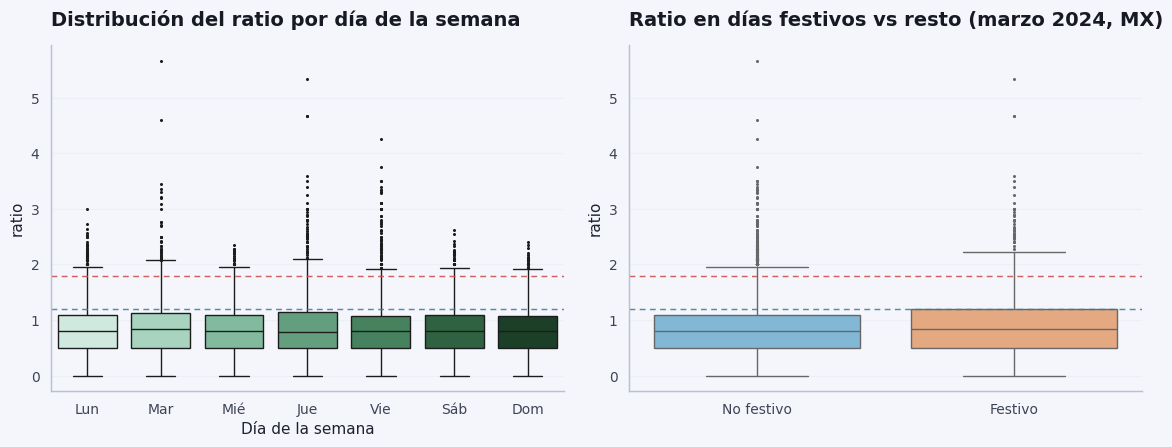

In [82]:
# --- Calendario: día de la semana y festivos MX (marzo 2024) ---
# Construye variables dow y es_festivo; contrastes no paramétricos (Kruskal, Mann–Whitney) y boxplots ratio.
from scipy.stats import kruskal, mannwhitneyu, spearmanr

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if "COLORS" not in globals():
    COLORS = {"ref_ok": "#3d7a96", "ref_sat": "#c94c4c"}

_cal = raw.copy()
_cal["DATE"] = pd.to_datetime(_cal["DATE"])
_d = _cal["DATE"].dt.normalize()
# Festivos editables (México, marzo 2024 — verificar en calendario oficial si se amplía el análisis).
_festivos = pd.to_datetime(
    [
        "2024-03-18",  # Natalicio de Benito Juárez (3.er lunes de marzo)
        "2024-03-28",  # Jueves Santo (Semana Santa)
        "2024-03-29",  # Viernes Santo
        "2024-03-31",  # Domingo de Pascua
    ]
).normalize()
_cal["dow"] = _cal["DATE"].dt.dayofweek  # 0=Lunes … 6=Domingo
_cal["es_festivo"] = _d.isin(_festivos)
_dow_names = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
_cal["dow_nom"] = _cal["dow"].map(dict(enumerate(_dow_names)))

# Kruskal–Wallis: ¿el ratio (continuo) difiere entre los 7 días? (no supone normalidad).
_grupos = [_cal.loc[_cal["dow"] == d, "ratio"].dropna().values for d in range(7)]
_grupos = [g for g in _grupos if len(g) > 0]
_kw = kruskal(*_grupos)
print("Kruskal–Wallis (ratio vs día de la semana): estadístico=%.4f  p-value=%.6f" % (_kw.statistic, _kw.pvalue))

# Mann–Whitney: comparación de dos grupos independientes (festivo vs no festivo).
_a = _cal.loc[_cal["es_festivo"], "ratio"].dropna()
_b = _cal.loc[~_cal["es_festivo"], "ratio"].dropna()
if len(_a) > 5 and len(_b) > 5:
    _mw = mannwhitneyu(_a, _b, alternative="two-sided")
    print(
        "Mann–Whitney (festivo vs no festivo): estadístico=%.4f  p-value=%.6f  (n_fest=%d, n_no=%d)"
        % (_mw.statistic, _mw.pvalue, len(_a), len(_b))
    )
else:
    print("Mann–Whitney: grupos demasiado pequeños para comparar.")

# Spearman ordinal dow vs ratio (tendencia monótona a lo largo de la semana).
_sp, _spp = spearmanr(_cal["ratio"], _cal["dow"], nan_policy="omit")
print("Spearman (ratio vs índice día 0=Lun…6=Dom): rho=%.4f  p-value=%.6f" % (_sp, _spp))

print("\nMedia de ratio por día de la semana:")
print(_cal.groupby("dow_nom", sort=False)["ratio"].mean().reindex(_dow_names).round(4).to_string())
print(
    "\nMedia ratio festivo=%s  |  no festivo=%s"
    % (
        round(float(_a.mean()), 4) if len(_a) else "NA",
        round(float(_b.mean()), 4) if len(_b) else "NA",
    )
)

# ---------- Figuras: ratio por día de la semana y festivo vs no festivo ----------
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.75), facecolor=plt.rcParams["figure.facecolor"])
order_cat = [x for x in _dow_names if x in _cal["dow_nom"].unique()]
_pal_dow = sns.cubehelix_palette(len(order_cat), start=2.0, rot=0.08, dark=0.2, light=0.88)
sns.boxplot(
    data=_cal,
    x="dow_nom",
    y="ratio",
    order=order_cat,
    ax=axes[0],
    palette=_pal_dow,
    fliersize=1.2,
    linewidth=1.0,
    saturation=0.9,
)
axes[0].set_xlabel("Día de la semana")
axes[0].set_ylabel("ratio")
axes[0].set_title("Distribución del ratio por día de la semana")
axes[0].axhline(1.2, color=COLORS["ref_ok"], linestyle=(0, (4, 3)), linewidth=1.05, alpha=0.85)
axes[0].axhline(1.8, color=COLORS["ref_sat"], linestyle=(0, (4, 3)), linewidth=1.05, alpha=0.88)

sns.boxplot(
    data=_cal,
    x="es_festivo",
    y="ratio",
    ax=axes[1],
    palette=["#7eb8da", "#e8a87c"],
    fliersize=1.2,
    linewidth=1.0,
    saturation=0.92,
)
axes[1].set_xticklabels(["No festivo", "Festivo"])
axes[1].set_xlabel("")
axes[1].set_ylabel("ratio")
axes[1].set_title("Ratio en días festivos vs resto (marzo 2024, MX)")
axes[1].axhline(1.2, color=COLORS["ref_ok"], linestyle=(0, (4, 3)), linewidth=1.05, alpha=0.85)
axes[1].axhline(1.8, color=COLORS["ref_sat"], linestyle=(0, (4, 3)), linewidth=1.05, alpha=0.88)
if "polish_axes" in globals():
    polish_axes(axes[0])
    polish_axes(axes[1])
fig.tight_layout()
save_fig(fig, FIG / "calendario_ratio_dow_festivos.png")
plt.show()


### Impacto de factores exógenos en el ratio operativo

El **ratio** (pedidos por repartidor conectado) resume el **balance oferta–demanda** en cada hora y zona. Cuando sube, hay más presión sobre la capacidad disponible; por encima del umbral operativo del caso (> 1.8) hablamos de **saturación**. Las variables ambientales —en primer lugar la **precipitación**— son **exógenas**: la operación no las controla, pero pueden **empujar** la demanda o complicar el servicio. Este bloque no es un informe meteorológico; sirve para situar **qué factores externos se mueven junto al ratio** y si conviene seguir profundizando en el modelo principal.

**Por qué entra la precipitación en el modelo.** En el núcleo del diagnóstico (p. ej. **P2**) la especificación es **`ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE)`**: la lluvia del Excel (`PRECIPITATION_MM`) captura choques de demanda o fricción operativa **fijando hora y zona**, de modo que el coeficiente de precipitación se interpreta como asociación **condicional**, no como correlación cruda del panel completo.

**Qué añade el archivo histórico (Open-Meteo).** Se enriquece el panel con señales adicionales (temperatura, humedad, etc.) en **un punto** de referencia (centroide **Centro**), alineado en tiempo con `raw`. Sirve para comparar: (1) lectura **bivariada** ratio–variables y (2) en la celda siguiente, un **MCO anidado** que parte del mismo espíritu que P2 y pregunta si temperatura/humedad aportan sobre precipitación + controles.

**Requisito:** conexión a Internet al ejecutar la celda de código siguiente.

Archivo horario · lat=25.68230 lon=-100.31850  |  2024-03-01 → 2024-03-30  |  ref='Centro'


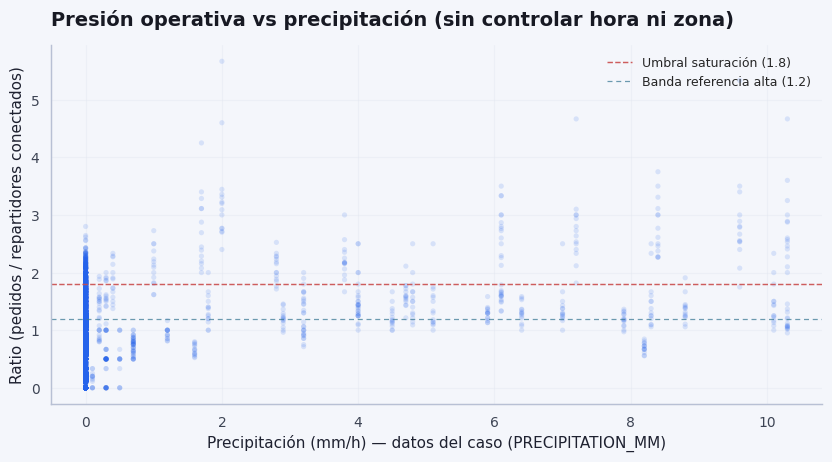


Spearman (panel): PRECIPITATION_MM vs ratio  rho=0.2307  p=6.482e-122  n=10080
→ Lectura ejecutiva: correlación cruda mezcla horas pico, zonas y clima; el modelo P2 separa HOUR y ZONE.

Spearman: ratio vs señales del archivo (mismo merge temporal):
  temperature_2m          rho= 0.4259  p=0  n=10080
  relative_humidity_2m    rho=-0.3371  p=2.424e-266  n=10080
  precipitation           rho=-0.0342  p=0.0005965  n=10080
  cloud_cover             rho=-0.0635  p=1.727e-10  n=10080
  wind_speed_10m          rho= 0.1565  p=2.644e-56  n=10080
  weather_code            rho=-0.0712  p=8.449e-13  n=10080

Coherencia Excel vs archivo (lluvia): rho=-0.0222 p=0.02611 n=10080

Horas con flag tormenta (proxy de estrés climático fuerte): 0 / 10080


In [83]:
# --- Factores exógenos: merge con archivo horario + ratio vs precipitación + señal vs ratio ---
# Objetivo de negocio: ver cómo se relaciona el KPI (ratio) con precipitación del caso y con covariables
# ambientales opcionales (un punto de referencia), sin sustituir P2 (precip + hora + zona).
import sys

import matplotlib.pyplot as plt

_om_path = PROJECT_ROOT / "modulo1_diagnostico"
if str(_om_path) not in sys.path:
    sys.path.insert(0, str(_om_path))

from open_meteo_archive_extras import (
    fetch_archive_hourly_dataframe,
    merge_raw_with_om,
    thunderstorm_flag,
)

from scipy.stats import spearmanr

_z = zone_info.copy()
_z["_z"] = _z["ZONE"].astype(str).str.strip()
_row = _z[_z["_z"].str.lower() == "centro"]
if _row.empty:
    _row = _z.iloc[[0]]
_lat = float(_row["LATITUDE_CENTER"].iloc[0])
_lon = float(_row["LONGITUDE_CENTER"].iloc[0])

_dmin = pd.to_datetime(raw["DATE"]).min().date()
_dmax = pd.to_datetime(raw["DATE"]).max().date()

print(
    "Archivo horario · lat=%.5f lon=%.5f  |  %s → %s  |  ref=%r"
    % (_lat, _lon, _dmin, _dmax, str(_row["ZONE"].iloc[0]))
)

om = fetch_archive_hourly_dataframe(_lat, _lon, _dmin, _dmax)
raw_om = merge_raw_with_om(raw, om)

# ---------- Figura 1 — Variable exógena principal del caso: precipitación vs ratio (panel completo) ----------
_pr = raw_om[["PRECIPITATION_MM", "ratio"]].dropna()
fig, ax = plt.subplots(figsize=(8.6, 4.9), facecolor=plt.rcParams["figure.facecolor"])
ax.scatter(
    _pr["PRECIPITATION_MM"],
    _pr["ratio"],
    alpha=0.14,
    s=14,
    c=COLORS.get("p3_bar", "#2563eb"),
    edgecolors="none",
)
ax.axhline(1.8, color=COLORS.get("ref_sat", "#c94c4c"), ls="--", lw=1.05, alpha=0.9, label="Umbral saturación (1.8)")
ax.axhline(1.2, color=COLORS.get("ref_ok", "#3d7a96"), ls=(0, (4, 3)), lw=0.9, alpha=0.75, label="Banda referencia alta (1.2)")
ax.set_xlabel("Precipitación (mm/h) — datos del caso (PRECIPITATION_MM)")
ax.set_ylabel("Ratio (pedidos / repartidores conectados)")
ax.set_title("Presión operativa vs precipitación (sin controlar hora ni zona)")
ax.legend(loc="upper right", frameon=False, fontsize=9)
if "polish_axes" in globals():
    polish_axes(ax)
fig.tight_layout()
save_fig(fig, FIG / "m1_ratio_vs_precipitation_exog_section.png")
plt.show()

_rho_p, _p_p = spearmanr(_pr["PRECIPITATION_MM"], _pr["ratio"])
print(
    "\nSpearman (panel): PRECIPITATION_MM vs ratio  rho=%.4f  p=%.4g  n=%d"
    % (_rho_p, _p_p, len(_pr))
)
print(
    "→ Lectura ejecutiva: correlación cruda mezcla horas pico, zonas y clima; el modelo P2 separa HOUR y ZONE."
)

# ---------- Covariables exógenas adicionales (archivo): asociación monótona con el ratio ----------
_num_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "weather_code",
]
_num_cols = [c for c in _num_cols if c in raw_om.columns]

print("\nSpearman: ratio vs señales del archivo (mismo merge temporal):")
for c in _num_cols:
    sub = raw_om[["ratio", c]].dropna()
    if len(sub) < 10:
        continue
    rho, p = spearmanr(sub["ratio"], sub[c])
    print("  %-22s  rho=%7.4f  p=%.4g  n=%d" % (c, rho, p, len(sub)))

if "precipitation" in raw_om.columns:
    _pp = raw_om[["PRECIPITATION_MM", "precipitation"]].dropna()
    if len(_pp) > 5:
        r_ex, p_ex = spearmanr(_pp["PRECIPITATION_MM"], _pp["precipitation"])
        print(
            "\nCoherencia Excel vs archivo (lluvia): rho=%.4f p=%.4g n=%d"
            % (r_ex, p_ex, len(_pp))
        )

if "weather_code" in raw_om.columns:
    _ts = thunderstorm_flag(raw_om["weather_code"]).fillna(False)
    print(
        "\nHoras con flag tormenta (proxy de estrés climático fuerte): %d / %d"
        % (int(_ts.sum()), len(raw_om))
    )

# No generamos heatmap Spearman: en este panel muchas celdas quedan ~0 con ratio y duplica
# la lectura ya cubierta por la dispersión precip–ratio, la tabla anterior y el MCO anidado.


### Interpretación ejecutiva — precipitación, ratio y factores exógenos

**Figura `m1_ratio_vs_precipitation_exog_section.png` (dispersión).** Muestra la relación **cruda** entre la precipitación del caso (`PRECIPITATION_MM`) y el ratio en todo el panel. La nube suele ser difusa: muchas horas con poca lluvía y variabilidad de ratio impulsada por **hora**, **zona** y otros factores. La línea de referencia en **1.8** marca la zona de **saturación** operativa del encargo. Esta vista no sustituye al modelo **`ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE)`**: ahí la precipitación se lee como efecto **marginal** con hora y territorio fijados.

**Tabla Spearman (salida de consola arriba).** Los coeficientes ratio–variable del archivo sustituyen al heatmap: con muchas celdas casi nulas frente al ratio, el mapa aportaba poco y repetía lo que ya resume la **dispersión precip–ratio** y el **MCO** de la celda siguiente.

#### Idea clave

En la práctica del panel, **más lluvia suele ir en la dirección de mayor tensión operativa**, pero la señal se entiende bien **dentro de hora y zona** (P2). A nivel crudo, **picos de demanda y patrones por hora** pueden ocultar o diluir la correlación simple entre precipitación y ratio; por eso la regresión con `C(HOUR)` y `C(ZONE)` es la lectura prioritaria para decisiones.

#### Limitaciones

- **Correlación y asociación no implican causalidad**: la lluvia no “causa” el ratio; ambos pueden reaccionar a un mismo día u hora de alta actividad.
- El archivo climático es **un punto**, no meteorología por polígono; la lluvia “de negocio” sigue siendo **`PRECIPITATION_MM`** del caso.
- Resultados **exploratorios**: validar antes de cambiar reglas de incentivos o dotación.

La **celda siguiente** ajusta **`ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE)`** y un modelo extendido que añade temperatura y humedad del merge, con **contraste F** anidado.

In [84]:
# --- MCO: ratio ~ precipitación + controles; extensión con factores exógenos del archivo ---
# Base explícita (misma lectura que P2): efecto marginal de lluvia con hora y zona fijas.
# Extendido: añade temperatura y humedad del merge para ver si aportan sobre esa base (contraste F).
# Requiere `raw_om` de la celda anterior.
from statsmodels.stats.anova import anova_lm

_cols = ["ratio", "PRECIPITATION_MM", "temperature_2m", "relative_humidity_2m"]
if not all(c in raw_om.columns for c in _cols):
    raise RuntimeError("Faltan columnas en raw_om; ejecuta la celda de merge Open-Meteo antes.")

sub_om = raw_om.dropna(subset=_cols)
m_p2_same_n = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE)", data=sub_om).fit()
m_om_ext = smf.ols(
    "ratio ~ PRECIPITATION_MM + temperature_2m + relative_humidity_2m + C(HOUR) + C(ZONE)",
    data=sub_om,
).fit()

print("Muestra común (precip + temp + humedad sin NaN): n = %d" % int(m_om_ext.nobs))
print("\n--- Modelo base (lectura operativa) — ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE) ---")
print(
    "  β(PRECIPITATION_MM) = %.6f   p = %.4g   R² = %.4f"
    % (
        m_p2_same_n.params["PRECIPITATION_MM"],
        m_p2_same_n.pvalues["PRECIPITATION_MM"],
        m_p2_same_n.rsquared,
    )
)
print("\n--- Modelo extendido (+ temperatura y humedad del archivo, mismos controles) ---")
for _name in ("PRECIPITATION_MM", "temperature_2m", "relative_humidity_2m"):
    print(
        "  %-22s  coef = % .6f   p = %.4g"
        % (_name, m_om_ext.params[_name], m_om_ext.pvalues[_name])
    )
print("  R² = %.4f   (R² ajustado = %.4f)" % (m_om_ext.rsquared, m_om_ext.rsquared_adj))
print("\n--- ¿Aportan temp/humedad conjuntamente? (modelo anidado, F) ---")
print(anova_lm(m_p2_same_n, m_om_ext))


Muestra común (precip + temp + humedad sin NaN): n = 10080

--- Modelo base (lectura operativa) — ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE) ---
  β(PRECIPITATION_MM) = 0.080606   p = 4.255e-240   R² = 0.7174

--- Modelo extendido (+ temperatura y humedad del archivo, mismos controles) ---
  PRECIPITATION_MM        coef =  0.080301   p = 6.601e-237
  temperature_2m          coef = -0.002959   p = 0.0008453
  relative_humidity_2m    coef = -0.001171   p = 1.821e-09
  R² = 0.7184   (R² ajustado = 0.7173)

--- ¿Aportan temp/humedad conjuntamente? (modelo anidado, F) ---
   df_resid         ssr  df_diff   ss_diff          F        Pr(>F)
0   10042.0  864.497710      0.0       NaN        NaN           NaN
1   10040.0  861.386764      2.0  3.110946  18.130006  1.381727e-08


### Calendario + clima — MCO conjunto sobre `ratio`

> **Lectura sencilla:**
> Un solo modelo mezcla **calendario** (día, festivo), **lluvia** y a veces **temperatura/humedad**, con hora y zona. Es una foto **asociativa** del mes: útil para contexto, no para afirmar que el festivo "cause" el ratio sin más datos.

**Objetivo:** en un solo modelo lineal (MCO) combinar **día de la semana** (`C(dow)`), **festivo** (México, marzo 2024, misma lista que el bloque *Calendario*), **lluvia** (`PRECIPITATION_MM`) y, si existe el merge **Open-Meteo**, **temperatura** y **humedad relativa**, con controles **hora** y **zona** — alineado con P2 y el MCO extendido de la celda anterior.

**Caveats:** asociación no implica causalidad; festivo y clima pueden estar correlacionados; el archivo Open-Meteo es un **punto** (centroide *Centro*), no meteorología por cada zona.


In [85]:
# --- Calendario + clima: MCO conjunto (dow, festivo, lluvia, temp/humedad OM) ---
# Cadena de modelos anidados: base tipo P2 → + calendario → + variables OM (si existen).
# Ideal: ejecutar antes *Calendario* (festivos) y *Open-Meteo* (`raw_om`).
from statsmodels.stats.anova import anova_lm

try:
    _joint = raw_om.copy()
    _has_om = "temperature_2m" in _joint.columns and "relative_humidity_2m" in _joint.columns
except NameError:
    _joint = raw.copy()
    _has_om = False
    print("NOTA: `raw_om` no está definido; solo precipitación Excel + calendario. Ejecuta la celda Open-Meteo.")

_joint["DATE"] = pd.to_datetime(_joint["DATE"])
_dj = _joint["DATE"].dt.normalize()
_festivos_j = pd.to_datetime(
    [
        "2024-03-18",
        "2024-03-28",
        "2024-03-29",
        "2024-03-31",
    ]
).normalize()
_joint["dow"] = _joint["DATE"].dt.dayofweek
_joint["es_festivo"] = _dj.isin(_festivos_j)

_base_cols = ["ratio", "PRECIPITATION_MM", "dow", "es_festivo", "HOUR", "ZONE"]
_om_cols = ["temperature_2m", "relative_humidity_2m"]
if _has_om:
    _need = _base_cols + _om_cols
else:
    _need = _base_cols

_sub = _joint.dropna(subset=[c for c in _need if c in _joint.columns])
if len(_sub) < 100:
    raise RuntimeError("Pocas filas tras dropna (%d); revisa columnas." % len(_sub))

m_base = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE)", data=_sub).fit()
m_cal = smf.ols(
    "ratio ~ C(dow) + es_festivo + PRECIPITATION_MM + C(HOUR) + C(ZONE)",
    data=_sub,
).fit()

print("Subconjunto común: n = %d filas" % int(m_cal.nobs))
print("\n--- Modelo base (P2): precip + hora + zona ---")
print("  coef PRECIPITATION_MM = %.6f   p = %.4g   R² = %.4f" % (
    m_base.params["PRECIPITATION_MM"],
    m_base.pvalues["PRECIPITATION_MM"],
    m_base.rsquared,
))
print("\n--- + calendario: C(dow) + es_festivo ---")
_fk = [k for k in m_cal.params.index if str(k).startswith("es_festivo")]
if _fk:
    _k0 = _fk[0]
    print("  coef %s = % .6f   p = %.4g" % (_k0, m_cal.params[_k0], m_cal.pvalues[_k0]))
else:
    print("  (coef. es_festivo no estimado — revisar variación de festivo en el subconjunto)")
print("  R² = %.4f   (ajustado %.4f)" % (m_cal.rsquared, m_cal.rsquared_adj))
print("\n--- Contraste anidado: base → +calendario ---")
print(anova_lm(m_base, m_cal))

if _has_om:
    m_full = smf.ols(
        "ratio ~ C(dow) + es_festivo + PRECIPITATION_MM + temperature_2m + relative_humidity_2m + C(HOUR) + C(ZONE)",
        data=_sub,
    ).fit()
    print("\n--- + Open-Meteo: temperature_2m, relative_humidity_2m ---")
    for _nm in ("PRECIPITATION_MM", "temperature_2m", "relative_humidity_2m"):
        print("  %-22s  coef = % .6f   p = %.4g" % (_nm, m_full.params[_nm], m_full.pvalues[_nm]))
    print("  R² = %.4f   (ajustado %.4f)" % (m_full.rsquared, m_full.rsquared_adj))
    print("\n--- Contraste anidado: +calendario → +clima OM ---")
    print(anova_lm(m_cal, m_full))
else:
    m_full = None

# Tabla compacta: coeficientes de interés para informe.
_rows = []
if _fk:
    _k0 = _fk[0]
    _rows.append((_k0, m_cal.params[_k0], m_cal.pvalues[_k0]))
if m_full is not None:
    for _nm in _om_cols:
        _rows.append((_nm, m_full.params[_nm], m_full.pvalues[_nm]))
if _rows:
    _df_coef = pd.DataFrame(_rows, columns=["variable", "coef", "p_value"])
    print("\n--- Resumen coeficientes (festivo + clima si aplica) ---")
    print(_df_coef.to_string(index=False, float_format=lambda x: "%.6f" % x))


Subconjunto común: n = 10080 filas

--- Modelo base (P2): precip + hora + zona ---
  coef PRECIPITATION_MM = 0.080606   p = 4.255e-240   R² = 0.7174

--- + calendario: C(dow) + es_festivo ---
  coef es_festivo[T.True] =  0.052964   p = 5.685e-07
  R² = 0.7187   (ajustado 0.7174)

--- Contraste anidado: base → +calendario ---
   df_resid         ssr  df_diff   ss_diff         F        Pr(>F)
0   10042.0  864.497710      0.0       NaN       NaN           NaN
1   10035.0  860.684757      7.0  3.812953  6.350921  1.812535e-07

--- + Open-Meteo: temperature_2m, relative_humidity_2m ---
  PRECIPITATION_MM        coef =  0.078448   p = 5.956e-218
  temperature_2m          coef = -0.002775   p = 0.002631
  relative_humidity_2m    coef = -0.001455   p = 9.922e-13
  R² = 0.7201   (ajustado 0.7188)

--- Contraste anidado: +calendario → +clima OM ---
   df_resid         ssr  df_diff   ss_diff          F        Pr(>F)
0   10035.0  860.684757      0.0       NaN        NaN           NaN
1   10033.0  

### Análisis de sensibilidad (1.2 → 1.8 en ratio)

> **Lectura sencilla:**
> Se traduce el modelo lineal por zona en “**cuánta lluvia extra** haría falta, en orden de magnitud, para mover el ratio del tramo bueno al tramo crítico”. Es una **aproximación**; fuera del rango observado la línea recta puede fallar.

**Nota:** Con el modelo por zona `ratio ~ PRECIPITATION_MM + C(HOUR) + C(dow)` se obtiene un coeficiente marginal $\beta_z$ (pendiente de un **modelo lineal** en precipitación, en el sentido de `Teoria/Machine Learning/tema4.pdf`–`tema5.pdf`). Si se interpreta el tramo “saludable” alto en **1.2** y la **saturación** en **1.8**, el salto es $\Delta\rho = 0.6$. La aproximación $\Delta\rho \approx \beta_z \cdot \Delta\text{precip}$ implica $\Delta\text{precip} \approx 0.6/\beta_z$ (si $\beta_z \neq 0$): son **mm/h adicionales** de **orden de magnitud** (extrapolación lineal fuera del rango observado puede fallar).

,ZONE,beta_precip,mm_for_0_6_ratio
13,Santiago,0.190569,3.148469
1,Carretera Nacional,0.131460,4.564138
12,Santa Catarina,0.103332,5.806514
7,MTY_Apodaca_Huinalá,0.085885,6.986088
5,Independencia,0.073652,8.146410
11,San Pedro,0.068153,8.803732
0,Apodaca Centro,0.065663,9.137544
4,Escobedo,0.063273,9.482767
2,Centro,0.062092,9.663099
10,San Nicolás,0.059934,10.010947


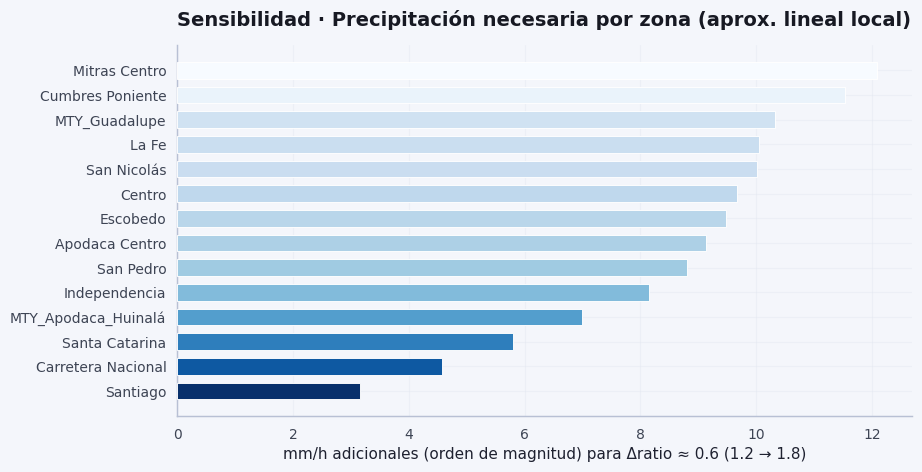

In [86]:
# --- Sensibilidad heurística: mm/h necesarios para Δratio ≈ 0.6 (banda 1.2 → 1.8) ---
# Por zona: β_precip del MCO con HOUR + dow; aproximación lineal local Δprecip ≈ 0.6 / β (si β > 0).
import matplotlib.colors as mcolors
# Estilo de figuras (por si no ejecutaste la celda de imports completa)
if "COLORS" not in globals():
    import matplotlib.pyplot as plt
    import numpy as np
    COLORS = {
        "p1_hours": plt.cm.magma(np.linspace(0.22, 0.88, 24)),
        "p1_zones_cmap": "Reds",
        "p3_bar": "#3d6b8e",
        "p4_face": "#2a9d8f",
        "p4_edge": "#1b4332",
        "sens_bar": "#1d3557",
    }
if "save_fig" not in globals():
    def save_fig(fig, path, dpi=200):
        fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor(), edgecolor="none")

if "FIG" not in globals():
    from pathlib import Path as _PathFig

    if "PROJECT_ROOT" not in globals():
        _here = _PathFig.cwd().resolve()
        for _p in (_here, _here.parent, _here.parent.parent):
            if (_p / "data" / "rappi_delivery_case_data.xlsx").is_file():
                PROJECT_ROOT = _p
                break
        else:
            raise FileNotFoundError(
                "No se encuentra data/rappi_delivery_case_data.xlsx. Ejecuta la celda de imports base."
            )
    FIG = PROJECT_ROOT / "modulo1_diagnostico" / "figures"
    FIG.mkdir(parents=True, exist_ok=True)

if "polish_axes" not in globals():
    def polish_axes(ax, title_pad=14):
        title = ax.get_title()
        ax.set_title("")
        ax.set_title(title, loc="left", pad=title_pad, fontsize=14, fontweight="600", color="#171923")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        for side in ("left", "bottom"):
            ax.spines[side].set_linewidth(1.05)
            ax.spines[side].set_color("#b8c0d4")
        ax.tick_params(axis="both", which="major", length=4.5, width=0.85, colors="#3d4454")

import pandas as pd

if "dow" not in raw.columns:
    raw = raw.copy()
    raw["dow"] = pd.to_datetime(raw["DATE"], errors="coerce").dt.dayofweek

coefs = []
for z in sorted(raw["ZONE"].unique()):
    sub = raw[raw["ZONE"] == z]
    mz = smf.ols("ratio ~ PRECIPITATION_MM + C(HOUR) + C(dow)", data=sub).fit()
    b = float(mz.params["PRECIPITATION_MM"])
    delta_mm = (0.6 / b) if b > 1e-8 else np.nan  # Orden de magnitud bajo linealidad local (ver notas markdown).
    coefs.append({"ZONE": z, "beta_precip": b, "mm_for_0_6_ratio": delta_mm})

sens_df = pd.DataFrame(coefs).sort_values("mm_for_0_6_ratio")
display(sens_df.head(14))

plot_df = sens_df.dropna(subset=["mm_for_0_6_ratio"]).copy()
fig, ax = plt.subplots(figsize=(9.5, 5), facecolor=plt.rcParams["figure.facecolor"])
norm = mcolors.Normalize(
    vmin=plot_df["mm_for_0_6_ratio"].min(),
    vmax=plot_df["mm_for_0_6_ratio"].max(),
)
cmap = plt.cm.Blues_r
bar_colors = [cmap(norm(v)) for v in plot_df["mm_for_0_6_ratio"]]
y_pos = np.arange(len(plot_df))
ax.barh(
    y_pos,
    plot_df["mm_for_0_6_ratio"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.65,
    height=0.68,
    zorder=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["ZONE"], fontsize=10)
ax.set_xlabel("mm/h adicionales (orden de magnitud) para Δratio ≈ 0.6 (1.2 → 1.8)")
ax.set_title("Sensibilidad · Precipitación necesaria por zona (aprox. lineal local)")
polish_axes(ax)
ax.grid(axis="x", zorder=0)
fig.tight_layout()
save_fig(fig, FIG / "p_sensitivity_mm_12_to_18.png")
plt.show()


### P6 — Optimización del reparto de incentivos (capacidad / supply)

> **Lectura sencilla:**
> P6 reparte un **presupuesto de incentivos** para empujar **repartidores** hacia las zonas más tensionadas en el peor instante, sin llenar de gente donde ya sobra oferta. Es **optimización exploratoria**; la política real sigue siendo de la empresa.

**Problema:** En el **peor momento** (día–hora) algunas zonas tienen **ratio** muy alto (poca capacidad relativa) y otras menos. Operaciones puede disponer de un **presupuesto** de incentivos para **atraer repartidores** hacia las más tensionadas, pero sin **inundar** zonas ya holgadas de oferta (ratio demasiado bajo → ocio / coste fijo).

**Qué hace el código (``modulo1_diagnostico/rebalance_incentives.py``):**
- Construye un estado **pico por zona**: para cada `ZONE` se toma la fila donde `ratio = ORDERS/CONNECTED_RT` es **máxima** (estrés instantáneo).
- **Integra el análisis previo** (si las celdas GAP5 + sistema operacional ya se ejecutaron): **pesos por zona** = media geométrica (tras normalizar) de **risk score** (GAP5), **media de P̂(saturación)** del logit por zona, y **sensibilidad a lluvia** por zona → entran en la función objetivo como **\(w_i (r'_i - r_{target})^2\)** (más peso donde el panel y los modelos indican mayor riesgo).
- **GAP2 (oferta):** el coeficiente **\(\beta_{\text{EARNINGS}}\)** de `CONNECTED_RT ~ EARNINGS + …` modula la **eficiencia marginal** `eff_i` en **\(C'_i = C_i + \gamma \, eff_i \, x_i\)** (heterogeneidad suave ligada al risk score; mismo **\(\sum_i x_i \le B\)**).
- Optimiza **\(x_i \ge 0\)** solo en zonas con ratio pico **por encima** de `r_target`. Típicamente **\(\gamma=1\)**.
- **Función objetivo:** **\(\sum_i w_i (r'_i - r_{target})^2 + \lambda \sum_i x_i\)**. **Restricciones:** `r'_i ≥ ratio_floor` en zonas incentivadas; el techo de saturación se prioriza vía el objetivo (no imponemos `ratio_cap` duro para no infactibilidad cuando el pico inicial es muy alto).
- Método **SLSQP** (`scipy.optimize.minimize`): optimización **no lineal con restricciones** (véase `Teoria/Optimizacion/tema1.pdf` y temas de programación no lineal).

**Aclaración de negocio:** incentivar **demanda** en la zona ya saturada **empeoraría** el ratio; este bloque es **lado oferta** (capacidad). Redirigir **pedidos** hacia zonas frescas sería **otro** modelo (descuentos / demanda).

Parámetros (`budget`, `gamma`, `r_target`, …) son **calibrables** y el resultado es **exploratorio**, no sustituye políticas reales ni al motor M2.

Pico por zona — ratio antes (min / max): 2.769230769230769 5.666666666666667
P6 integrado — prioridad media: 0.9999999999999998 | β(EARNINGS→RT): 0.3401190448216648
OK: True | Optimization terminated successfully
Presupuesto usado: 100.00 / 100.0


,ZONE,fac_risk,fac_p_sat,fac_sens_rain,fac_risk_norm,fac_p_sat_norm,fac_sens_rain_norm,priority_weight,supply_efficiency,beta_earnings_base
0,Apodaca Centro,0.006782,0.051389,0.065663,6.148486e-02,1.009747,0.818299,0.634026,0.228397,0.340119
1,Carretera Nacional,0.465085,0.059722,0.131460,4.216194e+00,1.173489,1.638259,3.438773,0.722980,0.340119
2,Centro,0.000108,0.048611,0.062092,9.834741e-04,0.955166,0.773793,0.153921,0.221194,0.340119
3,Cumbres Poniente,0.000215,0.041667,0.052032,1.953159e-03,0.818713,0.648425,0.173268,0.221310,0.340119
4,Escobedo,0.013420,0.050000,0.063273,1.216590e-01,0.982456,0.788508,0.779048,0.235560,0.340119
5,Independencia,0.010789,0.052778,0.073652,9.780720e-02,1.037037,0.917857,0.775871,0.232721,0.340119
6,La Fe,0.000000,0.036111,0.059660,9.065421e-12,0.709552,0.743491,0.000288,0.221077,0.340119
7,MTY_Apodaca_Huinalá,0.013374,0.037500,0.085885,1.212396e-01,0.736842,1.070304,0.782801,0.235510,0.340119
8,MTY_Guadalupe,0.013873,0.061111,0.058108,1.257614e-01,1.200780,0.724146,0.818631,0.236048,0.340119
9,Mitras Centro,0.000000,0.055556,0.049596,9.065421e-12,1.091618,0.618072,0.000313,0.221077,0.340119


,zone,orders,couriers,ratio_before,incentive,ratio_after,delta_ratio,zone_weight,supply_efficiency_used
10,San Nicolás,47.0,14.0,3.357143,16.949697,1.808651,-1.548491,0.909194,0.707164
8,MTY_Guadalupe,43.0,13.0,3.307692,15.290409,1.821124,-1.486569,0.818631,0.694016
5,Independencia,32.0,10.0,3.200000,12.219205,1.742846,-1.457154,0.775871,0.684233
4,Escobedo,28.0,9.0,3.111111,10.849718,1.695500,-1.415611,0.779048,0.692581
0,Apodaca Centro,31.0,10.0,3.100000,10.651662,1.807285,-1.292715,0.634026,0.671520
7,MTY_Apodaca_Huinalá,17.0,4.0,4.250000,9.964575,1.559660,-2.690340,0.782801,0.692434
11,San Pedro,45.0,15.0,3.000000,9.260988,2.132904,-0.867096,0.433587,0.658460
1,Carretera Nacional,23.0,5.0,4.600000,6.158950,1.271288,-3.328712,3.438773,2.125668
3,Cumbres Poniente,31.0,9.0,3.444444,5.707744,2.438269,-1.006175,0.173268,0.650684
13,Santiago,17.0,3.0,5.666667,2.815796,1.235061,-4.431605,5.099885,3.822897


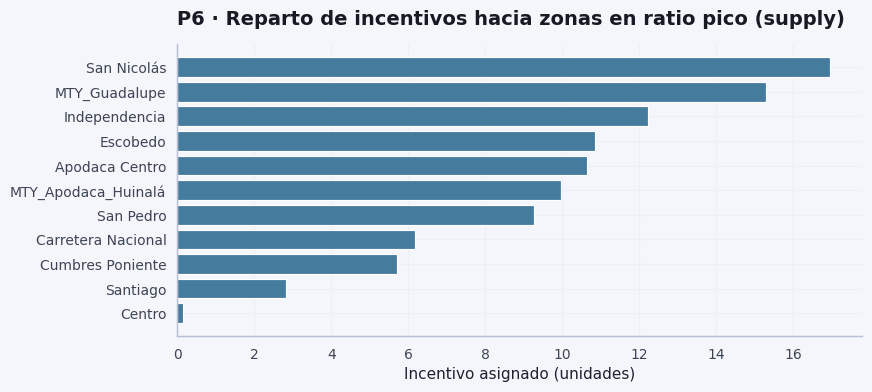

In [87]:
# =============================================================================
# P6 — Rebalanceo de incentivos entre zonas en el pico de ratio (optimización con presupuesto).
# Recarga `rebalance_incentives`; usa picos O_p, C_p y (opcional) pesos desde GAP5 / OPS_LOGIT.
# =============================================================================
import importlib
import sys

_sys_path = PROJECT_ROOT / "modulo1_diagnostico"  # carpeta del paquete rebalance_incentives
if str(_sys_path) not in sys.path:
    sys.path.insert(0, str(_sys_path))  # permitir import rebalance_incentives

# Tras editar rebalance_incentives.py, Jupyter puede seguir usando la versión cacheada en sys.modules.
import rebalance_incentives
importlib.reload(rebalance_incentives)

# P6: reasignar incentivo entre zonas en el instante de peor ratio (pico por zona).
# Entradas: demanda/capacidad en el pico O_p, C_p; pesos de prioridad y eficiencia de supply.
from rebalance_incentives import (
    aggregate_zone_peak_stress,  # reduce el panel horario a un instante de máximo estrés por zona
    build_supply_efficiency_vector,  # vector eff_i a partir de β earnings y riesgo
    build_zone_priority_vector,  # pesos w_i (riesgo, P_sat, lluvia)
    optimize_incentive_rebalance,  # optimización con presupuesto y ratio objetivo
    result_to_dataframe,  # convierte resultado numérico a tabla por zona
)

# Devuelve lista de zonas en el pico y vectores O (órdenes), C (connected RT) en ese instante.
_zones_p, O_p, C_p = aggregate_zone_peak_stress(raw)
# Ratio instantáneo por zona = O_p/C_p; min/max para ver rango antes de optimizar.
print("Pico por zona — ratio antes (min / max):", float((O_p / C_p).min()), float((O_p / C_p).max()))

# --- Opcional: enlazar resultados de celdas GAP5 / sistema OPS (si ya se ejecutaron) ---
_p_sat_by_zone = None  # serie ZONE → P(saturación) media con logit
_sens_rain_sr = None  # serie ZONE → sensibilidad ratio a lluvia (desde _risk)
_risk_df_p6 = None  # DataFrame de riesgo por zona (GAP5)
try:
    _risk_df_p6 = _risk  # mismo objeto que definió la celda de GAP5 / OPS
    _sens_rain_sr = _risk.set_index("ZONE")["sensitivity_rain"]  # una fila por zona
except NameError:
    pass  # si no existe _risk, los pesos usarán solo otras señales o neutros
try:
    _rows_ps = []
    for _z in _zones_p:
        _g = OPS_PANEL[OPS_PANEL["ZONE"].astype(str) == str(_z)]  # filas del panel OPS de esa zona
        if len(_g) == 0:
            continue
        _rows_ps.append((_z, float(OPS_LOGIT.predict(_g).mean())))  # media de P̂(sat) en esa zona
    _p_sat_by_zone = pd.Series(dict(_rows_ps))
except NameError:
    print("[P6] Aviso: OPS_LOGIT / OPS_PANEL no definidos — pesos neutros (solo pico ratio).")

_w_priority, _diag_pri = build_zone_priority_vector(
    list(_zones_p),
    risk_df=_risk_df_p6,
    risk_col="risk_score_display",
    p_sat_by_zone=_p_sat_by_zone,
    sens_rain_by_zone=_sens_rain_sr,
)  # _w_priority: pesos normalizados; _diag_pri: desglose por zona

try:
    _beta_earn = float(OPS_SUPPLY.params["EARNINGS"])  # efecto marginal de 1 MXN sobre CONNECTED_RT
except Exception:
    _beta_earn = 1.0  # fallback si no hubo MCO supply
    print("[P6] Aviso: OPS_SUPPLY no disponible — eficiencia supply homogénea.")

_eff_supply, _diag_sup = build_supply_efficiency_vector(
    list(_zones_p),
    _beta_earn,
    risk_df=_risk_df_p6,
    risk_col="risk_score_display",
    mix_risk=0.35,  # mezcla riesgo en el vector de eficiencia
)

print(
    "P6 integrado — prioridad media:", float(np.mean(_w_priority)),
    "| β(EARNINGS→RT):", _beta_earn,
)

BUDGET = 100.0  # presupuesto total de incentivo (unidades abstractas; escala relativa)
R_TARG = 1.22  # ratio deseado en el pico tras acción (tensión objetivo)
GAMMA = 1.0  # escala del coste de incentivo en la función objetivo (ver rebalance_incentives)

res_rb = optimize_incentive_rebalance(
    list(_zones_p),
    O_p,
    C_p,
    budget=BUDGET,  # límite superior de suma de incentivos
    r_target=R_TARG,  # a qué ratio busca acercar cada zona (ponderado)
    ratio_floor=0.62,  # evita soluciones absurdas con ratios demasiado bajos
    gamma=GAMMA,
    lambda_budget=0.015,  # penalización suave por no gastar todo el presupuesto (si aplica)
    max_incentive_per_zone=BUDGET,  # tope por zona (aquí = todo el presupuesto; ajustable)
    zone_weights=_w_priority,  # zonas más prioritarias reciben más peso en el objetivo cuadrático
    supply_efficiency=_eff_supply,  # zonas más eficientes en traer RT por MXN
)
print("OK:", res_rb.success, "|", res_rb.message)  # estado del optimizador scipy
print(f"Presupuesto usado: {res_rb.budget_used:.2f} / {BUDGET}")

try:
    from IPython.display import display

    display(_diag_pri.merge(_diag_sup, on="ZONE", how="outer"))  # tabla única prioridad + eficiencia
except Exception:
    pass

df_rb = result_to_dataframe(res_rb).sort_values("incentive", ascending=False)  # zonas con más incentivo primero
try:
    from IPython.display import display

    display(df_rb)
except Exception:
    print(df_rb.to_string())

# Barras horizontales: hasta 12 zonas con incentivo > 0.05 (evita ruido visual)
_top = df_rb[df_rb["incentive"] > 0.05].head(12)
if len(_top) > 0:
    fig, ax = plt.subplots(figsize=(9, 4.2), facecolor=plt.rcParams["figure.facecolor"])
    ax.barh(_top["zone"][::-1], _top["incentive"][::-1], color="#457b9d", edgecolor="white")  # [::-1]: mayor arriba
    ax.set_xlabel("Incentivo asignado (unidades)")
    ax.set_title("P6 · Reparto de incentivos hacia zonas en ratio pico (supply)")
    if "polish_axes" in globals():
        polish_axes(ax)
    fig.tight_layout()
    save_fig(fig, FIG / "p6_reparto_incentivos_zonas.png")
    plt.show()
else:
    print("Sin incentivos positivos (revisa r_target o presupuesto).")


### Lectura rápida (limitaciones)

Si no vas a leer cada viñeta técnica, quédate con esto: el Excel es un **mes de historia**, no un experimento perfecto; los modelos muestran **asociaciones** útiles, no garantías causales; y los mapas pueden estar incompletos en alguna zona. El texto largo debajo **enumera** esos puntos para quien presente el trabajo a un revisor estadístico.

---




### Validación metodológica — limitaciones, comprobaciones y coherencia

Este bloque **no** sustituye revisión estadística formal; resume **qué valida** el notebook frente a críticas habituales (ratio, regresión, geometría, umbrales, causalidad).

---

#### 1. Ratios nulos / “infinitos” y desabasto total (`CONNECTED_RT == 0`)

- **Definición:** `ratio = ORDERS / CONNECTED_RT` con `CONNECTED_RT == 0` → **NaN** (no `inf`), para no propagar infinitos en tablas.
- **Riesgo:** Si **`ORDERS > 0`** y **`CONNECTED_RT == 0`**, operativamente es **desabasto extremo** (demanda sin oferta). Esas filas **caen fuera** de los MCO/logit que hacen `dropna` sobre `ratio`: el evento **no** entra como saturación en el logit basado en `ratio > 1.8`.
- **Qué hace el notebook:** La celda de código **siguiente** cuenta esas filas y muestra ejemplos. **No** imputamos aquí un ratio alto (p. ej. 5.0) de forma global: imputar **cambia** todos los coeficientes; si se desea, conviene **columna bandera** `desabasto_total` y/o un **segundo** logit con etiqueta explícita — **documentado** como hipótesis.
- **Sugerencia explícita:** Para no “perder” el evento extremo en modelos, valorar **bandera binaria** + texto de exclusión o **sensibilidad** con imputación solo en análisis de estrés.

---

#### 2. Estacionalidad semanal en MCO (P2 y GAP 1)

- **Problema:** Lunes ≠ domingo en demanda/oferta; la lluvia puede **correlacionarse** con el día.
- **Implementado en el código:** Tras `DATE` → **`dow`** (0=lun…6=dom), los modelos principales usan **`+ C(dow)`**:
  - **P2:** `ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE) + C(dow)` (y el mismo término en el MCO con **SE cluster por zona**).
  - **GAP 1 (Análisis 1):** modelos aditivo e interacción incluyen **`+ C(dow)`** para que la pendiente marginal hora×lluvia no mezcle **patrón semanal** no modelado.
- **Nota:** Otros bloques (p. ej. P3 por zona, extensiones Open-Meteo) pueden seguir especificaciones más simples; la validación aplica al **núcleo P2 / GAP1** del diagnóstico principal.

---

#### 3. Endogeneidad de `EARNINGS` (GAP 2, supply)

- **Riesgo:** Tarifas **dinámicas** suben cuando ya hay presión (**simultaneidad**): `CONNECTED_RT ~ EARNINGS` captura **asociación** en el panel, no un experimento de incentivo exógeno.
- **Qué hace el notebook:** Controles (hora, zona, lluvia), **contrafactuales misma hora** (GAP 4) y textos que evitan llamar “causalidad pura” al **Δ MXN** mecánico.
- **Frase obligatoria:** El **β** y las **elasticidades** reportadas son **asociaciones condicionales**; magnitud puede estar **inflada** frente a un A/B test; interpretación **conservadora** para política.

---

#### 4. Geometrías truncadas y Módulo 2 (robustez)

- **Hecho:** Excel puede truncar `GEOMETRY_WKT` (**Carretera Nacional**, **Santiago**, etc.); WKT incompleto **no** parsea en Shapely.
- **Código M2 (`modulo2_motor_alertas/src/zones.py`):** `load_zone_polygons` **omite** WKT inválidos; `lat_lon_for_forecast_query` usa **`LATITUDE_CENTER` / `LONGITUDE_CENTER`** de **`ZONE_INFO`** con fuente **`centroid_fallback`** cuando no hay polígono válido — el proceso **no** debe detenerse por Shapely si el pipeline usa esta función.
- **Mapas / GeoJSON:** cualquier visualización debe **atrapar** fallos de WKT y recurrir al **punto** de `ZONE_INFO` como en el motor.

---

#### 5. Consistencia de umbrales (saludable 0.9–1.2 vs saturación 1.8)

- **Clasificación y gráficos:** Banda **saludable 0.9–1.2** (heurística); **saturación** del caso **`ratio > 1.8`** (`clasificacion`, `is_saturated`, P1, logit, risk score).
- **Motor `decision_engine`:** Usa el mismo criterio de etiqueta **saturación** que el logit del panel (**> 1.8**); **`target_ratio`** (p. ej. ~1.2) es **objetivo operativo** de corrección, **no** redefine “saturación”.
- **Sensibilidad 1.2 → 1.8:** El salto **0.6** en ratio para el ejercicio de mm/h es **coherente** con esos límites narrativos; **no** mezcla “saludable” con “saturado” en una sola etiqueta.

---

#### Síntesis

| Tema | Estado | Nota |
|------|--------|------|
| NaN / RT=0 | NaN; celda diagnóstico | Bandera / imputación solo con hipótesis explícita |
| `C(dow)` | Incluido en **P2** y **GAP 1** | Mejora control semanal |
| Earnings endógenos | Texto + contrafactuales | β = asociación, no causal pura |
| WKT truncado | Centroides `ZONE_INFO` en M2 | `lat_lon_for_forecast_query` |
| Umbrales | 0.9–1.2 vs **1.8** separados | `decision_engine` alineado a **>1.8** para saturación |
| Alertas P>0.7 | Regla + lluvia | Calibrar FP/FN con negocio |


In [88]:
# --- Control de calidad: ORDERS > 0 y CONNECTED_RT == 0 → ratio NaN (evita inf en regresiones) ---
# Validación — desabasto total: ORDERS > 0 y CONNECTED_RT == 0  →  ratio NaN (no inf); regresiones excluyen NaN.
_m = (raw["ORDERS"] > 0) & (raw["CONNECTED_RT"] == 0)
_n = int(_m.sum())
print("Filas con ORDERS > 0 y CONNECTED_RT == 0:", _n, "de", len(raw))
if _n > 0:
    print(raw.loc[_m, ["ZONE", "HOUR", "DATE", "ORDERS", "CONNECTED_RT"]].head(12).to_string(index=False))
    print(
        "\n[Nota] Son eventos extremos; el logit de saturación (ratio>1.8) no los marca. "
        "Extensión posible: columna 'desabasto_total' o imputación de ratio alto solo en análisis de sensibilidad."
    )


Filas con ORDERS > 0 y CONNECTED_RT == 0: 0 de 10080


### Resumen — análisis nuevos y soluciones implementadas

> **Lectura sencilla:**
> Esta tabla es el **índice** de todo lo añadido al diagnóstico: qué bloque hace qué, qué figura o archivo lo demuestra y cómo se enlaza con el motor y la teoría. Úsala como mapa si saltas secciones.

Esta sección consolida **qué se añadió** al flujo del diagnóstico (más allá del `describe` y las preguntas P1–P5 originales) y **dónde** está cada pieza.

| Bloque | Análisis / solución | Salida principal |
|--------|---------------------|------------------|
| **Marco teórico (`Teoria/`)** | Vinculación con apuntes UNIR: inferencia, Pearson/MCO, robustez/Spearman, heterogeneidad por zona, logística como extensión; caveats del panel temporal. | Celda *Marco teórico*; tabla al inicio |
| **Exploración ratio por zona** | Boxplot horizontal del `ratio` por `ZONE` (cuartiles, umbrales 0.9 / 1.2 / 1.8); orden por mediana. | `modulo1_diagnostico/figures/exploracion_ratio_por_zona.png` |
| **P1 — saturación** | IC95% **Wilson** para la proporción **global** de filas en saturación; **rejilla** (facets) y **un PNG por zona** en `figures/p1_frecuencia_por_zona/`; hora pico por zona. | `p1_horas_saturacion.png`, `p1_zonas_saturacion.png`, `p1_frecuencia_hora_por_zona_facets.png`, `p1_frecuencia_por_zona/p1_frecuencia_hora__*.png` |
| **P2 — precipitación** | MCO `ratio ~ precip + C(HOUR) + C(ZONE) + C(dow)`: **IC95%** del coeficiente de precipitación, **R²**, **n**; **SE cluster (zona)**; gráficas de diagnóstico MCO (residuos, QQ, regresión parcial precip., observado vs ajustado). | Consola + `p2_ols_diagnostico.png` + `p2_ols_diagnostico_separados/*.png` |
| **P2b — tramos de ratio** | Sin NPS en el Excel: tabla por **tramo de ratio** (% en saturación oficial, **CV(ORDERS)**); lectura **1.5 vs 1.8** como posible “zona amarilla” operativa. | `p2_ratio_tramos_ops.png`; consola |
| **P4 — calibración diaria** | Por **día**: `earn_mean`, `sat_frac`, `sobre_frac`; tablas top estrés y **días p75** (earn×estrés; earn×sobre-oferta); **enumeración explícita de fechas** (`YYYY-MM-DD` + día semana ES) para informe; dispersión earn vs estrés. | `p4_earnings_vs_estres.png`; consola |
| **Lluvia × hora** | Límite de lectura “causal”; modelo `ratio ~ PRECIPITATION_MM * C(HOUR) + C(ZONE) + C(dow)`; **contraste anidado**; tabla y frase negocio (Δratio por +1 mm/h); figura pendiente por hora. | `gap1_precip_marginal_por_hora.png` |
| **Earnings → oferta** | Modelo **invertido** en niveles + **elasticidad log–log** (`log(RT)~log(earnings)+…`); **SE cluster (zona)**; **elasticidad puntual** β·(Ē/RT̄); identidad **ratio = ORDERS/CONNECTED_RT**; Δearnings ≈ ΔRT/β; ejemplo numérico y frase negocio; enlace a **P6**. | Impreso en consola (celda GAP 2) |
| **Predicción (logit)** | `is_saturated`; **logit** `~ PRECIPITATION_MM + EARNINGS + C(HOUR) + C(ZONE)`; escenarios de **P(sat)**; regla `prob > 0.7` tipo **alert()** (Módulo 2). | Impreso en consola (celda GAP 3) |
| **P4 contrafactual** | Misma **hora**: alto vs bajo **EARNINGS** (mediana); Δ **P(saturación)**; mitiga lectura espuria earn–estrés a nivel día. | `gap4_p4_counterfactual_misma_hora.png` |
| **Priorización y simulación** | **Risk score** por zona (hist. saturación × sensibilidad lluvia × CV pedidos, min–max); figura ranking; **rejilla** lluvia × earnings con **ratio** predicho (MCO); enlace P6 / sensibilidad como simulación de política. | `gap5_risk_score_zonas.png`; tabla en consola |
| **Sistema operacional** | **Logit** + **IC95% P(sat)** + **Confidence** (N histórico similar); **alert** = prob>0.7 **y** precip ≥ umbral panel; **risk_score** zona; **`decision_engine`**, **`simulate_operational_scenario`**; takeaway **EN**. | Impreso en consola; funciones reutilizables |
| **P3** | Texto alineado a **estratos por zona** (`tema5`). | Figura existente `p3_sensibilidad_zona.png` |
| **P5 — interacción** | `ratio ~ EARNINGS * PRECIPITATION_MM + …`: la relación earnings–ratio **depende de la lluvia** (término de interacción); **p-valor / IC** del `EARNINGS:PRECIPITATION_MM`; **R²**; texto explícito en consola. | Impreso en consola P5 |
| **Sensibilidad mm (1.2→1.8)** | Texto con referencia a modelo lineal y límites de extrapolación. | `p_sensitivity_mm_12_to_18.png` |
| **P6 — optimización** | Reparto bajo **SLSQP** con `C' = C + γ·eff_i·x_i`, **pesos** del objetivo desde **risk + P̂_sat (logit) + sens. lluvia**, **eff_i** ligado a **β(EARNINGS)** (GAP2) y risk; pico por zona como antes. Código `rebalance_incentives.py`. | `p6_reparto_incentivos_zonas.png`; `df_rb`, `_diag_pri` / `_diag_sup` |
| **Calendario** | `ratio` vs **día de la semana** (Kruskal–Wallis) y **festivos MX** vs no (Mann–Whitney); Spearman exploratorio; boxplots. | `calendario_ratio_dow_festivos.png` |
| **Calendario + clima (MCO)** | Modelo conjunto `ratio ~ C(dow) + es_festivo + PRECIPITATION_MM + C(HOUR) + C(ZONE)` y extensión con `temperature_2m` + `relative_humidity_2m` si existe `raw_om`; contrastes **F** anidados vs base tipo P2. | Impreso en consola (celda *Calendario + clima*) |
| **Factores exógenos (Open-Meteo)** | Dispersión **ratio vs PRECIPITATION_MM**; Spearman en consola (ratio vs señales del archivo); MCO **`ratio ~ PRECIPITATION_MM + C(HOUR) + C(ZONE)`** vs extensión con temp./humedad; contraste F. Punto archivo: **Centro**. | `m1_ratio_vs_precipitation_exog_section.png` |

**Interpretación operativa (P6):** la solución prioriza **atraer oferta (repartidores)** a las zonas más tensionadas en el **instante pico**, sin forzar un techo duro de ratio incompatible con el estado inicial. No sustituye al motor M2 ni a políticas reales de incentivos.

**Reproducibilidad:** ejecutar el notebook **de arriba abajo** tras colocar `rappi_delivery_case_data.xlsx` en `data/` o en la raíz del repo (según la primera celda de código).